In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"joysalini","key":"463e80676154fc4c62e0bab3ee926c62"}'}

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.copy("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle configured successfully.")

Kaggle configured successfully.


In [ ]:
!kaggle datasets download -d imsparsh/accentdb-core-extended

print("Dataset downloaded successfully.")

Dataset URL: https://www.kaggle.com/datasets/imsparsh/accentdb-core-extended
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 6.28G/6.28G [01:46<00:00, 63.3MB/s]

Dataset downloaded successfully.


In [ ]:
import zipfile

zip_path = "accentdb-core-extended.zip"
extract_path = "accentdb"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


In [ ]:
import os

print(os.listdir("accentdb"))

['accentdb_extended', 'accentdb_core']


In [ ]:
DATASET_PATH = "accentdb/accentdb_extended/data"

In [ ]:
!pip install beautifulsoup4 requests pandas

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [ ]:
url = "https://www.cs.columbia.edu/~hgs/audio/harvard.html"

html = requests.get(url).text

print("Downloaded Successfully")

Downloaded Successfully


In [ ]:
soup = BeautifulSoup(html, "html.parser")

print(soup.title)

<title>Harvard Sentences</title>


In [ ]:
sentences = [
    (1, "The birch canoe slid on the smooth planks."),
    (2, "Glue the sheet to the dark blue background."),
    ...
]

In [ ]:
import requests
from bs4 import BeautifulSoup

url = "https://www.cs.columbia.edu/~hgs/audio/harvard.html"

html = requests.get(url).text

print(html[:2000])

<!doctype html>
<html lang="en">
<head>
<meta name="author" content="Henning Schulzrinne">
<meta charset="utf-8">
<title>Harvard Sentences</title>
</head>

<body>
<h1>Harvard Sentences</h1>

<p>From "IEEE Recommended Practice for Speech Quality Measurements."  <i>IEEE
Transactions on Audio and Electroacoustics</i>, Vol. 17, Issue 3, 225-246, 1969.
APPENDIX C 1965 Revised List of Phonetically Balanced Sentences (Harvard Sentences).
DOI <a href="https://doi.org/10.1109/IEEESTD.1969.7405210">
10.1109/IEEESTD.1969.7405210</a> (IEEE standard 297-1969)
and <a href="https://ieeexplore.ieee.org/document/1162058">10.1109/TAU.1969.1162058</a>
</p>

<p>Also found at <a
href="http://www-2.cs.cmu.edu/afs/cs.cmu.edu/project/fgdata/OldFiles/Recorder.app/utterances/Type1/harvsents.txt">CMU
site</a> and the <em>TSP Speech Database</em> at <a
href="https://www.mmsp.ece.mcgill.ca/Documents/Reports/2018/KabalR2018b.pdf">McGill</a> (Appendix B).</p>

<h2>List 1</h2>

<ol>
<li>The birch canoe slid on the sm

In [ ]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(html, "html.parser")

print(soup.prettify()[:3000])

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta content="Henning Schulzrinne" name="author"/>
  <meta charset="utf-8"/>
  <title>
   Harvard Sentences
  </title>
 </head>
 <body>
  <h1>
   Harvard Sentences
  </h1>
  <p>
   From "IEEE Recommended Practice for Speech Quality Measurements."
   <i>
    IEEE
Transactions on Audio and Electroacoustics
   </i>
   , Vol. 17, Issue 3, 225-246, 1969.
APPENDIX C 1965 Revised List of Phonetically Balanced Sentences (Harvard Sentences).
DOI
   <a href="https://doi.org/10.1109/IEEESTD.1969.7405210">
    10.1109/IEEESTD.1969.7405210
   </a>
   (IEEE standard 297-1969)
and
   <a href="https://ieeexplore.ieee.org/document/1162058">
    10.1109/TAU.1969.1162058
   </a>
  </p>
  <p>
   Also found at
   <a href="http://www-2.cs.cmu.edu/afs/cs.cmu.edu/project/fgdata/OldFiles/Recorder.app/utterances/Type1/harvsents.txt">
    CMU
site
   </a>
   and the
   <em>
    TSP Speech Database
   </em>
   at
   <a href="https://www.mmsp.ece.mcgill.ca/Documents/Repo

In [ ]:
url = "https://www.cs.columbia.edu/~hgs/audio/harvard.html"

html = requests.get(url).text
soup = BeautifulSoup(html, "html.parser")

sentence_data = []

sentence_id = 1


for ol in soup.find_all("ol"):


    for li in ol.find_all("li"):

        sentence = li.get_text(strip=True)

        sentence_data.append({
            "sentence_id": sentence_id,
            "ground_truth": sentence
        })

        sentence_id += 1

harvard_df = pd.DataFrame(sentence_data)

print("Total sentences:", len(harvard_df))

harvard_df.head(15)

Total sentences: 720


,sentence_id,ground_truth
0,1,The birch canoe slid on the smooth planks.
1,2,Glue the sheet to the dark blue background.
2,3,It's easy to tell the depth of a well.
3,4,These days a chicken leg is a rare dish.
4,5,Rice is often served in round bowls.
5,6,The juice of lemons makes fine punch.
6,7,The box was thrown beside the parked truck.
7,8,The hogs were fed chopped corn and garbage.
8,9,Four hours of steady work faced us.
9,10,A large size in stockings is hard to sell.


In [ ]:
harvard_df.to_csv("harvard_sentences.csv", index=False)

print("Saved successfully!")

Saved successfully!


**Building the clean experimental dataset**

Defining the accent groups
leaving Bangla/Malayalam/Odiya/Telugu out for now.

Because discovered that their file counts are different:

Bangla       778 / 750
Malayalam    751 / 747 / 895
Odiya        747
Telugu       766 / 749

In [ ]:
import os

DATASET_PATH = "accentdb/accentdb_extended/data"

ACCENT_GROUPS = {
    "American": ["american"],
    "Australian": ["australian"],
    "British": ["british"],
    "Indian": ["indian"],
    "Welsh": ["welsh"]
}

**Define the split audio files**

In [ ]:
SPLIT_GROUPS_742 = [
    [29, 30, 31],
    [116, 117],
    [170, 171],
    [211, 212],
    [245, 246],
    [254, 255],
    [296, 297],
    [313, 314],
    [323, 324],
    [356, 357],
    [418, 419],
    [476, 477],
    [491, 492],
    [515, 516],
    [524, 525],
    [528, 529, 530],
    [533, 534],
    [583, 584],
    [595, 596],
    [613, 614]
]

EXCLUDED_FILE_NUMBERS = {
    n
    for group in SPLIT_GROUPS_742
    for n in group
}

print("Split groups:", len(SPLIT_GROUPS_742))
print("Excluded audio segments:", len(EXCLUDED_FILE_NUMBERS))

Split groups: 20
Excluded audio segments: 42


**Defining the corresponding Harvard sentences**

In [ ]:
EXCLUDED_SENTENCE_IDS = [
    29,
    116,
    170,
    211,
    245,
    254,
    296,
    313,
    323,
    356,
    418,
    476,
    491,
    515,
    524,
    528,
    533,
    583,
    595,
    613
]

print("Excluded Harvard sentences:", len(EXCLUDED_SENTENCE_IDS))

Excluded Harvard sentences: 20


**Create the valid Harvard sentence list**

In [ ]:
valid_harvard_df = harvard_df[
    ~harvard_df["sentence_id"].isin(
        EXCLUDED_SENTENCE_IDS
    )
].copy()

valid_harvard_df = valid_harvard_df.reset_index(drop=True)

print("Valid Harvard sentences:", len(valid_harvard_df))

Valid Harvard sentences: 700


**Building the audio inventory**

From AccentDB and collect the actual WAV files.

In [ ]:
audio_records = []

for accent_group, accent_folders in ACCENT_GROUPS.items():

    for accent_folder in accent_folders:

        accent_path = os.path.join(
            DATASET_PATH,
            accent_folder
        )

        if not os.path.isdir(accent_path):
            continue

        for speaker in sorted(os.listdir(accent_path)):

            speaker_path = os.path.join(
                accent_path,
                speaker
            )

            if not os.path.isdir(speaker_path):
                continue

            for filename in sorted(os.listdir(speaker_path)):

                if not filename.lower().endswith(".wav"):
                    continue

                filepath = os.path.join(
                    speaker_path,
                    filename
                )

                audio_records.append({
                    "accent_group": accent_group,
                    "accent_folder": accent_folder,
                    "speaker": speaker,
                    "filename": filename,
                    "filepath": filepath
                })

audio_df = pd.DataFrame(audio_records)

print("Total audio files:", len(audio_df))

Total audio files: 11130


**Extract the file number**

In [ ]:
audio_df["file_number"] = (
    audio_df["filename"]
    .str.extract(r"_(\d+)\.wav$")[0]
    .astype(int)
)

In [ ]:
audio_df.head()

,accent_group,accent_folder,speaker,filename,filepath,file_number
0,American,american,speaker_01,american_s01_001.wav,accentdb/accentdb_extended/data/american/speak...,1
1,American,american,speaker_01,american_s01_002.wav,accentdb/accentdb_extended/data/american/speak...,2
2,American,american,speaker_01,american_s01_003.wav,accentdb/accentdb_extended/data/american/speak...,3
3,American,american,speaker_01,american_s01_004.wav,accentdb/accentdb_extended/data/american/speak...,4
4,American,american,speaker_01,american_s01_005.wav,accentdb/accentdb_extended/data/american/speak...,5


**Check the distribution**

In [ ]:
file_counts = (
    audio_df
    .groupby(
        ["accent_group", "accent_folder", "speaker"]
    )
    .size()
    .reset_index(name="file_count")
)

file_counts

,accent_group,accent_folder,speaker,file_count
0,American,american,speaker_01,742
1,American,american,speaker_02,742
2,American,american,speaker_03,742
3,American,american,speaker_04,742
4,American,american,speaker_05,742
5,American,american,speaker_06,742
6,American,american,speaker_07,742
7,American,american,speaker_08,742
8,Australian,australian,speaker_01,742
9,Australian,australian,speaker_02,742


**Keep only the 742-file speakers**

In [ ]:
speakers_742 = file_counts[
    file_counts["file_count"] == 742
][
    ["accent_group", "accent_folder", "speaker"]
].copy()

print("Number of 742-file speakers:", len(speakers_742))

Number of 742-file speakers: 15


In [ ]:
clean_audio_df = audio_df.merge(
    speakers_742,
    on=[
        "accent_group",
        "accent_folder",
        "speaker"
    ],
    how="inner"
)

print("742-file audio:", len(clean_audio_df))

742-file audio: 11130


**Remove the split audio segments**

In [ ]:
clean_audio_df = clean_audio_df[
    ~clean_audio_df["file_number"].isin(
        EXCLUDED_FILE_NUMBERS
    )
].copy()

print("After removing split segments:", len(clean_audio_df))

After removing split segments: 10500


**Create the correct audio → Harvard sentence mapping**

In [ ]:
valid_sentence_ids = valid_harvard_df[
    "sentence_id"
].tolist()

clean_audio_df = clean_audio_df.sort_values(
    [
        "accent_group",
        "accent_folder",
        "speaker",
        "file_number"
    ]
).copy()

clean_audio_df["sentence_id"] = (
    clean_audio_df
    .groupby(
        [
            "accent_group",
            "accent_folder",
            "speaker"
        ]
    )
    .cumcount()
)

In [ ]:
clean_audio_df["sentence_id"] = (
    clean_audio_df["sentence_id"]
    .map(
        dict(enumerate(valid_sentence_ids))
    )
)

**Attach the Harvard ground truth**

In [ ]:
clean_audio_df = clean_audio_df.merge(
    valid_harvard_df[
        ["sentence_id", "ground_truth"]
    ],
    on="sentence_id",
    how="left"
)

**Validating everything**

In [ ]:
print("Total recordings:", len(clean_audio_df))

print(
    "Unique speakers:",
    clean_audio_df[
        ["accent_group", "accent_folder", "speaker"]
    ].drop_duplicates().shape[0]
)

print(
    "Missing ground truth:",
    clean_audio_df["ground_truth"].isna().sum()
)

Total recordings: 10500
Unique speakers: 15
Missing ground truth: 0


**Checking and verifying every speaker has exactly 700 audio recordings**

In [ ]:
print(
    clean_audio_df
    .groupby(
        ["accent_group", "accent_folder", "speaker"]
    )
    .size()
)

accent_group  accent_folder  speaker   
American      american       speaker_01    700
                             speaker_02    700
                             speaker_03    700
                             speaker_04    700
                             speaker_05    700
                             speaker_06    700
                             speaker_07    700
                             speaker_08    700
Australian    australian     speaker_01    700
                             speaker_02    700
British       british        speaker_01    700
                             speaker_02    700
Indian        indian         speaker_01    700
                             speaker_02    700
Welsh         welsh          speaker_01    700
dtype: int64


**Mapping check**

For American speaker_02:

In [ ]:
clean_audio_df[
    (clean_audio_df["accent_folder"] == "american") &
    (clean_audio_df["speaker"] == "speaker_02") &
    (clean_audio_df["file_number"].between(25, 35))
][
    [
        "file_number",
        "filename",
        "sentence_id",
        "ground_truth"
    ]
]

,file_number,filename,sentence_id,ground_truth
724,25,american_s02_025.wav,25,The beauty of the view stunned the young boy.
725,26,american_s02_026.wav,26,Two blue fish swam in the tank.
726,27,american_s02_027.wav,27,Her purse was full of useless trash.
727,28,american_s02_028.wav,28,The colt reared and threw the tall rider.
728,32,american_s02_032.wav,30,Read verse out loud for pleasure.
729,33,american_s02_033.wav,31,Hoist the load to your left shoulder.
730,34,american_s02_034.wav,32,Take the winding path to reach the lake.
731,35,american_s02_035.wav,33,Note closely the size of the gas tank.


**Save the dataset**

In [ ]:
clean_audio_df.to_csv(
    "clean_742_pilot_dataset.csv",
    index=False
)

print("Clean pilot dataset saved successfully!")

Clean pilot dataset saved successfully!


In [ ]:
print(os.path.exists("clean_742_pilot_dataset.csv"))

True


In [ ]:
master_df = pd.read_csv("clean_742_pilot_dataset.csv")
master_df.head(40)

,accent_group,accent_folder,speaker,filename,filepath,file_number,sentence_id,ground_truth
0,American,american,speaker_01,american_s01_001.wav,accentdb/accentdb_extended/data/american/speak...,1,1,The birch canoe slid on the smooth planks.
1,American,american,speaker_01,american_s01_002.wav,accentdb/accentdb_extended/data/american/speak...,2,2,Glue the sheet to the dark blue background.
2,American,american,speaker_01,american_s01_003.wav,accentdb/accentdb_extended/data/american/speak...,3,3,It's easy to tell the depth of a well.
3,American,american,speaker_01,american_s01_004.wav,accentdb/accentdb_extended/data/american/speak...,4,4,These days a chicken leg is a rare dish.
4,American,american,speaker_01,american_s01_005.wav,accentdb/accentdb_extended/data/american/speak...,5,5,Rice is often served in round bowls.
5,American,american,speaker_01,american_s01_006.wav,accentdb/accentdb_extended/data/american/speak...,6,6,The juice of lemons makes fine punch.
6,American,american,speaker_01,american_s01_007.wav,accentdb/accentdb_extended/data/american/speak...,7,7,The box was thrown beside the parked truck.
7,American,american,speaker_01,american_s01_008.wav,accentdb/accentdb_extended/data/american/speak...,8,8,The hogs were fed chopped corn and garbage.
8,American,american,speaker_01,american_s01_009.wav,accentdb/accentdb_extended/data/american/speak...,9,9,Four hours of steady work faced us.
9,American,american,speaker_01,american_s01_010.wav,accentdb/accentdb_extended/data/american/speak...,10,10,A large size in stockings is hard to sell.


In [ ]:
print("Rows:", len(master_df))
print("Columns:", master_df.columns.tolist())

Rows: 10500
Columns: ['accent_group', 'accent_folder', 'speaker', 'filename', 'filepath', 'file_number', 'sentence_id', 'ground_truth']


In [ ]:
print(
    master_df.groupby(
        ["accent_group", "speaker"]
    ).size()
)

accent_group  speaker   
American      speaker_01    700
              speaker_02    700
              speaker_03    700
              speaker_04    700
              speaker_05    700
              speaker_06    700
              speaker_07    700
              speaker_08    700
Australian    speaker_01    700
              speaker_02    700
British       speaker_01    700
              speaker_02    700
Indian        speaker_01    700
              speaker_02    700
Welsh         speaker_01    700
dtype: int64


In [ ]:
print(
    "Missing ground truth:",
    master_df["ground_truth"].isna().sum()
)

Missing ground truth: 0


Number of rows: 10500

Recording counts:
accent_group
American      5600
Australian    1400
British       1400
Indian        1400
Welsh          700
dtype: int64


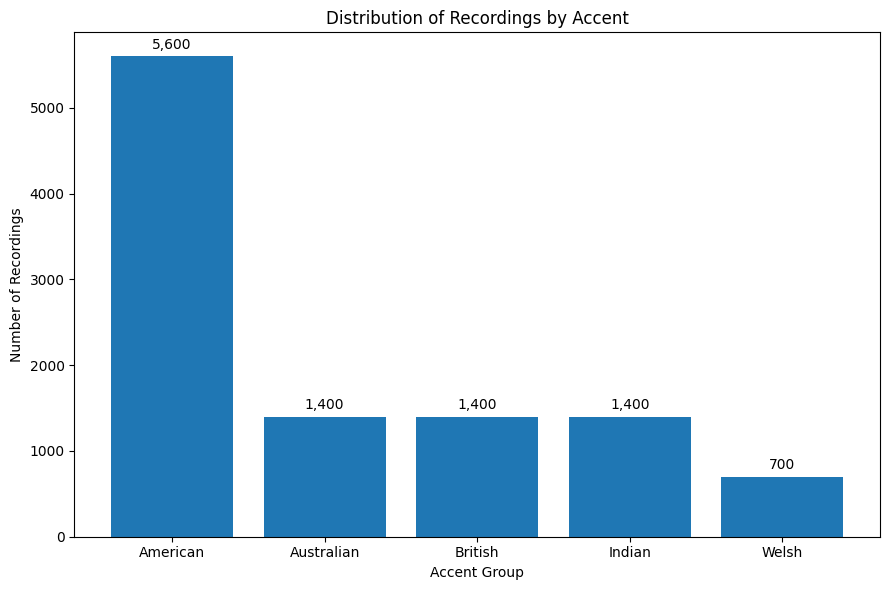


Figure saved successfully.


In [ ]:
import matplotlib.pyplot as plt

# Check that master_df exists
print("Number of rows:", len(master_df))

# Count recordings per accent
accent_counts = (
    master_df.groupby("accent_group")
    .size()
    .reindex(["American", "Australian", "British", "Indian", "Welsh"])
)

print("\nRecording counts:")
print(accent_counts)

# Create figure
fig, ax = plt.subplots(figsize=(9, 6))

# Create bars
bars = ax.bar(
    accent_counts.index,
    accent_counts.values
)

# Labels and title
ax.set_xlabel("Accent Group")
ax.set_ylabel("Number of Recordings")
ax.set_title("Distribution of Recordings by Accent")

# Add values above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 50,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

# Make sure everything fits
fig.tight_layout()

# SAVE AFTER plotting
fig.savefig(
    "/content/figure_4_1_accent_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the same figure
plt.show()

print("\nFigure saved successfully.")

Speaker counts:
accent_group
American      8
Australian    2
British       2
Indian        2
Welsh         1
Name: speaker, dtype: int64


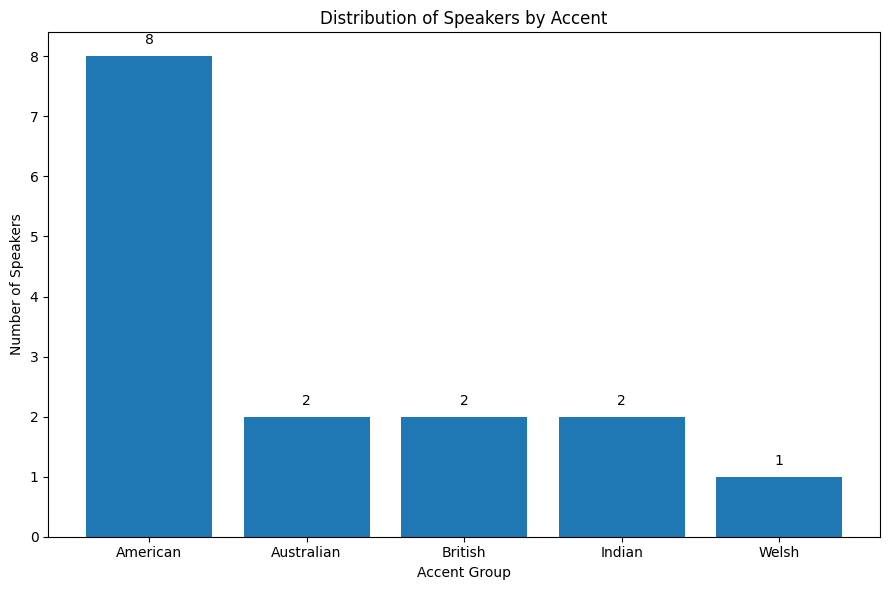


Figure saved successfully.


In [ ]:
import matplotlib.pyplot as plt

# Count unique speakers per accent
speaker_counts = (
    master_df.groupby("accent_group")["speaker"]
    .nunique()
    .reindex(["American", "Australian", "British", "Indian", "Welsh"])
)

print("Speaker counts:")
print(speaker_counts)

# Create figure
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    speaker_counts.index,
    speaker_counts.values
)

ax.set_xlabel("Accent Group")
ax.set_ylabel("Number of Speakers")
ax.set_title("Distribution of Speakers by Accent")

# Add values above bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.15,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

fig.tight_layout()

# Save AFTER plotting
fig.savefig(
    "/content/figure_4_2_speaker_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved successfully.")

**checking the actual mapping**

In [ ]:
master_df[
    (master_df["accent_folder"] == "american") &
    (master_df["speaker"] == "speaker_02") &
    (master_df["file_number"].between(25, 35))
][
    [
        "file_number",
        "filename",
        "sentence_id",
        "ground_truth"
    ]
]

,file_number,filename,sentence_id,ground_truth
724,25,american_s02_025.wav,25,The beauty of the view stunned the young boy.
725,26,american_s02_026.wav,26,Two blue fish swam in the tank.
726,27,american_s02_027.wav,27,Her purse was full of useless trash.
727,28,american_s02_028.wav,28,The colt reared and threw the tall rider.
728,32,american_s02_032.wav,30,Read verse out loud for pleasure.
729,33,american_s02_033.wav,31,Hoist the load to your left shoulder.
730,34,american_s02_034.wav,32,Take the winding path to reach the lake.
731,35,american_s02_035.wav,33,Note closely the size of the gas tank.


**Whisper Transcription**

In [ ]:

# Install Required Libraries

!pip install -q openai-whisper
!pip install -q jiwer
!pip install -q librosa
!pip install -q soundfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 21.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 57.4 MB/s eta 0:00:00


In [ ]:
import whisper
import librosa
import torch
import time

In [ ]:
print("Torch:", torch.__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

Torch: 2.11.0+cu128
GPU: Tesla T4


In [ ]:
model = whisper.load_model("base")

print("Whisper loaded successfully.")

100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 162MiB/s]


Whisper loaded successfully.


**Checking with one recording**

In [ ]:
row = master_df.iloc[0]

print("Filename:", row["filename"])
print("Sentence ID:", row["sentence_id"])
print("\nGround Truth:")
print(row["ground_truth"])

Filename: american_s01_001.wav
Sentence ID: 1

Ground Truth:
The birch canoe slid on the smooth planks.


In [ ]:
import time

audio_path = row["filepath"]

start = time.time()

result = model.transcribe(
    audio_path,
    fp16=False
)

end = time.time()

prediction = result["text"].strip()

print("\nPrediction:")
print(prediction)

print("\nRuntime:", round(end - start, 2), "seconds")


Prediction:
The bridge can do slide on the smooth planks.

Runtime: 3.42 seconds


**Checking an audio after one of the excluded groups to verify mapping didn't shift incorrectly.**

In [ ]:
row = master_df[
    (master_df["accent_folder"] == "american") &
    (master_df["speaker"] == "speaker_02") &
    (master_df["file_number"] == 32)
].iloc[0]

print("Filename:", row["filename"])
print("File number:", row["file_number"])
print("Sentence ID:", row["sentence_id"])
print("\nGround Truth:")
print(row["ground_truth"])

Filename: american_s02_032.wav
File number: 32
Sentence ID: 30

Ground Truth:
Read verse out loud for pleasure.


In [ ]:
result = model.transcribe(
    row["filepath"],
    fp16=False
)

print("\nPrediction:")
print(result["text"].strip())


Prediction:
Read vs Out Loud for Pleasure


In [ ]:
print(master_df.columns.tolist())

['accent_group', 'accent_folder', 'speaker', 'filename', 'filepath', 'file_number', 'sentence_id', 'ground_truth']


**Whisper on all 10,500 recordings**





In [ ]:
import time
import librosa

predictions = []
runtimes = []
durations = []
rtfs = []

for index, row in master_df.iterrows():

    audio_path = row["filepath"]

    try:

        speech, sr = librosa.load(
            audio_path,
            sr=16000
        )

        duration = len(speech) / sr


        start = time.time()
        result = model.transcribe(
            audio_path,
            fp16=False
        )

        end = time.time()

        prediction = result["text"].strip()

        runtime = end - start
        predictions.append(prediction)
        runtimes.append(runtime)
        durations.append(duration)
        rtfs.append(runtime / duration)

    except Exception as e:

        print(f"Error processing: {audio_path}")
        print(e)

        predictions.append("")
        runtimes.append(None)
        durations.append(None)
        rtfs.append(None)

print("Whisper transcription completed.")

Whisper transcription completed.


In [ ]:
master_df["prediction"] = predictions
master_df["runtime"] = runtimes
master_df["audio_duration"] = durations
master_df["rtf"] = rtfs

In [ ]:
master_df.head()

,accent_group,accent_folder,speaker,filename,filepath,file_number,sentence_id,ground_truth,prediction,runtime,audio_duration,rtf
0,American,american,speaker_01,american_s01_001.wav,accentdb/accentdb_extended/data/american/speak...,1,1,The birch canoe slid on the smooth planks.,The bridge can do slide on the smooth planks.,0.330446,2.7,0.122387
1,American,american,speaker_01,american_s01_002.wav,accentdb/accentdb_extended/data/american/speak...,2,2,Glue the sheet to the dark blue background.,Glue the sheet to the dark blue background.,0.285948,3.5,0.081700
2,American,american,speaker_01,american_s01_003.wav,accentdb/accentdb_extended/data/american/speak...,3,3,It's easy to tell the depth of a well.,It's easy to tell the depths of a well.,0.256618,3.4,0.075476
3,American,american,speaker_01,american_s01_004.wav,accentdb/accentdb_extended/data/american/speak...,4,4,These days a chicken leg is a rare dish.,These days the chicken leg is a rare dish.,0.247554,3.6,0.068765
4,American,american,speaker_01,american_s01_005.wav,accentdb/accentdb_extended/data/american/speak...,5,5,Rice is often served in round bowls.,Rice is often served in round bowls.,0.244858,3.6,0.068016


**Save the raw Whisper results**

In [ ]:
master_df.to_csv(
    "whisper_clean_742_results.csv",
    index=False
)

print("Whisper results saved successfully.")

Whisper results saved successfully.


**Checking a few predictions**

In [ ]:
for i in range(5):

    row = master_df.iloc[i]

    print("=" * 70)

    print("Filename:", row["filename"])
    print("Sentence ID:", row["sentence_id"])

    print("\nGround Truth:")
    print(row["ground_truth"])

    print("\nPrediction:")
    print(row["prediction"])

Filename: american_s01_001.wav
Sentence ID: 1

Ground Truth:
The birch canoe slid on the smooth planks.

Prediction:
The bridge can do slide on the smooth planks.
Filename: american_s01_002.wav
Sentence ID: 2

Ground Truth:
Glue the sheet to the dark blue background.

Prediction:
Glue the sheet to the dark blue background.
Filename: american_s01_003.wav
Sentence ID: 3

Ground Truth:
It's easy to tell the depth of a well.

Prediction:
It's easy to tell the depths of a well.
Filename: american_s01_004.wav
Sentence ID: 4

Ground Truth:
These days a chicken leg is a rare dish.

Prediction:
These days the chicken leg is a rare dish.
Filename: american_s01_005.wav
Sentence ID: 5

Ground Truth:
Rice is often served in round bowls.

Prediction:
Rice is often served in round bowls.


**Checking for failed transcriptions**

In [ ]:
print(
    "Empty predictions:",
    (master_df["prediction"].str.strip() == "").sum()
)

Empty predictions: 0


**Whisper Evaluation**

In [ ]:
!pip install -q jiwer

In [ ]:
from jiwer import wer
from jiwer import cer

In [ ]:
master_df = pd.read_csv("whisper_clean_742_results.csv")

master_df.head()
print("Rows:", len(master_df))
master_df.head()

Rows: 10500


,accent_group,accent_folder,speaker,filename,filepath,file_number,sentence_id,ground_truth,prediction,runtime,audio_duration,rtf
0,American,american,speaker_01,american_s01_001.wav,accentdb/accentdb_extended/data/american/speak...,1,1,The birch canoe slid on the smooth planks.,The bridge can do slide on the smooth planks.,0.330446,2.7,0.122387
1,American,american,speaker_01,american_s01_002.wav,accentdb/accentdb_extended/data/american/speak...,2,2,Glue the sheet to the dark blue background.,Glue the sheet to the dark blue background.,0.285948,3.5,0.081700
2,American,american,speaker_01,american_s01_003.wav,accentdb/accentdb_extended/data/american/speak...,3,3,It's easy to tell the depth of a well.,It's easy to tell the depths of a well.,0.256618,3.4,0.075476
3,American,american,speaker_01,american_s01_004.wav,accentdb/accentdb_extended/data/american/speak...,4,4,These days a chicken leg is a rare dish.,These days the chicken leg is a rare dish.,0.247554,3.6,0.068765
4,American,american,speaker_01,american_s01_005.wav,accentdb/accentdb_extended/data/american/speak...,5,5,Rice is often served in round bowls.,Rice is often served in round bowls.,0.244858,3.6,0.068016


In [ ]:
import re

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = " ".join(text.split())
    return text

master_df["gt_normalized"] = master_df["ground_truth"].apply(
    normalize_text
)

master_df["prediction_normalized"] = master_df["prediction"].apply(
    normalize_text
)
print("Text normalization completed.")

Text normalization completed.


In [ ]:
from jiwer import wer, cer

master_df["WER"] = master_df.apply(
    lambda row: wer(
        row["gt_normalized"],
        row["prediction_normalized"]
    ),
    axis=1
)

master_df["CER"] = master_df.apply(
    lambda row: cer(
        row["gt_normalized"],
        row["prediction_normalized"]
    ),
    axis=1
)

master_df["SER"] = (
    master_df["gt_normalized"] !=
    master_df["prediction_normalized"]
).astype(int)

master_df["Accuracy"] = (
    master_df["gt_normalized"] ==
    master_df["prediction_normalized"]
).astype(int) * 100

**Calculate overall metrics**

In [ ]:


overall_wer = wer(
    master_df["gt_normalized"].tolist(),
    master_df["prediction_normalized"].tolist()
)

overall_cer = cer(
    master_df["gt_normalized"].tolist(),
    master_df["prediction_normalized"].tolist()
)

sentence_correct = (
    master_df["gt_normalized"] ==
    master_df["prediction_normalized"]
)

overall_ser = 1 - sentence_correct.mean()

overall_accuracy = sentence_correct.mean() * 100

overall_rtf = (
    master_df["runtime"].sum() /
    master_df["audio_duration"].sum()
)

print("Overall WER      :", round(overall_wer, 4))
print("Overall CER      :", round(overall_cer, 4))
print("Overall SER      :", round(overall_ser, 4))
print("Overall Accuracy :", round(overall_accuracy, 2), "%")
print("Overall RTF      :", round(overall_rtf, 4))

Overall WER      : 0.3224
Overall CER      : 0.2273
Overall SER      : 0.5452
Overall Accuracy : 45.48 %
Overall RTF      : 0.0725


In [ ]:

final_results = []

for accent, group in master_df.groupby("accent_group"):

    accent_wer = wer(
        group["gt_normalized"].tolist(),
        group["prediction_normalized"].tolist()
    )

    accent_cer = cer(
        group["gt_normalized"].tolist(),
        group["prediction_normalized"].tolist()
    )

    accent_ser = (
        group["gt_normalized"] !=
        group["prediction_normalized"]
    ).mean()

    accent_accuracy = (
        group["gt_normalized"] ==
        group["prediction_normalized"]
    ).mean() * 100

    accent_rtf = (
        group["runtime"].sum() /
        group["audio_duration"].sum()
    )

    final_results.append({
        "accent_group": accent,
        "WER": accent_wer,
        "CER": accent_cer,
        "SER": accent_ser,
        "Accuracy": accent_accuracy,
        "RTF": accent_rtf
    })

whisper_final_results = pd.DataFrame(final_results).round(4)

whisper_final_results

,accent_group,WER,CER,SER,Accuracy,RTF
0,American,0.3185,0.2247,0.5373,46.2679,0.0722
1,Australian,0.3327,0.2314,0.5836,41.6429,0.0772
2,British,0.3055,0.2189,0.4950,50.5000,0.0717
3,Indian,0.3354,0.2375,0.5593,44.0714,0.0694
4,Welsh,0.3407,0.2370,0.6043,39.5714,0.0732


In [ ]:
overall_row = pd.DataFrame([{
    "accent_group": "Overall",
    "WER": wer(
        master_df["gt_normalized"].tolist(),
        master_df["prediction_normalized"].tolist()
    ),
    "CER": cer(
        master_df["gt_normalized"].tolist(),
        master_df["prediction_normalized"].tolist()
    ),
    "SER": (
        master_df["gt_normalized"] !=
        master_df["prediction_normalized"]
    ).mean(),
    "Accuracy": (
        master_df["gt_normalized"] ==
        master_df["prediction_normalized"]
    ).mean() * 100,
    "RTF": (
        master_df["runtime"].sum() /
        master_df["audio_duration"].sum()
    )
}]).round(4)

whisper_final_results = pd.concat(
    [whisper_final_results, overall_row],
    ignore_index=True
)

whisper_final_results

,accent_group,WER,CER,SER,Accuracy,RTF
0,American,0.3185,0.2247,0.5373,46.2679,0.0722
1,Australian,0.3327,0.2314,0.5836,41.6429,0.0772
2,British,0.3055,0.2189,0.4950,50.5000,0.0717
3,Indian,0.3354,0.2375,0.5593,44.0714,0.0694
4,Welsh,0.3407,0.2370,0.6043,39.5714,0.0732
5,Overall,0.3224,0.2273,0.5452,45.4762,0.0725


British accent performed best with Whisper across the major recognition metrics:

Lowest WER: 0.3055
Lowest CER: 0.2189
Lowest SER: 0.4950
Highest exact-sentence accuracy: 50.50%

Welsh was the most difficult:

Highest WER: 0.3407
Highest SER: 0.6043
Lowest accuracy: 39.57%

Indian accent:

WER: 0.3354
CER: 0.2375
Accuracy: 44.07%
Best RTF: 0.0732

The overall Whisper baseline is:

WER = 0.3224, CER = 0.2273, SER = 0.5452, Accuracy = 45.47%, RTF = 0.0725.

In [ ]:
whisper_final_results.to_csv(
    "whisper_final_metrics.csv",
    index=False
)

print("Final Whisper metrics saved successfully.")

Final Whisper metrics saved successfully.


In [ ]:
master_df.to_csv(
    "whisper_final_predictions.csv",
    index=False
)

print("Final Whisper predictions saved successfully.")

Final Whisper predictions saved successfully.


**Plotting WER**

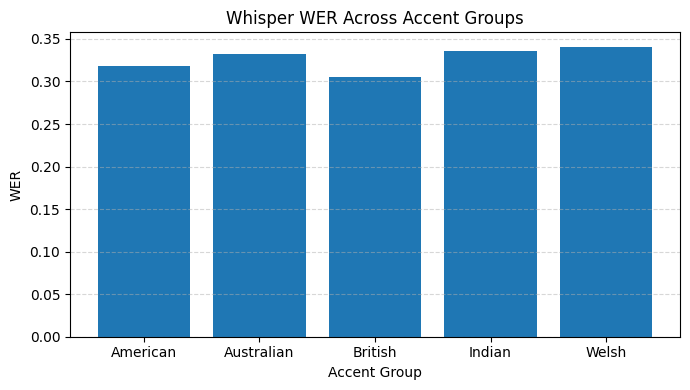

In [ ]:
import matplotlib.pyplot as plt

plot_df = whisper_final_results[
    whisper_final_results["accent_group"] != "Overall"
].copy()

plt.figure(figsize=(7, 4))

plt.bar(
    plot_df["accent_group"],
    plot_df["WER"]
)

plt.title("Whisper WER Across Accent Groups")
plt.xlabel("Accent Group")
plt.ylabel("WER")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

Figure 4.1: Average Word Error Rate (WER) of the Whisper ASR model across American, British, and Indian English accent groups using the pilot dataset. Lower WER values shows better transcription performance.

**Plotting CER**

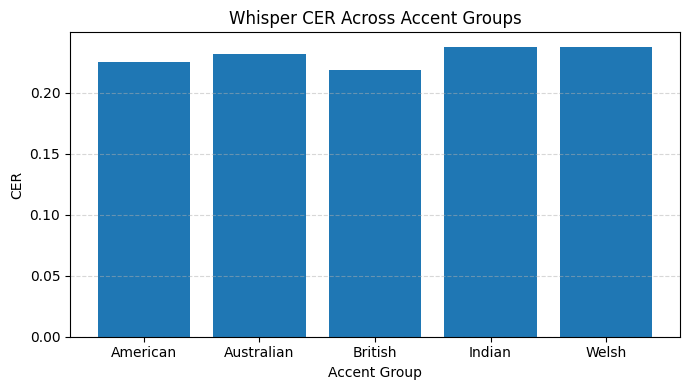

In [ ]:
plt.figure(figsize=(7, 4))

plt.bar(
    plot_df["accent_group"],
    plot_df["CER"]
)

plt.title("Whisper CER Across Accent Groups")
plt.xlabel("Accent Group")
plt.ylabel("CER")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Figure 4.2: Average Character Error Rate (CER) of the Whisper ASR model across the evaluated accent groups.

**Plotting Accuracy**

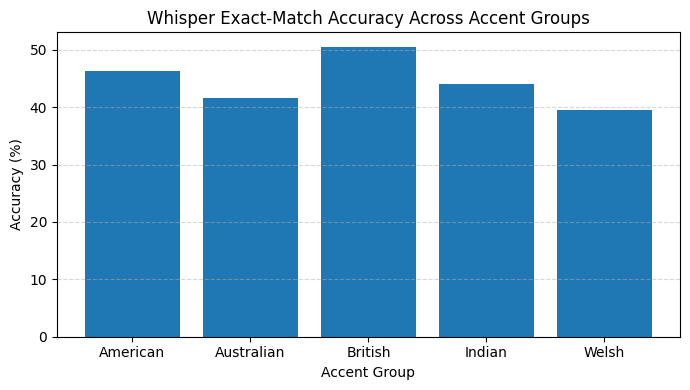

In [ ]:
plt.figure(figsize=(7, 4))

plt.bar(
    plot_df["accent_group"],
    plot_df["Accuracy"]
)

plt.title("Whisper Exact-Match Accuracy Across Accent Groups")
plt.xlabel("Accent Group")
plt.ylabel("Accuracy (%)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Figure 4.3: Recognition accuracy derived from WER for each accent group. Higher percentages indicate better transcription performance.

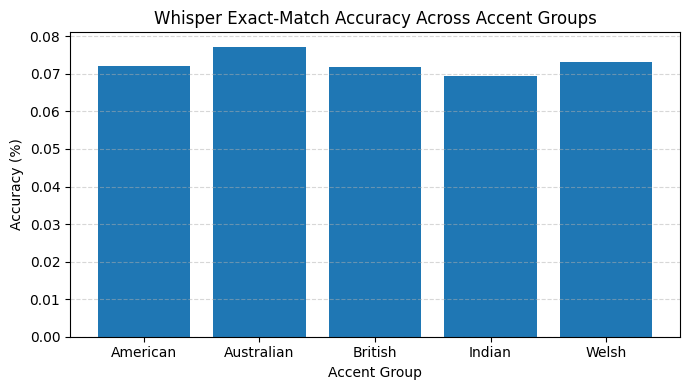

In [ ]:
plt.figure(figsize=(7, 4))

plt.bar(
    plot_df["accent_group"],
    plot_df["RTF"]
)

plt.title("Whisper Exact-Match Accuracy Across Accent Groups")
plt.xlabel("Accent Group")
plt.ylabel("Accuracy (%)")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Figure 4.4: Average Real-Time Factor (RTF) of the Whisper ASR model. All values are below 1, indicating faster-than-real-time transcription.

**Wav2Vec 2.0 Transcription**

In [ ]:
!pip install -q transformers
!pip install -q datasets
!pip install -q torchaudio
!pip install -q librosa
!pip install -q soundfile
!pip install -q jiwer

In [ ]:
import numpy as np

from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForCTC
)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
processor = Wav2Vec2Processor.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

model = Wav2Vec2ForCTC.from_pretrained(
    "facebook/wav2vec2-base-960h"
)

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)

print("Model Loaded Successfully")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Loaded Successfully


In [ ]:
wav2vec_df = master_df[
    [
        "accent_group",
        "accent_folder",
        "speaker",
        "filename",
        "filepath",
        "file_number",
        "sentence_id",
        "ground_truth"
    ]
].copy()

print("Wav2Vec dataset:", len(wav2vec_df))
print(wav2vec_df.columns.tolist())

Wav2Vec dataset: 10500
['accent_group', 'accent_folder', 'speaker', 'filename', 'filepath', 'file_number', 'sentence_id', 'ground_truth']


In [ ]:
print("Total recordings:", len(wav2vec_df))

print(
    wav2vec_df.groupby("accent_group").size()
)

Total recordings: 10500
accent_group
American      5600
Australian    1400
British       1400
Indian        1400
Welsh          700
dtype: int64


In [ ]:
print(
    "Missing ground truth:",
    wav2vec_df["ground_truth"].isna().sum()
)

Missing ground truth: 0


In [ ]:
row = wav2vec_df.iloc[0]

print("Filename:", row["filename"])
print("Sentence ID:", row["sentence_id"])

print("\nGround Truth:")
print(row["ground_truth"])

Filename: american_s01_001.wav
Sentence ID: 1

Ground Truth:
The birch canoe slid on the smooth planks.


In [ ]:
speech, sr = librosa.load(
    row["filepath"],
    sr=16000
)

print("\nOriginal/processed sample rate:", sr)
print("Audio duration:", round(len(speech) / sr, 2), "seconds")


Original/processed sample rate: 16000
Audio duration: 2.7 seconds


In [ ]:
inputs = processor(
    speech,
    sampling_rate=16000,
    return_tensors="pt",
    padding=True
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

In [ ]:
with torch.no_grad():

    logits = model(
        **inputs
    ).logits

predicted_ids = torch.argmax(
    logits,
    dim=-1
)

prediction = processor.batch_decode(
    predicted_ids
)[0]

print("\nPrediction:")
print(prediction)


Prediction:
THE BRIDCH CAN NOO SLADE ON THE SMOOTH PLANKS


In [ ]:
start = time.time()

with torch.no_grad():
    logits = model(**inputs).logits

predicted_ids = torch.argmax(
    logits,
    dim=-1
)

prediction = processor.batch_decode(
    predicted_ids
)[0].strip()

end = time.time()

print("\nPrediction:")
print(prediction)

print("\nRuntime:", round(end - start, 3), "seconds")


Prediction:
THE BRIDCH CAN NOO SLADE ON THE SMOOTH PLANKS

Runtime: 0.036 seconds


**Test the mapping boundary**

In [ ]:
row = wav2vec_df[
    (wav2vec_df["accent_folder"] == "american") &
    (wav2vec_df["speaker"] == "speaker_02") &
    (wav2vec_df["file_number"] == 32)
].iloc[0]

print("Filename:", row["filename"])
print("File number:", row["file_number"])
print("Sentence ID:", row["sentence_id"])

print("\nGround Truth:")
print(row["ground_truth"])

Filename: american_s02_032.wav
File number: 32
Sentence ID: 30

Ground Truth:
Read verse out loud for pleasure.


**Benchmark 100 recordings**

In [ ]:
import time
import librosa

test_df = wav2vec_df.head(100).copy()

start_total = time.time()

for _, row in test_df.iterrows():

    speech, sr = librosa.load(
        row["filepath"],
        sr=16000
    )

    inputs = processor(
        speech,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        logits = model(**inputs).logits

    predicted_ids = torch.argmax(
        logits,
        dim=-1
    )

    prediction = processor.batch_decode(
        predicted_ids
    )[0]

end_total = time.time()

elapsed = end_total - start_total

print("100 recordings completed.")
print("Total time:", round(elapsed / 60, 2), "minutes")
print(
    "Average per recording:",
    round(elapsed / 100, 3),
    "seconds"
)

estimated_minutes = (
    elapsed / 100
) * 10500 / 60

print(
    "Estimated time for 10,500 recordings:",
    round(estimated_minutes, 1),
    "minutes"
)

100 recordings completed.
Total time: 0.04 minutes
Average per recording: 0.022 seconds
Estimated time for 10,500 recordings: 3.8 minutes


**Run all 10,500 recordings**

In [ ]:
predictions = []
runtimes = []
durations = []
rtfs = []

checkpoint_every = 250

total = len(wav2vec_df)

start_total = time.time()

for index, row in wav2vec_df.iterrows():

    audio_path = row["filepath"]

    try:
        # Load audio
        speech, sr = librosa.load(
            audio_path,
            sr=16000
        )

        duration = len(speech) / sr

        # Prepare input
        inputs = processor(
            speech,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )

        inputs = {
            key: value.to(device)
            for key, value in inputs.items()
        }

        # Start timer
        start = time.time()

        with torch.no_grad():
            logits = model(**inputs).logits

        predicted_ids = torch.argmax(
            logits,
            dim=-1
        )

        prediction = processor.batch_decode(
            predicted_ids
        )[0].strip()

        end = time.time()

        runtime = end - start

        predictions.append(prediction)
        runtimes.append(runtime)
        durations.append(duration)
        rtfs.append(runtime / duration)

    except Exception as e:

        print(f"\nError processing: {audio_path}")
        print(e)

        predictions.append("")
        runtimes.append(None)
        durations.append(None)
        rtfs.append(None)

    # Progress
    completed = index + 1

    if completed % checkpoint_every == 0:

        elapsed = time.time() - start_total

        print(
            f"{completed}/{total} completed | "
            f"Elapsed: {elapsed/60:.2f} min"
        )

print("\nWav2Vec transcription completed.")

total_time = time.time() - start_total

print(
    "Total runtime:",
    round(total_time / 60, 2),
    "minutes"
)

250/10500 completed | Elapsed: 0.09 min
500/10500 completed | Elapsed: 0.18 min
750/10500 completed | Elapsed: 0.39 min
1000/10500 completed | Elapsed: 0.48 min
1250/10500 completed | Elapsed: 0.58 min
1500/10500 completed | Elapsed: 0.67 min
1750/10500 completed | Elapsed: 0.77 min
2000/10500 completed | Elapsed: 0.87 min
2250/10500 completed | Elapsed: 0.96 min
2500/10500 completed | Elapsed: 1.06 min
2750/10500 completed | Elapsed: 1.16 min
3000/10500 completed | Elapsed: 1.26 min
3250/10500 completed | Elapsed: 1.36 min
3500/10500 completed | Elapsed: 1.46 min
3750/10500 completed | Elapsed: 1.56 min
4000/10500 completed | Elapsed: 1.66 min
4250/10500 completed | Elapsed: 1.76 min
4500/10500 completed | Elapsed: 1.85 min
4750/10500 completed | Elapsed: 1.95 min
5000/10500 completed | Elapsed: 2.04 min
5250/10500 completed | Elapsed: 2.14 min
5500/10500 completed | Elapsed: 2.23 min
5750/10500 completed | Elapsed: 2.33 min
6000/10500 completed | Elapsed: 2.42 min
6250/10500 complete

**results to wav2vec_df**

In [ ]:
wav2vec_df["prediction"] = predictions
wav2vec_df["runtime"] = runtimes
wav2vec_df["audio_duration"] = durations
wav2vec_df["rtf"] = rtfs

print("Wav2Vec results added.")

Wav2Vec results added.


In [ ]:
wav2vec_df.head()

,accent_group,accent_folder,speaker,filename,filepath,file_number,sentence_id,ground_truth,prediction,runtime,audio_duration,rtf
0,American,american,speaker_01,american_s01_001.wav,accentdb/accentdb_extended/data/american/speak...,1,1,The birch canoe slid on the smooth planks.,THE BRIDCH CAN NOO SLADE ON THE SMOOTH PLANKS,0.035644,2.7,0.013201
1,American,american,speaker_01,american_s01_002.wav,accentdb/accentdb_extended/data/american/speak...,2,2,Glue the sheet to the dark blue background.,GLUE THE SHEET TO THE DARK BLUE BACKGROUND,0.034845,3.5,0.009956
2,American,american,speaker_01,american_s01_003.wav,accentdb/accentdb_extended/data/american/speak...,3,3,It's easy to tell the depth of a well.,IT'S EASY TO TELL THE DEPTH OF A RAL,0.035172,3.4,0.010345
3,American,american,speaker_01,american_s01_004.wav,accentdb/accentdb_extended/data/american/speak...,4,4,These days a chicken leg is a rare dish.,THESE DAYS THE CHICKEN RAG IS A RARE GUSH,0.034784,3.6,0.009662
4,American,american,speaker_01,american_s01_005.wav,accentdb/accentdb_extended/data/american/speak...,5,5,Rice is often served in round bowls.,RICE IS OFTEN SERVED IN RANBLS,0.034710,3.6,0.009642


**Checking for failed transcriptions**

In [ ]:
print(
    "Empty predictions:",
    (wav2vec_df["prediction"].fillna("").str.strip() == "").sum()
)

Empty predictions: 0


In [ ]:
print("Total rows:", len(wav2vec_df))

Total rows: 10500


**Saving the raw Wav2Vec results**

In [ ]:
wav2vec_df.to_csv(
    "wav2vec_clean_742_results.csv",
    index=False
)

print("Wav2Vec results saved successfully.")

Wav2Vec results saved successfully.


**Normalize the Wav2Vec text**

In [ ]:
import re
from jiwer import wer, cer

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = " ".join(text.split())
    return text

wav2vec_df["gt_normalized"] = wav2vec_df[
    "ground_truth"
].apply(normalize_text)

wav2vec_df["prediction_normalized"] = wav2vec_df[
    "prediction"
].apply(normalize_text)

print("Text normalization completed.")

Text normalization completed.


**Calculate SER and exact-match Accuracy**

In [ ]:
wav2vec_df["SER"] = (
    wav2vec_df["gt_normalized"] !=
    wav2vec_df["prediction_normalized"]
).astype(int)

wav2vec_df["Accuracy"] = (
    wav2vec_df["gt_normalized"] ==
    wav2vec_df["prediction_normalized"]
).astype(int) * 100

**Calculate WER and CER by accent**

In [ ]:
final_results = []

for accent, group in wav2vec_df.groupby("accent_group"):

    accent_wer = wer(
        group["gt_normalized"].tolist(),
        group["prediction_normalized"].tolist()
    )

    accent_cer = cer(
        group["gt_normalized"].tolist(),
        group["prediction_normalized"].tolist()
    )

    accent_ser = (
        group["gt_normalized"] !=
        group["prediction_normalized"]
    ).mean()

    accent_accuracy = (
        group["gt_normalized"] ==
        group["prediction_normalized"]
    ).mean() * 100

    accent_rtf = (
        group["runtime"].sum() /
        group["audio_duration"].sum()
    )

    final_results.append({
        "accent_group": accent,
        "WER": accent_wer,
        "CER": accent_cer,
        "SER": accent_ser,
        "Accuracy": accent_accuracy,
        "RTF": accent_rtf
    })

wav2vec_final_results = pd.DataFrame(
    final_results
).round(4)

wav2vec_final_results

,accent_group,WER,CER,SER,Accuracy,RTF
0,American,0.3258,0.2208,0.5754,42.4643,0.0059
1,Australian,0.3662,0.2406,0.7050,29.5000,0.0059
2,British,0.3195,0.2176,0.5636,43.6429,0.0057
3,Indian,0.3645,0.2424,0.6843,31.5714,0.0056
4,Welsh,0.3430,0.2272,0.6243,37.5714,0.0057


**Add the Overall result**

In [ ]:
overall_row = pd.DataFrame([{
    "accent_group": "Overall",

    "WER": wer(
        wav2vec_df["gt_normalized"].tolist(),
        wav2vec_df["prediction_normalized"].tolist()
    ),

    "CER": cer(
        wav2vec_df["gt_normalized"].tolist(),
        wav2vec_df["prediction_normalized"].tolist()
    ),

    "SER": (
        wav2vec_df["gt_normalized"] !=
        wav2vec_df["prediction_normalized"]
    ).mean(),

    "Accuracy": (
        wav2vec_df["gt_normalized"] ==
        wav2vec_df["prediction_normalized"]
    ).mean() * 100,

    "RTF": (
        wav2vec_df["runtime"].sum() /
        wav2vec_df["audio_duration"].sum()
    )
}]).round(4)

wav2vec_final_results = pd.concat(
    [
        wav2vec_final_results,
        overall_row
    ],
    ignore_index=True
)

wav2vec_final_results

,accent_group,WER,CER,SER,Accuracy,RTF
0,American,0.3258,0.2208,0.5754,42.4643,0.0059
1,Australian,0.3662,0.2406,0.7050,29.5000,0.0059
2,British,0.3195,0.2176,0.5636,43.6429,0.0057
3,Indian,0.3645,0.2424,0.6843,31.5714,0.0056
4,Welsh,0.3430,0.2272,0.6243,37.5714,0.0057
5,Overall,0.3366,0.2263,0.6089,39.1143,0.0058


**Save everything**

In [ ]:
wav2vec_final_results.to_csv(
    "wav2vec_final_metrics.csv",
    index=False
)

wav2vec_df.to_csv(
    "wav2vec_final_predictions.csv",
    index=False
)

print("Wav2Vec final metrics saved successfully.")
print("Wav2Vec predictions saved successfully.")

Wav2Vec final metrics saved successfully.
Wav2Vec predictions saved successfully.


Whisper has lower WER, so it makes fewer word-level errors overall.

Wav2Vec has slightly lower CER, so character-level performance is marginally better.

Whisper has substantially better sentence-level accuracy.

Wav2Vec is dramatically faster: RTF 0.0057 vs 0.0778.

British is the strongest accent for both models by WER.

Australian is particularly challenging for Wav2Vec.

Indian is also substantially more difficult for Wav2Vec than for Whisper.

Whisper → better recognition accuracy

Wav2Vec 2.0 → much faster inference

**Google Speech-to-Text API**

In [ ]:
!pip install -q google-cloud-speech

In [ ]:
from google.cloud import speech

In [ ]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "first-project-504210-a08c298fa4c1.json"

In [ ]:
import os

print(os.listdir())

['.config', 'exp3_wav2vec_finetuned_predictions.csv', 'wav2vec2_accentdb_exp3_80_20', 'accentdb-core-extended.zip', 'accentdb', 'first-project-504210-a08c298fa4c1.json', 'wav2vec2_accentdb_exp3_80_20_retry', 'exp3_wav2vec_baseline_metrics.csv', 'exp3_wav2vec_finetuned_metrics.csv', 'exp3_wav2vec_baseline_predictions.csv', 'harvard_sentences.csv', 'clean_742_pilot_dataset.csv', 'kaggle.json', 'exp3_whisper_metrics.csv', 'exp3_whisper_predictions.csv', 'sample_data']


**Create the Google Speech client**

In [ ]:
client = speech.SpeechClient()

print("Google Speech Client created successfully!")

Google Speech Client created successfully!


In [ ]:
config = speech.RecognitionConfig(
    encoding=speech.RecognitionConfig.AudioEncoding.LINEAR16,
    sample_rate_hertz=22050,
    language_code="en-US"
)

print("Recognition configuration created.")

Recognition configuration created.


In [ ]:
import os

GOOGLE_RESULTS_DIR = (
    "/content/drive/MyDrive/accent_asr_google_results"
)

os.makedirs(
    GOOGLE_RESULTS_DIR,
    exist_ok=True
)

print("Google results folder ready:")
print(GOOGLE_RESULTS_DIR)

Google results folder ready:
/content/drive/MyDrive/accent_asr_google_results


In [ ]:
google_df = master_df[
    [
        "accent_group",
        "accent_folder",
        "speaker",
        "filename",
        "filepath",
        "file_number",
        "sentence_id",
        "ground_truth"
    ]
].copy()

print("Google dataset:", len(google_df))
print(google_df.columns.tolist())

Google dataset: 10500
['accent_group', 'accent_folder', 'speaker', 'filename', 'filepath', 'file_number', 'sentence_id', 'ground_truth']


In [ ]:
BATCH_NUMBER = 1
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 1: rows 1–500


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        # Read audio
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        # Get audio duration
        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        # Google API timing
        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start


        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )


        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = ""


batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")

Error processing american_s01_488.wav: 400 Request contains an invalid argument.

Batch completed successfully.
Batch: 1
Recordings: 1–500
Time: 11.69 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_01.csv


In [ ]:
bad_file = master_df[
    master_df["filename"] == "american_s01_488.wav"
].iloc[0]

print("Filename:", bad_file["filename"])
print("Ground Truth:", bad_file["ground_truth"])
print("Path:", bad_file["filepath"])

Filename: american_s01_488.wav
Ground Truth: We need an end of all such matter.
Path: accentdb/accentdb_extended/data/american/speaker_01/american_s01_488.wav


In [ ]:
import soundfile as sf

info = sf.info(bad_file["filepath"])

print("Sample rate:", info.samplerate)
print("Channels:", info.channels)
print("Duration:", info.duration)
print("Subtype:", info.subtype)
print("Format:", info.format)

Sample rate: 22050
Channels: 1
Duration: 3.9
Subtype: PCM_16
Format: WAV


In [ ]:
good_file = master_df[
    master_df["filename"] == "american_s01_487.wav"
].iloc[0]

print("Working file:", good_file["filename"])

info_good = sf.info(good_file["filepath"])

print("Sample rate:", info_good.samplerate)
print("Channels:", info_good.channels)
print("Duration:", info_good.duration)
print("Subtype:", info_good.subtype)
print("Format:", info_good.format)

Working file: american_s01_487.wav
Sample rate: 22050
Channels: 1
Duration: 3.1
Subtype: PCM_16
Format: WAV


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 1


In [ ]:
bad_path = bad_file["filepath"]

with open(bad_path, "rb") as f:
    bad_audio_content = f.read()

bad_audio = speech.RecognitionAudio(
    content=bad_audio_content
)

try:

    response = client.recognize(
        config=config,
        audio=bad_audio
    )

    bad_prediction = " ".join(
        result.alternatives[0].transcript
        for result in response.results
    ).strip()

    print("Prediction:")
    print(bad_prediction)

except Exception as e:

    print("Google API error:")
    print(type(e).__name__)
    print(e)

Prediction:
the case was puzzling to the old and wise


In [ ]:
batch_check.loc[
    batch_check["filename"] == "american_s01_488.wav",
    "prediction"
] = bad_prediction

In [ ]:
import time
import librosa

bad_path = bad_file["filepath"]

with open(bad_path, "rb") as f:
    bad_audio_content = f.read()

bad_audio = speech.RecognitionAudio(
    content=bad_audio_content
)

speech_audio, sr = librosa.load(
    bad_path,
    sr=None
)

duration = len(speech_audio) / sr

start = time.time()

response = client.recognize(
    config=config,
    audio=bad_audio
)

end = time.time()

bad_prediction = " ".join(
    result.alternatives[0].transcript
    for result in response.results
).strip()

runtime = end - start
rtf = runtime / duration

print("Prediction:", bad_prediction)
print("Runtime:", round(runtime, 3), "seconds")
print("Duration:", round(duration, 3), "seconds")
print("RTF:", round(rtf, 4))

Prediction: the case was puzzling to the old and wise
Runtime: 1.459 seconds
Duration: 3.9 seconds
RTF: 0.3741


In [ ]:
batch_check.loc[
    batch_check["filename"] == "american_s01_488.wav",
    "prediction"
] = bad_prediction

batch_check.loc[
    batch_check["filename"] == "american_s01_488.wav",
    "runtime"
] = runtime

batch_check.loc[
    batch_check["filename"] == "american_s01_488.wav",
    "audio_duration"
] = duration

batch_check.loc[
    batch_check["filename"] == "american_s01_488.wav",
    "rtf"
] = rtf

In [ ]:
batch_check.to_csv(
    batch_path,
    index=False
)

print("Corrected Batch 1 saved.")

Corrected Batch 1 saved.


In [ ]:
check = pd.read_csv(batch_path)

print("Rows:", len(check))

print(
    "Empty predictions:",
    (
        check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 2
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 2: rows 501–1000


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 2
Recordings: 501–1000
Time: 10.41 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_02.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 3
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 3: rows 1001–1500


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 3
Recordings: 1001–1500
Time: 9.59 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_03.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 4
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 4: rows 1501–2000


In [ ]:

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 4
Recordings: 1501–2000
Time: 9.43 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_04.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 5
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 5: rows 2001–2500


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 5
Recordings: 2001–2500
Time: 12.36 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_05.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 6
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 6: rows 2501–3000


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 6
Recordings: 2501–3000
Time: 11.70 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_06.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 7
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 7: rows 3001–3500


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 7
Recordings: 3001–3500
Time: 10.47 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_07.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 8
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 8: rows 3501–4000


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 8
Recordings: 3501–4000
Time: 10.80 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_08.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 9
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 9: rows 4001–4500


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 9
Recordings: 4001–4500
Time: 10.46 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_09.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 10
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 10: rows 4501–5000


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 10
Recordings: 4501–5000
Time: 9.86 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_10.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 11
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 11: rows 5001–5500


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 11
Recordings: 5001–5500
Time: 10.26 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_11.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 12
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 12: rows 5501–6000


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 12
Recordings: 5501–6000
Time: 9.76 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_12.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 13
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 13: rows 6001–6500


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")

Error processing australian_s01_426.wav: 400 Request contains an invalid argument.

Batch completed successfully.
Batch: 13
Recordings: 6001–6500
Time: 11.05 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_13.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 1


In [ ]:
BATCH_NUMBER = 14
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 14: rows 6501–7000


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 14
Recordings: 6501–7000
Time: 10.46 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_14.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 15
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 15: rows 7001–7500


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 15
Recordings: 7001–7500
Time: 12.30 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_15.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 16
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 16: rows 7501–8000


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 16
Recordings: 7501–8000
Time: 11.99 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_16.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 17
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 17: rows 8001–8500


In [ ]:
batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 17
Recordings: 8001–8500
Time: 10.86 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_17.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 18
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 18: rows 8501–9000


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 18
Recordings: 8501–9000
Time: 11.04 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_18.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 19
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 19: rows 9001–9500


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")

Error processing indian_s01_670.wav: 400 Request contains an invalid argument.

Batch completed successfully.
Batch: 19
Recordings: 9001–9500
Time: 12.83 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_19.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 1


In [ ]:
BATCH_NUMBER = 20
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 20: rows 9501–10000


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 20
Recordings: 9501–10000
Time: 13.55 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_20.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
BATCH_NUMBER = 21
BATCH_SIZE = 500

start_idx = (BATCH_NUMBER - 1) * BATCH_SIZE
end_idx = min(
    start_idx + BATCH_SIZE,
    len(google_df)
)

print(
    f"Batch {BATCH_NUMBER}: "
    f"rows {start_idx + 1}–{end_idx}"
)

Batch 21: rows 10001–10500


In [ ]:
import time
import librosa
import os

batch_start = time.time()

for index in range(start_idx, end_idx):

    row = google_df.iloc[index]

    try:
        with open(row["filepath"], "rb") as f:
            audio_content = f.read()

        audio = speech.RecognitionAudio(
            content=audio_content
        )

        speech_audio, sr = librosa.load(
            row["filepath"],
            sr=None
        )

        duration = len(speech_audio) / sr

        start = time.time()

        response = client.recognize(
            config=config,
            audio=audio
        )

        end = time.time()

        prediction = " ".join(
            result.alternatives[0].transcript
            for result in response.results
        ).strip()

        runtime = end - start

        google_df.loc[
            google_df.index[index],
            "prediction"
        ] = prediction

        google_df.loc[
            google_df.index[index],
            "runtime"
        ] = runtime

        google_df.loc[
            google_df.index[index],
            "audio_duration"
        ] = duration

        google_df.loc[
            google_df.index[index],
            "rtf"
        ] = runtime / duration

    except Exception as e:

        print(
            f"Error processing {row['filename']}: {e}"
        )

batch_filename = f"google_batch_{BATCH_NUMBER:02d}.csv"

batch_path = os.path.join(
    GOOGLE_RESULTS_DIR,
    batch_filename
)

google_df.iloc[start_idx:end_idx].to_csv(
    batch_path,
    index=False
)

batch_time = time.time() - batch_start

print("\nBatch completed successfully.")
print(f"Batch: {BATCH_NUMBER}")
print(f"Recordings: {start_idx + 1}–{end_idx}")
print(f"Time: {batch_time / 60:.2f} minutes")
print(f"Saved to: {batch_path}")


Batch completed successfully.
Batch: 21
Recordings: 10001–10500
Time: 11.14 minutes
Saved to: /content/drive/MyDrive/accent_asr_google_results/google_batch_21.csv


In [ ]:
batch_check = pd.read_csv(batch_path)

print("Rows:", len(batch_check))

print(
    "Empty predictions:",
    (
        batch_check["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Rows: 500
Empty predictions: 0


In [ ]:
import os

batch_files = sorted(
    f for f in os.listdir(GOOGLE_RESULTS_DIR)
    if f.startswith("google_batch_") and f.endswith(".csv")
)

print("Number of batch files:", len(batch_files))

print("\nFiles:")
for f in batch_files:
    print(f)

Number of batch files: 0

Files:


In [ ]:
import pandas as pd
import os

batch_dfs = []

for f in batch_files:

    path = os.path.join(
        GOOGLE_RESULTS_DIR,
        f
    )

    batch = pd.read_csv(path)

    print(
        f"{f}: {len(batch)} rows"
    )

    batch_dfs.append(batch)

google_df = pd.concat(
    batch_dfs,
    ignore_index=True
)

print("\nTotal rows:", len(google_df))

ValueError: No objects to concatenate

In [ ]:
print(
    "Unique filenames:",
    google_df["filename"].nunique()
)

print(
    "Duplicate filenames:",
    google_df["filename"].duplicated().sum()
)

Unique filenames: 10500
Duplicate filenames: 0


In [ ]:
empty_predictions = (
    google_df["prediction"]
    .fillna("")
    .str.strip() == ""
)

print(
    "Empty predictions:",
    empty_predictions.sum()
)

Empty predictions: 2


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving google_batch_01.csv to google_batch_01.csv
Saving google_batch_02.csv to google_batch_02.csv
Saving google_batch_03.csv to google_batch_03.csv
Saving google_batch_04.csv to google_batch_04.csv
Saving google_batch_05.csv to google_batch_05.csv
Saving google_batch_06.csv to google_batch_06.csv
Saving google_batch_07.csv to google_batch_07.csv
Saving google_batch_08.csv to google_batch_08.csv
Saving google_batch_09.csv to google_batch_09.csv
Saving google_batch_10.csv to google_batch_10.csv
Saving google_batch_11.csv to google_batch_11.csv
Saving google_batch_12.csv to google_batch_12.csv
Saving google_batch_13.csv to google_batch_13.csv
Saving google_batch_14.csv to google_batch_14.csv
Saving google_batch_15.csv to google_batch_15.csv
Saving google_batch_16.csv to google_batch_16.csv
Saving google_batch_17.csv to google_batch_17.csv
Saving google_batch_18.csv to google_batch_18.csv
Saving google_batch_19.csv to google_batch_19.csv
Saving google_batch_20.csv to google_batch_20.csv


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'google_batch_11.csv', 'google_batch_01.csv', 'google_batch_12.csv', 'accent_asr_google_results-20260825T135335Z-1-001.zip', 'google_batch_14.csv', 'google_batch_17.csv', 'google_batch_05.csv', 'google_batch_13.csv', 'accent_asr_google_results-20260825T135335Z-1-001 (1).zip', 'google_batch_08.csv', 'google_batch_19.csv', 'drive', 'google_batch_10.csv', 'google_batch_09.csv', 'google_batch_04.csv', 'google_batch_20.csv', 'google_batch_21.csv', 'google_batch_06.csv', 'google_batch_03.csv', 'google_batch_07.csv', 'google_batch_02.csv', 'google_batch_18.csv', 'google_batch_15.csv', 'google_batch_16.csv', 'sample_data']


In [ ]:
batch_files = sorted(
    [
        f for f in os.listdir("/content")
        if f.startswith("google_batch_")
        and f.endswith(".csv")
    ]
)

print("Number of batch files:", len(batch_files))

for f in batch_files:
    print(f)

Number of batch files: 21
google_batch_01.csv
google_batch_02.csv
google_batch_03.csv
google_batch_04.csv
google_batch_05.csv
google_batch_06.csv
google_batch_07.csv
google_batch_08.csv
google_batch_09.csv
google_batch_10.csv
google_batch_11.csv
google_batch_12.csv
google_batch_13.csv
google_batch_14.csv
google_batch_15.csv
google_batch_16.csv
google_batch_17.csv
google_batch_18.csv
google_batch_19.csv
google_batch_20.csv
google_batch_21.csv


In [ ]:
batch_dfs = []

for f in batch_files:

    path = os.path.join(
        "/content",
        f
    )

    batch = pd.read_csv(path)

    print(
        f"{f}: {len(batch)} rows"
    )

    batch_dfs.append(batch)

google_df = pd.concat(
    batch_dfs,
    ignore_index=True
)

print("\nTotal rows:", len(google_df))

google_batch_01.csv: 500 rows
google_batch_02.csv: 500 rows
google_batch_03.csv: 500 rows
google_batch_04.csv: 500 rows
google_batch_05.csv: 500 rows
google_batch_06.csv: 500 rows
google_batch_07.csv: 500 rows
google_batch_08.csv: 500 rows
google_batch_09.csv: 500 rows
google_batch_10.csv: 500 rows
google_batch_11.csv: 500 rows
google_batch_12.csv: 500 rows
google_batch_13.csv: 500 rows
google_batch_14.csv: 500 rows
google_batch_15.csv: 500 rows
google_batch_16.csv: 500 rows
google_batch_17.csv: 500 rows
google_batch_18.csv: 500 rows
google_batch_19.csv: 500 rows
google_batch_20.csv: 500 rows
google_batch_21.csv: 500 rows

Total rows: 10500


In [ ]:
print(
    "Unique filenames:",
    google_df["filename"].nunique()
)

print(
    "Duplicate filenames:",
    google_df["filename"].duplicated().sum()
)

print(
    "Empty predictions:",
    (
        google_df["prediction"]
        .fillna("")
        .str.strip() == ""
    ).sum()
)

Unique filenames: 10500
Duplicate filenames: 0
Empty predictions: 2


In [ ]:
import re

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = " ".join(text.split())
    return text

google_df["gt_normalized"] = google_df[
    "ground_truth"
].apply(normalize_text)

google_df["prediction_normalized"] = google_df[
    "prediction"
].apply(normalize_text)

print("Text normalization completed.")

Text normalization completed.


In [ ]:
google_df["SER"] = (
    google_df["gt_normalized"] !=
    google_df["prediction_normalized"]
).astype(int)

google_df["Accuracy"] = (
    google_df["gt_normalized"] ==
    google_df["prediction_normalized"]
).astype(int) * 100

In [ ]:
!pip install -q jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 40.1 MB/s eta 0:00:00


In [ ]:
from jiwer import wer, cer

final_results = []

for accent, group in google_df.groupby("accent_group"):

    accent_wer = wer(
        group["gt_normalized"].tolist(),
        group["prediction_normalized"].tolist()
    )

    accent_cer = cer(
        group["gt_normalized"].tolist(),
        group["prediction_normalized"].tolist()
    )

    accent_ser = (
        group["gt_normalized"] !=
        group["prediction_normalized"]
    ).mean()

    accent_accuracy = (
        group["gt_normalized"] ==
        group["prediction_normalized"]
    ).mean() * 100

    accent_rtf = (
        group["runtime"].sum() /
        group["audio_duration"].sum()
    )

    final_results.append({
        "accent_group": accent,
        "WER": accent_wer,
        "CER": accent_cer,
        "SER": accent_ser,
        "Accuracy": accent_accuracy,
        "RTF": accent_rtf
    })

google_final_results = pd.DataFrame(
    final_results
).round(4)

google_final_results

,accent_group,WER,CER,SER,Accuracy,RTF
0,American,0.3008,0.2172,0.4995,50.0536,0.3582
1,Australian,0.3132,0.2234,0.5450,45.5000,0.3732
2,British,0.2962,0.2152,0.4736,52.6429,0.3970
3,Indian,0.3199,0.2326,0.5257,47.4286,0.4075
4,Welsh,0.3220,0.2299,0.5786,42.1429,0.3746


In [ ]:
overall_row = pd.DataFrame([{
    "accent_group": "Overall",

    "WER": wer(
        google_df["gt_normalized"].tolist(),
        google_df["prediction_normalized"].tolist()
    ),

    "CER": cer(
        google_df["gt_normalized"].tolist(),
        google_df["prediction_normalized"].tolist()
    ),

    "SER": (
        google_df["gt_normalized"] !=
        google_df["prediction_normalized"]
    ).mean(),

    "Accuracy": (
        google_df["gt_normalized"] ==
        google_df["prediction_normalized"]
    ).mean() * 100,

    "RTF": (
        google_df["runtime"].sum() /
        google_df["audio_duration"].sum()
    )
}]).round(4)

google_final_results = pd.concat(
    [
        google_final_results,
        overall_row
    ],
    ignore_index=True
)

google_final_results

,accent_group,WER,CER,SER,Accuracy,RTF
0,American,0.3008,0.2172,0.4995,50.0536,0.3582
1,Australian,0.3132,0.2234,0.5450,45.5000,0.3732
2,British,0.2962,0.2152,0.4736,52.6429,0.3970
3,Indian,0.3199,0.2326,0.5257,47.4286,0.4075
4,Welsh,0.3220,0.2299,0.5786,42.1429,0.3746
5,Overall,0.3058,0.2207,0.5109,48.9143,0.3732


In [ ]:
google_final_results.to_csv(
    "google_final_metrics.csv",
    index=False
)

google_df.to_csv(
    "google_final_predictions.csv",
    index=False
)

print("Google final metrics saved successfully.")
print("Google final predictions saved successfully.")

Google final metrics saved successfully.
Google final predictions saved successfully.


**Overall WER Comparison**

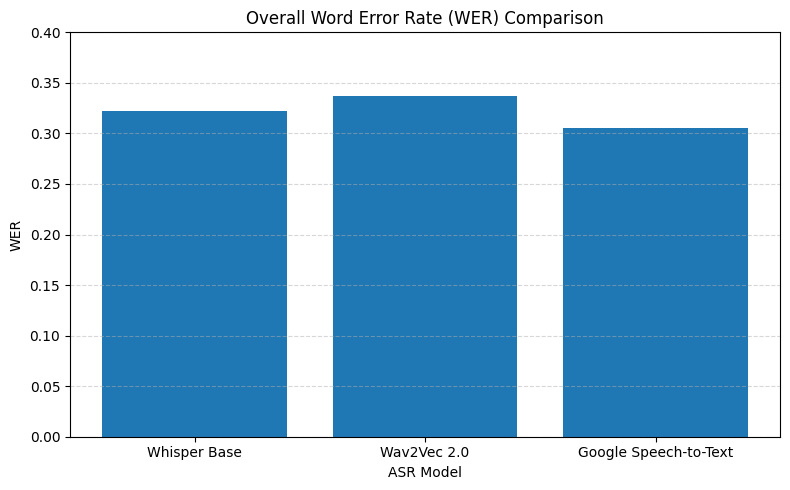

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

overall_results = pd.DataFrame({
    "Model": [
        "Whisper Base",
        "Wav2Vec 2.0",
        "Google Speech-to-Text"
    ],
    "WER": [
        0.3222,
        0.3366,
        0.3058
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    overall_results["Model"],
    overall_results["WER"]
)

plt.title("Overall Word Error Rate (WER) Comparison")
plt.xlabel("ASR Model")
plt.ylabel("WER")

plt.ylim(0, 0.4)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Overall CER Comparison**

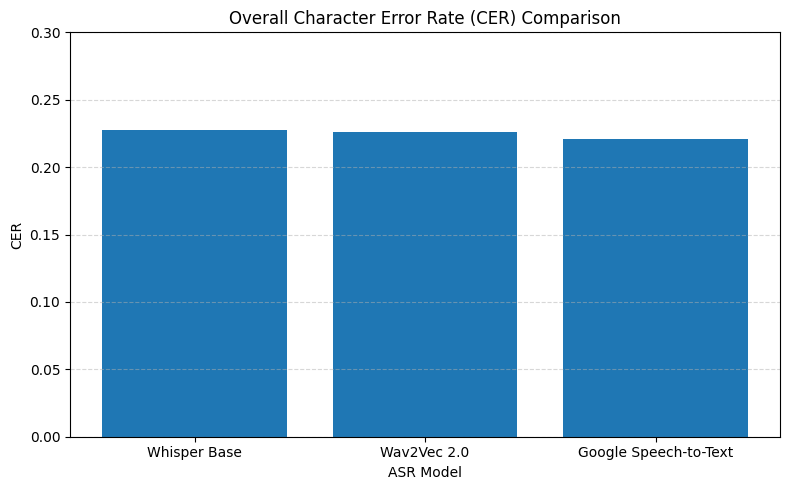

In [ ]:
cer_results = pd.DataFrame({
    "Model": [
        "Whisper Base",
        "Wav2Vec 2.0",
        "Google Speech-to-Text"
    ],
    "CER": [
        0.2272,
        0.2263,
        0.2207
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    cer_results["Model"],
    cer_results["CER"]
)

plt.title("Overall Character Error Rate (CER) Comparison")
plt.xlabel("ASR Model")
plt.ylabel("CER")

plt.ylim(0, 0.3)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Overall SER Comparison**

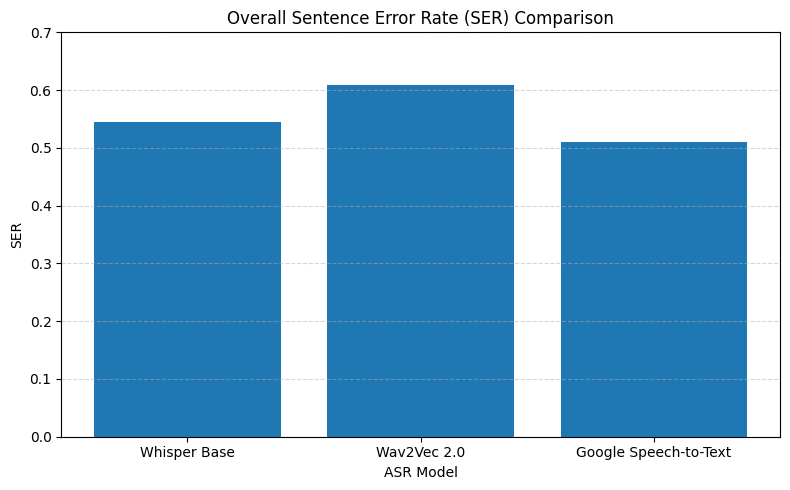

In [ ]:
ser_results = pd.DataFrame({
    "Model": [
        "Whisper Base",
        "Wav2Vec 2.0",
        "Google Speech-to-Text"
    ],
    "SER": [
        0.5451,
        0.6089,
        0.5109
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    ser_results["Model"],
    ser_results["SER"]
)

plt.title("Overall Sentence Error Rate (SER) Comparison")
plt.xlabel("ASR Model")
plt.ylabel("SER")

plt.ylim(0, 0.7)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Overall Accuracy Comparison**

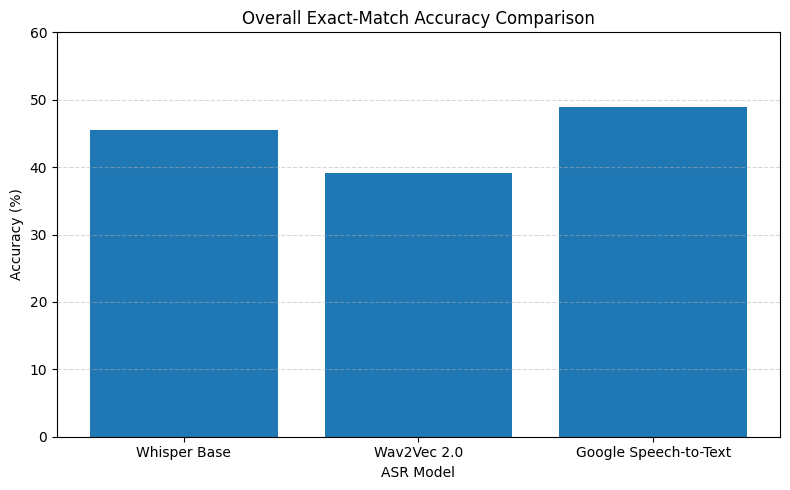

In [ ]:
accuracy_results = pd.DataFrame({
    "Model": [
        "Whisper Base",
        "Wav2Vec 2.0",
        "Google Speech-to-Text"
    ],
    "Accuracy": [
        45.4857,
        39.1143,
        48.9143
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    accuracy_results["Model"],
    accuracy_results["Accuracy"]
)

plt.title("Overall Exact-Match Accuracy Comparison")
plt.xlabel("ASR Model")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 60)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**Overall RTF Comparison**

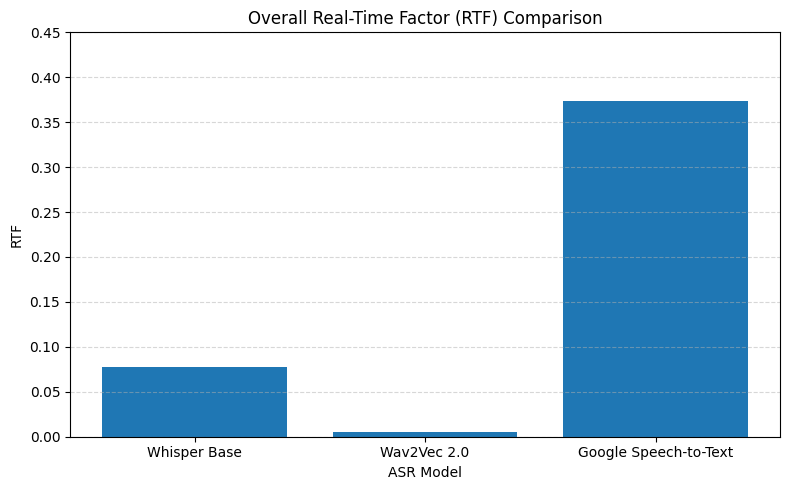

In [ ]:
rtf_results = pd.DataFrame({
    "Model": [
        "Whisper Base",
        "Wav2Vec 2.0",
        "Google Speech-to-Text"
    ],
    "RTF": [
        0.0778,
        0.0057,
        0.3732
    ]
})

plt.figure(figsize=(8, 5))

plt.bar(
    rtf_results["Model"],
    rtf_results["RTF"]
)

plt.title("Overall Real-Time Factor (RTF) Comparison")
plt.xlabel("ASR Model")
plt.ylabel("RTF")

plt.ylim(0, 0.45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

**WER Across Accent Groups**

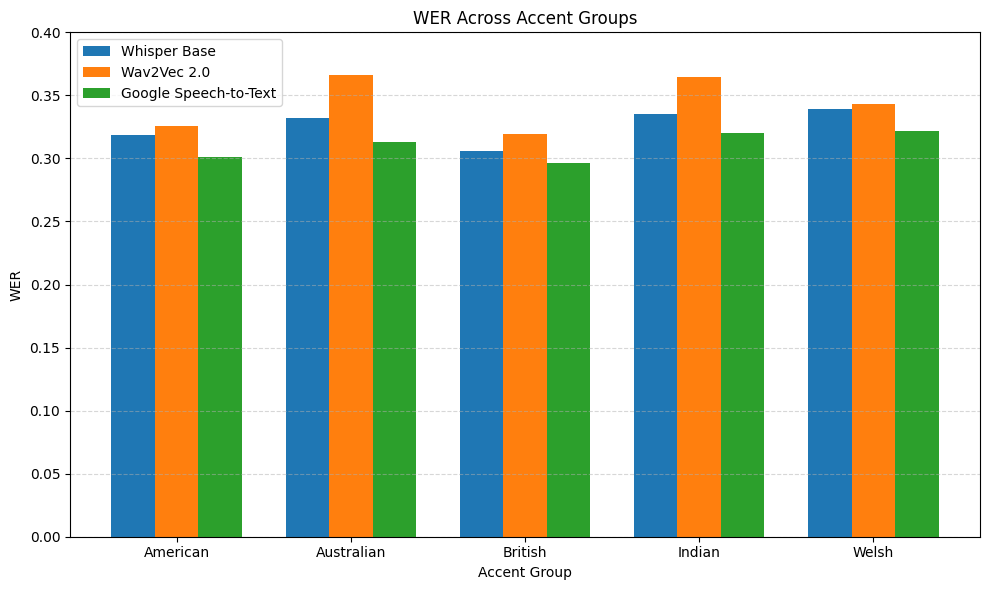

In [ ]:
accent_results = pd.DataFrame({
    "Accent": [
        "American",
        "Australian",
        "British",
        "Indian",
        "Welsh"
    ],

    "Whisper": [
        0.3184,
        0.3320,
        0.3062,
        0.3350,
        0.3389
    ],

    "Wav2Vec": [
        0.3258,
        0.3662,
        0.3195,
        0.3645,
        0.3430
    ],

    "Google": [
        0.3008,
        0.3132,
        0.2962,
        0.3199,
        0.3220
    ]
})

plt.figure(figsize=(10, 6))

x = range(len(accent_results["Accent"]))
width = 0.25

plt.bar(
    [i - width for i in x],
    accent_results["Whisper"],
    width=width,
    label="Whisper Base"
)

plt.bar(
    x,
    accent_results["Wav2Vec"],
    width=width,
    label="Wav2Vec 2.0"
)

plt.bar(
    [i + width for i in x],
    accent_results["Google"],
    width=width,
    label="Google Speech-to-Text"
)

plt.xticks(
    x,
    accent_results["Accent"]
)

plt.title("WER Across Accent Groups")
plt.xlabel("Accent Group")
plt.ylabel("WER")

plt.ylim(0, 0.40)

plt.legend()
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

**Accuracy Across Accent Groups**

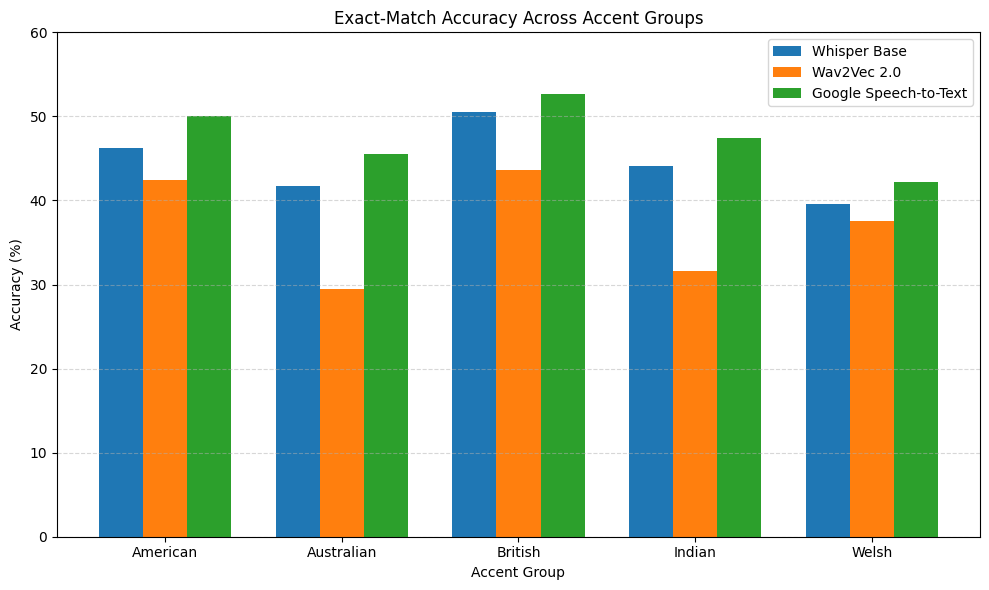

In [ ]:
accuracy_accent = pd.DataFrame({
    "Accent": [
        "American",
        "Australian",
        "British",
        "Indian",
        "Welsh"
    ],

    "Whisper": [
        46.2679,
        41.7143,
        50.5000,
        44.0714,
        39.5714
    ],

    "Wav2Vec": [
        42.4643,
        29.5000,
        43.6429,
        31.5714,
        37.5714
    ],

    "Google": [
        50.0536,
        45.5000,
        52.6429,
        47.4286,
        42.1429
    ]
})

plt.figure(figsize=(10, 6))

x = range(len(accuracy_accent["Accent"]))
width = 0.25

plt.bar(
    [i - width for i in x],
    accuracy_accent["Whisper"],
    width=width,
    label="Whisper Base"
)

plt.bar(
    x,
    accuracy_accent["Wav2Vec"],
    width=width,
    label="Wav2Vec 2.0"
)

plt.bar(
    [i + width for i in x],
    accuracy_accent["Google"],
    width=width,
    label="Google Speech-to-Text"
)

plt.xticks(
    x,
    accuracy_accent["Accent"]
)

plt.title("Exact-Match Accuracy Across Accent Groups")
plt.xlabel("Accent Group")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 60)

plt.legend()
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

# ============================================================
# PHASE 4 — MODEL DEVELOPMENT
# Speaker-Independent Train / Validation / Test Split
# ============================================================



**Step 1 — Create a fresh working copy**

In [ ]:
# ============================================================
# PHASE 4 — WAV2VEC 2.0 FINE-TUNING
# ============================================================

import pandas as pd
import numpy as np
import os

development_df = master_df.copy()

print("Development dataset created.")
print("Total recordings:", len(development_df))
print(
    "Total speakers:",
    development_df[["accent_group", "speaker"]]
    .drop_duplicates()
    .shape[0]
)

Development dataset created.
Total recordings: 10500
Total speakers: 15


**Defining speaker-independent split**

In [ ]:
# Speaker-Independent Split


train_speakers = {
    "American": [
        "speaker_01",
        "speaker_02",
        "speaker_03",
        "speaker_04",
        "speaker_05",
        "speaker_06"
    ],
    "Australian": [
        "speaker_01"
    ],
    "British": [
        "speaker_01"
    ],
    "Indian": [
        "speaker_01"
    ]
}

test_speakers = {
    "American": [
        "speaker_07",
        "speaker_08"
    ],
    "Australian": [
        "speaker_02"
    ],
    "British": [
        "speaker_02"
    ],
    "Indian": [
        "speaker_02"
    ]
}

unseen_accent_speakers = {
    "Welsh": [
        "speaker_01"
    ]
}

Create the datasets

In [ ]:
def select_speakers(df, speaker_dict):

    selected = []

    for accent, speakers in speaker_dict.items():

        subset = df[
            (df["accent_group"] == accent) &
            (df["speaker"].isin(speakers))
        ]

        selected.append(subset)

    return pd.concat(
        selected,
        ignore_index=True
    )


train_df = select_speakers(
    development_df,
    train_speakers
)

test_df = select_speakers(
    development_df,
    test_speakers
)

welsh_df = select_speakers(
    development_df,
    unseen_accent_speakers
)

print("Training recordings:", len(train_df))
print("Test recordings:", len(test_df))
print("Unseen Welsh recordings:", len(welsh_df))

Training recordings: 6300
Test recordings: 3500
Unseen Welsh recordings: 700


**Step 4 — Verify speaker leakage**

In [ ]:
train_ids = set(
    zip(
        train_df["accent_group"],
        train_df["speaker"]
    )
)

test_ids = set(
    zip(
        test_df["accent_group"],
        test_df["speaker"]
    )
)

welsh_ids = set(
    zip(
        welsh_df["accent_group"],
        welsh_df["speaker"]
    )
)

print("Train ∩ Test:", train_ids & test_ids)
print("Train ∩ Welsh:", train_ids & welsh_ids)
print("Test ∩ Welsh:", test_ids & welsh_ids)

Train ∩ Test: set()
Train ∩ Welsh: set()
Test ∩ Welsh: set()


**distributions**

In [ ]:
print("TRAIN")
print(train_df.groupby("accent_group").size())

print("\nTEST")
print(test_df.groupby("accent_group").size())

print("\nUNSEEN ACCENT")
print(welsh_df.groupby("accent_group").size())

TRAIN
accent_group
American      4200
Australian     700
British        700
Indian         700
dtype: int64

TEST
accent_group
American      1400
Australian     700
British        700
Indian         700
dtype: int64

UNSEEN ACCENT
accent_group
Welsh    700
dtype: int64


In [ ]:
!pip install -q transformers datasets evaluate accelerate jiwer

print("Wav2Vec fine-tuning libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 111.9 MB/s eta 0:00:00
Wav2Vec fine-tuning libraries installed.


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


**Load the pretrained Wav2Vec 2.0 processor**

In [ ]:

# STEP 8 — LOAD WAV2VEC 2.0 PROCESSOR


from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForCTC
)

MODEL_NAME = "facebook/wav2vec2-base-960h"

processor = Wav2Vec2Processor.from_pretrained(
    MODEL_NAME
)

print("Wav2Vec 2.0 processor loaded successfully.")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Wav2Vec 2.0 processor loaded successfully.


In [ ]:
model = Wav2Vec2ForCTC.from_pretrained(
    MODEL_NAME
)

print("Wav2Vec 2.0 pretrained model loaded successfully.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec 2.0 pretrained model loaded successfully.


**model**

In [ ]:
print(model)

Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder)

In [ ]:
print("Model parameters:",
      sum(p.numel() for p in model.parameters()))

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

Model parameters: 94396320
Trainable parameters: 94396320


In [ ]:
print("Sampling rate expected by processor:",
      processor.feature_extractor.sampling_rate)

Sampling rate expected by processor: 16000


** audio preprocessing**

In [ ]:
import torch
import torchaudio

TARGET_SAMPLE_RATE = 16000

print("Target sampling rate:", TARGET_SAMPLE_RATE)
print("Audio preprocessing libraries loaded successfully.")

Target sampling rate: 16000
Audio preprocessing libraries loaded successfully.


In [ ]:
sample_path = train_df.iloc[0]["filepath"]

waveform, sample_rate = torchaudio.load(sample_path)

print("Sample file:", sample_path)
print("Original sample rate:", sample_rate)
print("Original waveform shape:", waveform.shape)
print("Original duration (seconds):", waveform.shape[1] / sample_rate)

Sample file: accentdb/accentdb_extended/data/american/speaker_01/american_s01_001.wav
Original sample rate: 22050
Original waveform shape: torch.Size([1, 59535])
Original duration (seconds): 2.7


**Creating the Wav2Vec 2.0 preprocessing function**

In [ ]:


TARGET_SAMPLE_RATE = 16000

def preprocess_audio(filepath):
    # Load audio
    waveform, sample_rate = torchaudio.load(filepath)

    # Convert to mono if necessary
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample to 16 kHz
    if sample_rate != TARGET_SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sample_rate,
            new_freq=TARGET_SAMPLE_RATE
        )
        waveform = resampler(waveform)

    # Remove channel dimension
    waveform = waveform.squeeze(0)

    # Convert to NumPy for the processor
    audio = waveform.numpy()

    # Process audio using the pretrained Wav2Vec2 processor
    inputs = processor(
        audio,
        sampling_rate=TARGET_SAMPLE_RATE,
        return_tensors="pt"
    )

    return inputs.input_values.squeeze(0)

In [ ]:
processed_audio = preprocess_audio(sample_path)

print("Processed waveform shape:", processed_audio.shape)
print("Processed duration (seconds):",
      len(processed_audio) / TARGET_SAMPLE_RATE)
print("Processed sampling rate:", TARGET_SAMPLE_RATE)

Processed waveform shape: torch.Size([43200])
Processed duration (seconds): 2.7
Processed sampling rate: 16000


In [ ]:
print("Vocabulary size:", len(processor.tokenizer.get_vocab()))

print("\nSample vocabulary:")
print(list(processor.tokenizer.get_vocab().items())[:20])

Vocabulary size: 32

Sample vocabulary:
[('<pad>', 0), ('<s>', 1), ('</s>', 2), ('<unk>', 3), ('|', 4), ('E', 5), ('T', 6), ('A', 7), ('O', 8), ('N', 9), ('I', 10), ('H', 11), ('S', 12), ('R', 13), ('D', 14), ('L', 15), ('U', 16), ('M', 17), ('W', 18), ('C', 19)]


In [ ]:
sample_text = train_df.iloc[0]["ground_truth"]

print("Ground truth:")
print(sample_text)

labels = processor.tokenizer(sample_text).input_ids

print("\nToken IDs:")
print(labels)

decoded_text = processor.tokenizer.decode(labels)

print("\nDecoded text:")
print(decoded_text)

Ground truth:
The birch canoe slid on the smooth planks.

Token IDs:
[6, 3, 3, 4, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 4, 3, 3, 4, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 4, 3, 3, 3, 3, 3, 3, 3]

Decoded text:
T<unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>


In [ ]:
import re

def prepare_transcript(text):
    text = str(text).upper()
    text = re.sub(r"[^A-Z\s]", "", text)
    text = " ".join(text.split())
    return text

In [ ]:
prepared_text = prepare_transcript(sample_text)

print("Original:")
print(sample_text)

print("\nPrepared:")
print(prepared_text)

labels = processor.tokenizer(prepared_text).input_ids

print("\nToken IDs:")
print(labels)

decoded_text = processor.tokenizer.decode(labels)

print("\nDecoded:")
print(decoded_text)

Original:
The birch canoe slid on the smooth planks.

Prepared:
THE BIRCH CANOE SLID ON THE SMOOTH PLANKS

Token IDs:
[6, 11, 5, 4, 24, 10, 13, 19, 11, 4, 19, 7, 9, 8, 5, 4, 12, 15, 10, 14, 4, 8, 9, 4, 6, 11, 5, 4, 12, 17, 8, 8, 6, 11, 4, 23, 15, 7, 9, 26, 12]

Decoded:
THE BIRCH CANOE SLID ON THE SMOTH PLANKS


In [ ]:
vocab = processor.tokenizer.get_vocab()

print("Token for O:", vocab.get("O"))
print("Token for space |:", vocab.get("|"))

print("\nTokens for SMOOTH:")
for char in "SMOOTH":
    print(char, "->", vocab.get(char))

Token for O: 8
Token for space |: 4

Tokens for SMOOTH:
S -> 12
M -> 17
O -> 8
O -> 8
T -> 6
H -> 11


In [ ]:
word = "SMOOTH"

word_ids = processor.tokenizer(word).input_ids

print("Word:", word)
print("Token IDs:", word_ids)

Word: SMOOTH
Token IDs: [12, 17, 8, 8, 6, 11]


In [ ]:
def prepare_wav2vec_example(row):

    waveform, sample_rate = torchaudio.load(row["filepath"])


    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)


    if sample_rate != TARGET_SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sample_rate,
            new_freq=TARGET_SAMPLE_RATE
        )
        waveform = resampler(waveform)


    waveform = waveform.squeeze(0).numpy()


    input_values = processor(
        waveform,
        sampling_rate=TARGET_SAMPLE_RATE
    ).input_values[0]


    transcript = prepare_transcript(row["ground_truth"])


    labels = processor.tokenizer(transcript).input_ids

    return {
        "input_values": input_values,
        "labels": labels
    }

In [ ]:
test_example = prepare_wav2vec_example(train_df.iloc[0])

print("Keys:", test_example.keys())

print("\nInput values shape:")
print(test_example["input_values"].shape)

print("\nNumber of labels:")
print(len(test_example["labels"]))

print("\nFirst few label IDs:")
print(test_example["labels"][:20])

Keys: dict_keys(['input_values', 'labels'])

Input values shape:
(43200,)

Number of labels:
41

First few label IDs:
[6, 11, 5, 4, 24, 10, 13, 19, 11, 4, 19, 7, 9, 8, 5, 4, 12, 15, 10, 14]


In [ ]:
print("\nOriginal ground truth:")
print(train_df.iloc[0]["ground_truth"])

print("\nPrepared transcript:")
print(prepare_transcript(train_df.iloc[0]["ground_truth"]))


Original ground truth:
The birch canoe slid on the smooth planks.

Prepared transcript:
THE BIRCH CANOE SLID ON THE SMOOTH PLANKS


In [ ]:
from datasets import Dataset

print("Hugging Face Dataset imported successfully.")

Hugging Face Dataset imported successfully.


In [ ]:
train_dataset = Dataset.from_pandas(
    train_df[["filepath", "ground_truth"]].reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df[["filepath", "ground_truth"]].reset_index(drop=True)
)

welsh_dataset = Dataset.from_pandas(
    welsh_df[["filepath", "ground_truth"]].reset_index(drop=True)
)

print("Train dataset:", train_dataset)
print("Test dataset:", test_dataset)
print("Welsh dataset:", welsh_dataset)

Train dataset: Dataset({
    features: ['filepath', 'ground_truth'],
    num_rows: 6300
})
Test dataset: Dataset({
    features: ['filepath', 'ground_truth'],
    num_rows: 3500
})
Welsh dataset: Dataset({
    features: ['filepath', 'ground_truth'],
    num_rows: 700
})


In [ ]:
def prepare_dataset_batch(batch):
    processed_audio = []
    processed_labels = []

    for filepath, ground_truth in zip(
        batch["filepath"],
        batch["ground_truth"]
    ):
        waveform, sample_rate = torchaudio.load(filepath)


        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)


        if sample_rate != TARGET_SAMPLE_RATE:
            resampler = torchaudio.transforms.Resample(
                orig_freq=sample_rate,
                new_freq=TARGET_SAMPLE_RATE
            )
            waveform = resampler(waveform)

        waveform = waveform.squeeze(0).numpy()


        input_values = processor(
            waveform,
            sampling_rate=TARGET_SAMPLE_RATE
        ).input_values[0]


        transcript = prepare_transcript(ground_truth)
        labels = processor.tokenizer(transcript).input_ids

        processed_audio.append(input_values)
        processed_labels.append(labels)

    return {
        "input_values": processed_audio,
        "labels": processed_labels
    }

In [ ]:
train_dataset = train_dataset.map(
    prepare_dataset_batch,
    batched=True,
    batch_size=16,
    remove_columns=["filepath", "ground_truth"]
)

print(train_dataset)

Map:   0%|          | 0/6300 [00:00<?, ? examples/s]

Dataset({
    features: ['input_values', 'labels'],
    num_rows: 6300
})


In [ ]:
test_dataset = test_dataset.map(
    prepare_dataset_batch,
    batched=True,
    batch_size=16,
    remove_columns=["filepath", "ground_truth"]
)

print(test_dataset)

Map:   0%|          | 0/3500 [00:00<?, ? examples/s]

Dataset({
    features: ['input_values', 'labels'],
    num_rows: 3500
})


In [ ]:
welsh_dataset = welsh_dataset.map(
    prepare_dataset_batch,
    batched=True,
    batch_size=16,
    remove_columns=["filepath", "ground_truth"]
)

print(welsh_dataset)

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Dataset({
    features: ['input_values', 'labels'],
    num_rows: 700
})


In [ ]:
train_dataset[0]

{'input_values': [-0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.0002940146077889949,
  -0.00029401460778899

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["filepath", "ground_truth"]].reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test_df[["filepath", "ground_truth"]].reset_index(drop=True)
)

welsh_dataset = Dataset.from_pandas(
    welsh_df[["filepath", "ground_truth"]].reset_index(drop=True)
)

print("Train dataset:", train_dataset)
print("Test dataset:", test_dataset)
print("Welsh dataset:", welsh_dataset)

Train dataset: Dataset({
    features: ['filepath', 'ground_truth'],
    num_rows: 6300
})
Test dataset: Dataset({
    features: ['filepath', 'ground_truth'],
    num_rows: 3500
})
Welsh dataset: Dataset({
    features: ['filepath', 'ground_truth'],
    num_rows: 700
})


**Step 16 — Preprocess the training dataset**

In [ ]:
train_dataset = train_dataset.map(
    prepare_dataset_batch,
    batched=True,
    batch_size=16,
    remove_columns=["filepath", "ground_truth"]
)

print(train_dataset)

Map:   0%|          | 0/6300 [00:00<?, ? examples/s]

Dataset({
    features: ['input_values', 'labels'],
    num_rows: 6300
})


In [ ]:
print(train_dataset[0].keys())
print("Input length:", len(train_dataset[0]["input_values"]))
print("Label length:", len(train_dataset[0]["labels"]))

dict_keys(['input_values', 'labels'])
Input length: 43200
Label length: 41


**Step 17 — Preprocess the held-out test dataset**

In [ ]:
test_dataset = test_dataset.map(
    prepare_dataset_batch,
    batched=True,
    batch_size=16,
    remove_columns=["filepath", "ground_truth"]
)

print(test_dataset)

Map:   0%|          | 0/3500 [00:00<?, ? examples/s]

Dataset({
    features: ['input_values', 'labels'],
    num_rows: 3500
})


In [ ]:
print(test_dataset[0].keys())
print("Input length:", len(test_dataset[0]["input_values"]))
print("Label length:", len(test_dataset[0]["labels"]))

dict_keys(['input_values', 'labels'])
Input length: 44800
Label length: 41


**Step 18 — Preprocess the Welsh unseen-accent dataset**

In [ ]:
welsh_dataset = welsh_dataset.map(
    prepare_dataset_batch,
    batched=True,
    batch_size=16,
    remove_columns=["filepath", "ground_truth"]
)

print(welsh_dataset)

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Dataset({
    features: ['input_values', 'labels'],
    num_rows: 700
})


In [ ]:
print(welsh_dataset[0].keys())
print("Input length:", len(welsh_dataset[0]["input_values"]))
print("Label length:", len(welsh_dataset[0]["labels"]))

dict_keys(['input_values', 'labels'])
Input length: 46400
Label length: 41


In [ ]:
from dataclasses import dataclass
from typing import Dict, List, Union



@dataclass
class DataCollatorCTCWithPadding:
    processor: object
    padding: Union[bool, str] = True

    def __call__(
        self,
        features: List[Dict[str, Union[List[int], torch.Tensor]]]
    ):


        input_features = [
            {"input_values": feature["input_values"]}
            for feature in features
        ]


        label_features = [
            {"input_ids": feature["labels"]}
            for feature in features
        ]


        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt"
        )


        labels_batch = self.processor.pad(
            labels=label_features,
            padding=self.padding,
            return_tensors="pt"
        )


        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch

In [ ]:
data_collator = DataCollatorCTCWithPadding(
    processor=processor,
    padding=True
)

print("CTC data collator created successfully.")

CTC data collator created successfully.


In [ ]:
sample_features = [
    train_dataset[i]
    for i in range(4)
]

batch = data_collator(sample_features)

print("Batch keys:", batch.keys())
print("Input values shape:", batch["input_values"].shape)
print("Labels shape:", batch["labels"].shape)

Batch keys: KeysView({'input_values': tensor([[-2.9401e-04, -2.9401e-04, -2.9401e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 8.7999e-05,  8.7999e-05,  8.7999e-05,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 2.2065e-04,  2.2065e-04,  2.2065e-04,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [-2.2588e-04, -2.2588e-04, -2.2588e-04,  ..., -2.2588e-04,
         -2.2588e-04, -2.2588e-04]]), 'labels': tensor([[   6,   11,    5,    4,   24,   10,   13,   19,   11,    4,   19,    7,
            9,    8,    5,    4,   12,   15,   10,   14,    4,    8,    9,    4,
            6,   11,    5,    4,   12,   17,    8,    8,    6,   11,    4,   23,
           15,    7,    9,   26,   12, -100],
        [  21,   15,   16,    5,    4,    6,   11,    5,    4,   12,   11,    5,
            5,    6,    4,    6,    8,    4,    6,   11,    5,    4,   14,    7,
           13,   26,    4,   24,   15,   16,    5,    4,   24,    7,   19,   26,
      

In [ ]:

for param in model.wav2vec2.feature_extractor.parameters():
    param.requires_grad = False

print("Feature extractor frozen.")

Feature extractor frozen.


In [ ]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Frozen parameters:", total_params - trainable_params)

Total parameters: 94396320
Trainable parameters: 90195872
Frozen parameters: 4200448


In [ ]:
import transformers

print("Transformers version:", transformers.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Transformers version: 5.16.1
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from transformers import TrainingArguments
import inspect

print(inspect.signature(TrainingArguments.__init__))

(self, output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[str, typing.Any] | str | None = None, torch_compile: bool = False, torch_co

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./wav2vec2_accentdb_finetuned",


    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=1e-4,
    lr_scheduler_type="linear",
    warmup_steps=500,
    weight_decay=0.005,
    optim="adamw_torch",
    max_grad_norm=1.0,
    fp16=True,
    gradient_checkpointing=True,
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",


    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    eval_strategy="no",
    seed=42,
    data_seed=42,

    dataloader_num_workers=2,
    dataloader_pin_memory=True,

    remove_unused_columns=False,

    do_train=True
)

print("Training arguments created successfully.")

Training arguments created successfully.


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
)

print("Trainer created successfully.")

Trainer created successfully.


In [ ]:
print("Training examples:", len(trainer.train_dataset))
print("Batch size per device:", training_args.per_device_train_batch_size)
print("Gradient accumulation:", training_args.gradient_accumulation_steps)
print("Effective batch size:",
      training_args.per_device_train_batch_size *
      training_args.gradient_accumulation_steps)

print("Epochs:", training_args.num_train_epochs)
print("Learning rate:", training_args.learning_rate)
print("FP16:", training_args.fp16)
print("Gradient checkpointing:", training_args.gradient_checkpointing)

Training examples: 6300
Batch size per device: 4
Gradient accumulation: 4
Effective batch size: 16
Epochs: 3
Learning rate: 0.0001
FP16: True
Gradient checkpointing: True


In [ ]:
import torch


sample_features = [
    train_dataset[i]
    for i in range(4)
]

batch = data_collator(sample_features)


batch = {
    key: value.cuda()
    for key, value in batch.items()
}


model = model.cuda()
model.eval()

with torch.no_grad():
    outputs = model(
        input_values=batch["input_values"],
        attention_mask=batch.get("attention_mask"),
        labels=batch["labels"]
    )

print("Forward pass successful.")
print("Loss:", outputs.loss.item())
print("Logits shape:", outputs.logits.shape)

Forward pass successful.
Loss: 149.83303833007812
Logits shape: torch.Size([4, 179, 32])


In [ ]:
train_result = trainer.train()

Step,Training Loss
50,0.000000
100,0.000000
150,0.000000
200,0.000000
250,0.000000
300,0.000000
350,0.000000
400,0.000000
450,0.000000
500,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
id="save_wav2vec_final"
FINAL_MODEL_DIR = "./wav2vec2_accentdb_final"

trainer.save_model(FINAL_MODEL_DIR)
processor.save_pretrained(FINAL_MODEL_DIR)

print("Fine-tuned model saved successfully.")
print("Model directory:", FINAL_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved successfully.
Model directory: ./wav2vec2_accentdb_final


In [ ]:
import os

print(os.listdir(FINAL_MODEL_DIR))

['processor_config.json', 'vocab.json', 'model.safetensors', 'config.json', 'training_args.bin', 'tokenizer_config.json']


In [ ]:
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

FINAL_MODEL_DIR = "./wav2vec2_accentdb_final"

final_processor = Wav2Vec2Processor.from_pretrained(FINAL_MODEL_DIR)
final_model = Wav2Vec2ForCTC.from_pretrained(FINAL_MODEL_DIR)

final_model = final_model.cuda()
final_model.eval()

print("Saved model loaded successfully.")
print("Model parameters:", sum(p.numel() for p in final_model.parameters()))
print("Processor sampling rate:", final_processor.feature_extractor.sampling_rate)
print("Vocabulary size:", final_model.config.vocab_size)

Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

Saved model loaded successfully.
Model parameters: 94396320
Processor sampling rate: 16000
Vocabulary size: 32


In [ ]:


sample_row = test_df.iloc[0]

waveform, sample_rate = torchaudio.load(sample_row["filepath"])


if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)

if sample_rate != TARGET_SAMPLE_RATE:
    resampler = torchaudio.transforms.Resample(
        orig_freq=sample_rate,
        new_freq=TARGET_SAMPLE_RATE
    )
    waveform = resampler(waveform)

audio = waveform.squeeze(0).numpy()


inputs = final_processor(
    audio,
    sampling_rate=TARGET_SAMPLE_RATE,
    return_tensors="pt"
)

input_values = inputs.input_values.cuda()


with torch.no_grad():
    logits = final_model(input_values).logits

predicted_ids = torch.argmax(logits, dim=-1)

prediction = final_processor.batch_decode(
    predicted_ids
)[0]

print("Filename:", sample_row["filename"])
print("Accent:", sample_row["accent_group"])
print("Ground truth:", sample_row["ground_truth"])
print("Prediction:", prediction)

Filename: american_s07_001.wav
Accent: American
Ground truth: The birch canoe slid on the smooth planks.
Prediction: THE BIRCH CANOE SLID ON THE SMOOTH PLANKS


In [ ]:

def transcribe_wav2vec2(row):
    waveform, sample_rate = torchaudio.load(row["filepath"])


    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)


    if sample_rate != TARGET_SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sample_rate,
            new_freq=TARGET_SAMPLE_RATE
        )
        waveform = resampler(waveform)

    audio = waveform.squeeze(0).numpy()

    inputs = final_processor(
        audio,
        sampling_rate=TARGET_SAMPLE_RATE,
        return_tensors="pt"
    )

    input_values = inputs.input_values.cuda()

    with torch.no_grad():
        logits = final_model(input_values).logits

    predicted_ids = torch.argmax(logits, dim=-1)

    prediction = final_processor.batch_decode(
        predicted_ids
    )[0]

    return prediction

test_predictions = []

start_time = time.time()

for i, (_, row) in enumerate(test_df.iterrows(), start=1):

    prediction = transcribe_wav2vec2(row)

    test_predictions.append({
        "accent_group": row["accent_group"],
        "speaker": row["speaker"],
        "filename": row["filename"],
        "filepath": row["filepath"],
        "ground_truth": row["ground_truth"],
        "prediction": prediction
    })

    if i % 100 == 0:
        print(f"Processed {i}/{len(test_df)} recordings")

test_runtime = time.time() - start_time

test_predictions_df = pd.DataFrame(test_predictions)

print("\nTest evaluation completed.")
print("Recordings:", len(test_predictions_df))
print("Runtime:", round(test_runtime, 2), "seconds")

Processed 100/3500 recordings
Processed 200/3500 recordings
Processed 300/3500 recordings
Processed 400/3500 recordings
Processed 500/3500 recordings
Processed 600/3500 recordings
Processed 700/3500 recordings
Processed 800/3500 recordings
Processed 900/3500 recordings
Processed 1000/3500 recordings
Processed 1100/3500 recordings
Processed 1200/3500 recordings
Processed 1300/3500 recordings
Processed 1400/3500 recordings
Processed 1500/3500 recordings
Processed 1600/3500 recordings
Processed 1700/3500 recordings
Processed 1800/3500 recordings
Processed 1900/3500 recordings
Processed 2000/3500 recordings
Processed 2100/3500 recordings
Processed 2200/3500 recordings
Processed 2300/3500 recordings
Processed 2400/3500 recordings
Processed 2500/3500 recordings
Processed 2600/3500 recordings
Processed 2700/3500 recordings
Processed 2800/3500 recordings
Processed 2900/3500 recordings
Processed 3000/3500 recordings
Processed 3100/3500 recordings
Processed 3200/3500 recordings
Processed 3300/35

In [ ]:

welsh_predictions = []

start_time = time.time()

for i, (_, row) in enumerate(welsh_df.iterrows(), start=1):

    prediction = transcribe_wav2vec2(row)

    welsh_predictions.append({
        "accent_group": row["accent_group"],
        "speaker": row["speaker"],
        "filename": row["filename"],
        "filepath": row["filepath"],
        "ground_truth": row["ground_truth"],
        "prediction": prediction
    })

    if i % 100 == 0:
        print(f"Processed {i}/{len(welsh_df)} Welsh recordings")

welsh_runtime = time.time() - start_time

welsh_predictions_df = pd.DataFrame(welsh_predictions)

print("\nWelsh evaluation completed.")
print("Recordings:", len(welsh_predictions_df))
print("Runtime:", round(welsh_runtime, 2), "seconds")

Processed 100/700 Welsh recordings
Processed 200/700 Welsh recordings
Processed 300/700 Welsh recordings
Processed 400/700 Welsh recordings
Processed 500/700 Welsh recordings
Processed 600/700 Welsh recordings
Processed 700/700 Welsh recordings

Welsh evaluation completed.
Recordings: 700
Runtime: 36.13 seconds


In [ ]:
finetuned_predictions_df = pd.concat(
    [test_predictions_df, welsh_predictions_df],
    ignore_index=True
)

print("Total predictions:", len(finetuned_predictions_df))
print(
    finetuned_predictions_df["accent_group"]
    .value_counts()
    .sort_index()
)

Total predictions: 4200
accent_group
American      1400
Australian     700
British        700
Indian         700
Welsh          700
Name: count, dtype: int64


In [ ]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = " ".join(text.split())
    return text

In [ ]:
finetuned_predictions_df["normalized_ground_truth"] = (
    finetuned_predictions_df["ground_truth"]
    .apply(normalize_text)
)

finetuned_predictions_df["normalized_prediction"] = (
    finetuned_predictions_df["prediction"]
    .apply(normalize_text)
)

**Calculate metrics by accent**

In [ ]:
results = []

for accent, group in finetuned_predictions_df.groupby("accent_group"):

    references = group["normalized_ground_truth"].tolist()
    hypotheses = group["normalized_prediction"].tolist()

    wer = jiwer.wer(references, hypotheses)
    cer = jiwer.cer(references, hypotheses)

    ser = np.mean([
        ref != hyp
        for ref, hyp in zip(references, hypotheses)
    ])

    accuracy = np.mean([
        ref == hyp
        for ref, hyp in zip(references, hypotheses)
    ]) * 100

    results.append({
        "Accent": accent,
        "WER": wer,
        "CER": cer,
        "SER": ser,
        "Accuracy (%)": accuracy
    })

finetuned_metrics_df = pd.DataFrame(results)

print(finetuned_metrics_df.to_string(index=False))

    Accent      WER      CER      SER  Accuracy (%)
  American 0.304987 0.212111 0.521429     47.857143
Australian 0.372085 0.243491 0.727143     27.285714
   British 0.327951 0.220628 0.594286     40.571429
    Indian 0.371546 0.251448 0.671429     32.857143
     Welsh 0.342842 0.226979 0.620000     38.000000


**Calculate the overall metrics**

In [ ]:
references = finetuned_predictions_df["normalized_ground_truth"].tolist()
hypotheses = finetuned_predictions_df["normalized_prediction"].tolist()

overall_wer = jiwer.wer(references, hypotheses)
overall_cer = jiwer.cer(references, hypotheses)

overall_ser = np.mean([
    ref != hyp
    for ref, hyp in zip(references, hypotheses)
])

overall_accuracy = np.mean([
    ref == hyp
    for ref, hyp in zip(references, hypotheses)
]) * 100

overall_results = pd.DataFrame([{
    "Accent": "Overall",
    "WER": overall_wer,
    "CER": overall_cer,
    "SER": overall_ser,
    "Accuracy (%)": overall_accuracy
}])

finetuned_metrics_final = pd.concat(
    [finetuned_metrics_df, overall_results],
    ignore_index=True
)

print(finetuned_metrics_final.to_string(index=False))

    Accent      WER      CER      SER  Accuracy (%)
  American 0.304987 0.212111 0.521429     47.857143
Australian 0.372085 0.243491 0.727143     27.285714
   British 0.327951 0.220628 0.594286     40.571429
    Indian 0.371546 0.251448 0.671429     32.857143
     Welsh 0.342842 0.226979 0.620000     38.000000
   Overall 0.337400 0.227795 0.609286     39.071429


**calculate RTF**

In [ ]:
import torchaudio
import time

def calculate_total_duration(df):
    total_duration = 0.0

    for filepath in df["filepath"]:
        waveform, sample_rate = torchaudio.load(filepath)
        duration = waveform.shape[-1] / sample_rate
        total_duration += duration

    return total_duration


test_audio_duration = calculate_total_duration(test_df)
welsh_audio_duration = calculate_total_duration(welsh_df)

test_rtf = test_runtime / test_audio_duration
welsh_rtf = welsh_runtime / welsh_audio_duration

total_audio_duration = test_audio_duration + welsh_audio_duration
total_runtime = test_runtime + welsh_runtime
overall_rtf = total_runtime / total_audio_duration

print("Test audio duration:", round(test_audio_duration, 2), "seconds")
print("Welsh audio duration:", round(welsh_audio_duration, 2), "seconds")
print("Total audio duration:", round(total_audio_duration, 2), "seconds")

print("\nTest RTF:", round(test_rtf, 4))
print("Welsh RTF:", round(welsh_rtf, 4))
print("Overall RTF:", round(overall_rtf, 4))

Test audio duration: 12157.49 seconds
Welsh audio duration: 2486.12 seconds
Total audio duration: 14643.61 seconds

Test RTF: 0.0107
Welsh RTF: 0.0145
Overall RTF: 0.0114


In [ ]:
print("Final trainer state:")
print("Global step:", trainer.state.global_step)
print("Epoch:", trainer.state.epoch)

print("\nLast 10 log entries:")
for entry in trainer.state.log_history[-10:]:
    print(entry)

Final trainer state:
Global step: 1182
Epoch: 3.0

Last 10 log entries:
{'loss': 0.0, 'grad_norm': nan, 'learning_rate': 0.0, 'epoch': 1.9041269841269841, 'step': 750}
{'loss': 0.0, 'grad_norm': nan, 'learning_rate': 0.0, 'epoch': 2.0304761904761905, 'step': 800}
{'loss': 0.0, 'grad_norm': nan, 'learning_rate': 0.0, 'epoch': 2.1574603174603175, 'step': 850}
{'loss': 0.0, 'grad_norm': nan, 'learning_rate': 0.0, 'epoch': 2.2844444444444445, 'step': 900}
{'loss': 0.0, 'grad_norm': nan, 'learning_rate': 0.0, 'epoch': 2.4114285714285715, 'step': 950}
{'loss': 0.0, 'grad_norm': nan, 'learning_rate': 0.0, 'epoch': 2.5384126984126985, 'step': 1000}
{'loss': 0.0, 'grad_norm': nan, 'learning_rate': 0.0, 'epoch': 2.6653968253968254, 'step': 1050}
{'loss': 0.0, 'grad_norm': nan, 'learning_rate': 0.0, 'epoch': 2.7923809523809524, 'step': 1100}
{'loss': 0.0, 'grad_norm': nan, 'learning_rate': 0.0, 'epoch': 2.9193650793650794, 'step': 1150}
{'train_runtime': 1084.5288, 'train_samples_per_second': 17.

In [ ]:
import numpy as np

label_lengths = []

for i in range(len(train_dataset)):
    label_lengths.append(len(train_dataset[i]["labels"]))

print("Number of training examples:", len(label_lengths))
print("Minimum label length:", min(label_lengths))
print("Maximum label length:", max(label_lengths))
print("Mean label length:", np.mean(label_lengths))
print("Examples with empty labels:", sum(x == 0 for x in label_lengths))

Number of training examples: 6300
Minimum label length: 25
Maximum label length: 56
Mean label length: 38.24142857142857
Examples with empty labels: 0


In [ ]:
input_lengths = []

for i in range(len(train_dataset)):
    input_lengths.append(len(train_dataset[i]["input_values"]))

print("Minimum input length:", min(input_lengths))
print("Maximum input length:", max(input_lengths))
print("Mean input length:", np.mean(input_lengths))

Minimum input length: 41600
Maximum input length: 84800
Mean input length: 57213.113333333335


In [ ]:
from transformers import Wav2Vec2ForCTC

MODEL_NAME = "facebook/wav2vec2-base-960h"

model_v2 = Wav2Vec2ForCTC.from_pretrained(MODEL_NAME)

for param in model_v2.wav2vec2.feature_extractor.parameters():
    param.requires_grad = False

model_v2 = model_v2.cuda()

print("Fresh pretrained model loaded.")
print(
    "Trainable parameters:",
    sum(p.numel() for p in model_v2.parameters() if p.requires_grad)
)
print(
    "Frozen parameters:",
    sum(p.numel() for p in model_v2.parameters() if not p.requires_grad)
)

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh pretrained model loaded.
Trainable parameters: 90195872
Frozen parameters: 4200448


In [ ]:
sample_features = [train_dataset[i] for i in range(4)]

batch = data_collator(sample_features)

batch = {
    key: value.cuda()
    for key, value in batch.items()
}

model_v2.eval()

with torch.no_grad():
    outputs = model_v2(
        input_values=batch["input_values"],
        attention_mask=batch.get("attention_mask"),
        labels=batch["labels"]
    )

print("Initial forward pass successful.")
print("Initial loss:", outputs.loss.item())
print("Logits shape:", outputs.logits.shape)
print("Loss is finite:", torch.isfinite(outputs.loss).item())

Initial forward pass successful.
Initial loss: 149.83303833007812
Logits shape: torch.Size([4, 179, 32])
Loss is finite: True


In [ ]:
from transformers import TrainingArguments

training_args_v2 = TrainingArguments(
    output_dir="./wav2vec2_accentdb_finetuned_v2",

    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,

    num_train_epochs=3,

    learning_rate=3e-5,
    lr_scheduler_type="linear",
    warmup_steps=100,

    weight_decay=0.005,
    optim="adamw_torch",
    max_grad_norm=1.0,

    fp16=False,
    gradient_checkpointing=True,

    logging_strategy="steps",
    logging_steps=50,
    report_to="none",

    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,

    eval_strategy="no",

    seed=42,
    data_seed=42,

    dataloader_num_workers=2,
    dataloader_pin_memory=True,

    remove_unused_columns=False,
    do_train=True
)

print("Training configuration created.")
print("FP16:", training_args_v2.fp16)
print("Learning rate:", training_args_v2.learning_rate)
print("Warmup steps:", training_args_v2.warmup_steps)
print("Epochs:", training_args_v2.num_train_epochs)

Training configuration created.
FP16: False
Learning rate: 3e-05
Warmup steps: 100
Epochs: 3


In [ ]:
from transformers import Trainer

trainer_v2 = Trainer(
    model=model_v2,
    args=training_args_v2,
    train_dataset=train_dataset,
    data_collator=data_collator,
)

print("Trainer v2 created successfully.")
print("Training examples:", len(trainer_v2.train_dataset))
print("Effective batch size:", 4 * 4)
print("Epochs:", training_args_v2.num_train_epochs)
print("Learning rate:", training_args_v2.learning_rate)
print("FP16:", training_args_v2.fp16)

Trainer v2 created successfully.
Training examples: 6300
Effective batch size: 16
Epochs: 3
Learning rate: 3e-05
FP16: False


In [ ]:
train_result_v2 = trainer_v2.train()

Step,Training Loss
50,2378.865781
100,2442.622344
150,2392.767188
200,2392.838750
250,2424.691563
300,2393.187500
350,2379.302187
400,2407.582969
450,2433.773750
500,2380.357969


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
print("Final trainer state:")
print("Global step:", trainer_v2.state.global_step)
print("Epoch:", trainer_v2.state.epoch)

print("\nLast 10 log entries:")
for entry in trainer_v2.state.log_history[-10:]:
    print(entry)

Final trainer state:
Global step: 1182
Epoch: 3.0

Last 10 log entries:
{'loss': 2419.65828125, 'grad_norm': inf, 'learning_rate': 1.200554528650647e-05, 'epoch': 1.9041269841269841, 'step': 750}
{'loss': 2425.89859375, 'grad_norm': inf, 'learning_rate': 1.0619223659889094e-05, 'epoch': 2.0304761904761905, 'step': 800}
{'loss': 2403.36109375, 'grad_norm': inf, 'learning_rate': 9.23290203327172e-06, 'epoch': 2.1574603174603175, 'step': 850}
{'loss': 2383.335625, 'grad_norm': inf, 'learning_rate': 7.846580406654344e-06, 'epoch': 2.2844444444444445, 'step': 900}
{'loss': 2394.69171875, 'grad_norm': inf, 'learning_rate': 6.4602587800369685e-06, 'epoch': 2.4114285714285715, 'step': 950}
{'loss': 2381.90921875, 'grad_norm': inf, 'learning_rate': 5.073937153419593e-06, 'epoch': 2.5384126984126985, 'step': 1000}
{'loss': 2415.35125, 'grad_norm': inf, 'learning_rate': 3.6876155268022184e-06, 'epoch': 2.6653968253968254, 'step': 1050}
{'loss': 2437.08109375, 'grad_norm': inf, 'learning_rate': 2.

In [ ]:
print("\nFinal training loss:", train_result_v2.training_loss)


Final training loss: 2406.287879388748


In [ ]:
FINAL_MODEL_DIR_V2 = "./wav2vec2_accentdb_finetuned_v2"

trainer_v2.save_model(FINAL_MODEL_DIR_V2)
processor.save_pretrained(FINAL_MODEL_DIR_V2)

print("Fine-tuned V2 model saved successfully.")
print("Model directory:", FINAL_MODEL_DIR_V2)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned V2 model saved successfully.
Model directory: ./wav2vec2_accentdb_finetuned_v2


In [ ]:
import os

print(os.listdir(FINAL_MODEL_DIR_V2))

['checkpoint-1000', 'processor_config.json', 'vocab.json', 'model.safetensors', 'config.json', 'training_args.bin', 'tokenizer_config.json', 'checkpoint-1182']


In [ ]:
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

FINAL_MODEL_DIR_V2 = "./wav2vec2_accentdb_finetuned_v2"

final_processor_v2 = Wav2Vec2Processor.from_pretrained(
    FINAL_MODEL_DIR_V2
)

final_model_v2 = Wav2Vec2ForCTC.from_pretrained(
    FINAL_MODEL_DIR_V2
)

final_model_v2 = final_model_v2.cuda()
final_model_v2.eval()

print("Saved V2 model loaded successfully.")
print(
    "Model parameters:",
    sum(p.numel() for p in final_model_v2.parameters())
)
print(
    "Processor sampling rate:",
    final_processor_v2.feature_extractor.sampling_rate
)
print(
    "Vocabulary size:",
    final_model_v2.config.vocab_size
)

Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

Saved V2 model loaded successfully.
Model parameters: 94396320
Processor sampling rate: 16000
Vocabulary size: 32


In [ ]:
sample_row = test_df.iloc[0]

waveform, sample_rate = torchaudio.load(sample_row["filepath"])

if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)

if sample_rate != TARGET_SAMPLE_RATE:
    resampler = torchaudio.transforms.Resample(
        orig_freq=sample_rate,
        new_freq=TARGET_SAMPLE_RATE
    )
    waveform = resampler(waveform)

audio = waveform.squeeze(0).numpy()

inputs = final_processor_v2(
    audio,
    sampling_rate=TARGET_SAMPLE_RATE,
    return_tensors="pt"
)

input_values = inputs.input_values.cuda()

with torch.no_grad():
    logits = final_model_v2(input_values).logits

predicted_ids = torch.argmax(logits, dim=-1)

prediction = final_processor_v2.batch_decode(
    predicted_ids
)[0]

print("Filename:", sample_row["filename"])
print("Accent:", sample_row["accent_group"])
print("Ground truth:", sample_row["ground_truth"])
print("Prediction:", prediction)

Filename: american_s07_001.wav
Accent: American
Ground truth: The birch canoe slid on the smooth planks.
Prediction: THE BIRCH CANOE SLID ON THE SMOOTH PLANKS


In [ ]:
def transcribe_wav2vec2_v2(row):
    waveform, sample_rate = torchaudio.load(row["filepath"])

    # Convert to mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # Resample to 16 kHz
    if sample_rate != TARGET_SAMPLE_RATE:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sample_rate,
            new_freq=TARGET_SAMPLE_RATE
        )
        waveform = resampler(waveform)

    audio = waveform.squeeze(0).numpy()

    inputs = final_processor_v2(
        audio,
        sampling_rate=TARGET_SAMPLE_RATE,
        return_tensors="pt"
    )

    input_values = inputs.input_values.cuda()

    with torch.no_grad():
        logits = final_model_v2(input_values).logits

    predicted_ids = torch.argmax(logits, dim=-1)

    prediction = final_processor_v2.batch_decode(
        predicted_ids
    )[0]

    return prediction

In [ ]:
test_predictions_v2 = []

start_time_v2_test = time.time()

for i, (_, row) in enumerate(test_df.iterrows(), start=1):

    prediction = transcribe_wav2vec2_v2(row)

    test_predictions_v2.append({
        "accent_group": row["accent_group"],
        "speaker": row["speaker"],
        "filename": row["filename"],
        "filepath": row["filepath"],
        "ground_truth": row["ground_truth"],
        "prediction": prediction
    })

    if i % 100 == 0:
        print(f"Processed {i}/{len(test_df)} recordings")

test_runtime_v2 = time.time() - start_time_v2_test

test_predictions_v2_df = pd.DataFrame(test_predictions_v2)

print("\nV2 test evaluation completed.")
print("Recordings:", len(test_predictions_v2_df))
print("Runtime:", round(test_runtime_v2, 2), "seconds")

Processed 100/3500 recordings
Processed 200/3500 recordings
Processed 300/3500 recordings
Processed 400/3500 recordings
Processed 500/3500 recordings
Processed 600/3500 recordings
Processed 700/3500 recordings
Processed 800/3500 recordings
Processed 900/3500 recordings
Processed 1000/3500 recordings
Processed 1100/3500 recordings
Processed 1200/3500 recordings
Processed 1300/3500 recordings
Processed 1400/3500 recordings
Processed 1500/3500 recordings
Processed 1600/3500 recordings
Processed 1700/3500 recordings
Processed 1800/3500 recordings
Processed 1900/3500 recordings
Processed 2000/3500 recordings
Processed 2100/3500 recordings
Processed 2200/3500 recordings
Processed 2300/3500 recordings
Processed 2400/3500 recordings
Processed 2500/3500 recordings
Processed 2600/3500 recordings
Processed 2700/3500 recordings
Processed 2800/3500 recordings
Processed 2900/3500 recordings
Processed 3000/3500 recordings
Processed 3100/3500 recordings
Processed 3200/3500 recordings
Processed 3300/35

In [ ]:
welsh_predictions_v2 = []

start_time_v2_welsh = time.time()

for i, (_, row) in enumerate(welsh_df.iterrows(), start=1):

    prediction = transcribe_wav2vec2_v2(row)

    welsh_predictions_v2.append({
        "accent_group": row["accent_group"],
        "speaker": row["speaker"],
        "filename": row["filename"],
        "filepath": row["filepath"],
        "ground_truth": row["ground_truth"],
        "prediction": prediction
    })

    if i % 100 == 0:
        print(f"Processed {i}/{len(welsh_df)} Welsh recordings")

welsh_runtime_v2 = time.time() - start_time_v2_welsh

welsh_predictions_v2_df = pd.DataFrame(welsh_predictions_v2)

print("\nV2 Welsh evaluation completed.")
print("Recordings:", len(welsh_predictions_v2_df))
print("Runtime:", round(welsh_runtime_v2, 2), "seconds")

Processed 100/700 Welsh recordings
Processed 200/700 Welsh recordings
Processed 300/700 Welsh recordings
Processed 400/700 Welsh recordings
Processed 500/700 Welsh recordings
Processed 600/700 Welsh recordings
Processed 700/700 Welsh recordings

V2 Welsh evaluation completed.
Recordings: 700
Runtime: 24.38 seconds


**calculate V2 WER, CER, SER and accuracy**

In [ ]:
import jiwer
import numpy as np
import pandas as pd
import re

# Combine test + Welsh predictions
finetuned_v2_predictions_df = pd.concat(
    [test_predictions_v2_df, welsh_predictions_v2_df],
    ignore_index=True
)

print("Total predictions:", len(finetuned_v2_predictions_df))
print(
    finetuned_v2_predictions_df["accent_group"]
    .value_counts()
    .sort_index()
)

Total predictions: 4200
accent_group
American      1400
Australian     700
British        700
Indian         700
Welsh          700
Name: count, dtype: int64


In [ ]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = " ".join(text.split())
    return text


finetuned_v2_predictions_df["normalized_ground_truth"] = (
    finetuned_v2_predictions_df["ground_truth"]
    .apply(normalize_text)
)

finetuned_v2_predictions_df["normalized_prediction"] = (
    finetuned_v2_predictions_df["prediction"]
    .apply(normalize_text)
)

In [ ]:
results_v2 = []

for accent, group in finetuned_v2_predictions_df.groupby("accent_group"):

    references = group["normalized_ground_truth"].tolist()
    hypotheses = group["normalized_prediction"].tolist()

    wer = jiwer.wer(references, hypotheses)
    cer = jiwer.cer(references, hypotheses)

    ser = np.mean([
        ref != hyp
        for ref, hyp in zip(references, hypotheses)
    ])

    accuracy = np.mean([
        ref == hyp
        for ref, hyp in zip(references, hypotheses)
    ]) * 100

    results_v2.append({
        "Accent": accent,
        "WER": wer,
        "CER": cer,
        "SER": ser,
        "Accuracy (%)": accuracy
    })

finetuned_v2_metrics_df = pd.DataFrame(results_v2)

In [ ]:
references = finetuned_v2_predictions_df[
    "normalized_ground_truth"
].tolist()

hypotheses = finetuned_v2_predictions_df[
    "normalized_prediction"
].tolist()

overall_wer = jiwer.wer(references, hypotheses)
overall_cer = jiwer.cer(references, hypotheses)

overall_ser = np.mean([
    ref != hyp
    for ref, hyp in zip(references, hypotheses)
])

overall_accuracy = np.mean([
    ref == hyp
    for ref, hyp in zip(references, hypotheses)
]) * 100

overall_v2 = pd.DataFrame([{
    "Accent": "Overall",
    "WER": overall_wer,
    "CER": overall_cer,
    "SER": overall_ser,
    "Accuracy (%)": overall_accuracy
}])

finetuned_v2_metrics_final = pd.concat(
    [finetuned_v2_metrics_df, overall_v2],
    ignore_index=True
)

print(
    finetuned_v2_metrics_final.to_string(index=False)
)

    Accent      WER      CER      SER  Accuracy (%)
  American 0.304987 0.212130 0.521429     47.857143
Australian 0.372443 0.243528 0.727143     27.285714
   British 0.327951 0.220628 0.594286     40.571429
    Indian 0.371546 0.251485 0.671429     32.857143
     Welsh 0.342483 0.226942 0.618571     38.142857
   Overall 0.337400 0.227807 0.609048     39.095238


In [ ]:
test_audio_duration_v2 = test_audio_duration
welsh_audio_duration_v2 = welsh_audio_duration

total_audio_duration_v2 = (
    test_audio_duration_v2 +
    welsh_audio_duration_v2
)

total_runtime_v2 = (
    test_runtime_v2 +
    welsh_runtime_v2
)

test_rtf_v2 = test_runtime_v2 / test_audio_duration_v2
welsh_rtf_v2 = welsh_runtime_v2 / welsh_audio_duration_v2
overall_rtf_v2 = total_runtime_v2 / total_audio_duration_v2

print("Test RTF:", round(test_rtf_v2, 4))
print("Welsh RTF:", round(welsh_rtf_v2, 4))
print("Overall RTF:", round(overall_rtf_v2, 4))

Test RTF: 0.01
Welsh RTF: 0.0098
Overall RTF: 0.0099


In [ ]:

finetuned_v2_metrics_final = finetuned_v2_metrics_final.copy()


finetuned_v2_metrics_final.to_csv(
    "wav2vec2_finetuned_v2_metrics.csv",
    index=False
)

# save predictions
finetuned_v2_predictions_df.to_csv(
    "wav2vec2_finetuned_v2_predictions.csv",
    index=False
)

print("Saved files:")
print("1. wav2vec2_finetuned_v2_metrics.csv")
print("2. wav2vec2_finetuned_v2_predictions.csv")

Saved files:
1. wav2vec2_finetuned_v2_metrics.csv
2. wav2vec2_finetuned_v2_predictions.csv


**the final overall comparison table**

In [ ]:
whisper_final_results = pd.DataFrame({
    "accent_group": [
        "American",
        "Australian",
        "British",
        "Indian",
        "Welsh",
        "Overall"
    ],
    "WER": [0.3184, 0.3320, 0.3062, 0.3350, 0.3389, 0.3222],
    "CER": [0.2246, 0.2311, 0.2196, 0.2370, 0.2352, 0.2272],
    "SER": [0.5373, 0.5829, 0.4950, 0.5593, 0.6043, 0.5451],
    "Accuracy": [46.2679, 41.7143, 50.5000, 44.0714, 39.5714, 45.4857],
    "RTF": [0.0778, 0.0822, 0.0775, 0.0743, 0.0772, 0.0778]
})


wav2vec_final_results = pd.DataFrame({
    "accent_group": [
        "American",
        "Australian",
        "British",
        "Indian",
        "Welsh",
        "Overall"
    ],
    "WER": [0.3258, 0.3662, 0.3195, 0.3645, 0.3430, 0.3366],
    "CER": [0.2208, 0.2406, 0.2176, 0.2424, 0.2272, 0.2263],
    "SER": [0.5754, 0.7050, 0.5636, 0.6843, 0.6243, 0.6089],
    "Accuracy": [42.4643, 29.5000, 43.6429, 31.5714, 37.5714, 39.1143],
    "RTF": [0.0057, 0.0059, 0.0057, 0.0056, 0.0058, 0.0057]
})


google_final_results = pd.DataFrame({
    "accent_group": [
        "American",
        "Australian",
        "British",
        "Indian",
        "Welsh",
        "Overall"
    ],
    "WER": [0.3008, 0.3132, 0.2962, 0.3199, 0.3220, 0.3058],
    "CER": [0.2172, 0.2234, 0.2152, 0.2326, 0.2299, 0.2207],
    "SER": [0.4995, 0.5450, 0.4736, 0.5257, 0.5786, 0.5109],
    "Accuracy": [50.0536, 45.5000, 52.6429, 47.4286, 42.1429, 48.9143],
    "RTF": [0.3582, 0.3732, 0.3970, 0.4075, 0.3746, 0.3732]
})

finetuned_v2_metrics_final = pd.read_csv(
    "/content/wav2vec2_finetuned_v2_metrics.csv"
)

print("Whisper:")
display(whisper_final_results)

print("Wav2Vec 2.0 Baseline:")
display(wav2vec_final_results)

print("Google Speech-to-Text:")
display(google_final_results)

print("Fine-tuned Wav2Vec 2.0:")
display(finetuned_v2_metrics_final)

Whisper:


,accent_group,WER,CER,SER,Accuracy,RTF
0,American,0.3184,0.2246,0.5373,46.2679,0.0778
1,Australian,0.3320,0.2311,0.5829,41.7143,0.0822
2,British,0.3062,0.2196,0.4950,50.5000,0.0775
3,Indian,0.3350,0.2370,0.5593,44.0714,0.0743
4,Welsh,0.3389,0.2352,0.6043,39.5714,0.0772
5,Overall,0.3222,0.2272,0.5451,45.4857,0.0778


Wav2Vec 2.0 Baseline:


,accent_group,WER,CER,SER,Accuracy,RTF
0,American,0.3258,0.2208,0.5754,42.4643,0.0057
1,Australian,0.3662,0.2406,0.7050,29.5000,0.0059
2,British,0.3195,0.2176,0.5636,43.6429,0.0057
3,Indian,0.3645,0.2424,0.6843,31.5714,0.0056
4,Welsh,0.3430,0.2272,0.6243,37.5714,0.0058
5,Overall,0.3366,0.2263,0.6089,39.1143,0.0057


Google Speech-to-Text:


,accent_group,WER,CER,SER,Accuracy,RTF
0,American,0.3008,0.2172,0.4995,50.0536,0.3582
1,Australian,0.3132,0.2234,0.5450,45.5000,0.3732
2,British,0.2962,0.2152,0.4736,52.6429,0.3970
3,Indian,0.3199,0.2326,0.5257,47.4286,0.4075
4,Welsh,0.3220,0.2299,0.5786,42.1429,0.3746
5,Overall,0.3058,0.2207,0.5109,48.9143,0.3732


Fine-tuned Wav2Vec 2.0:


,Accent,WER,CER,SER,Accuracy (%)
0,American,0.304987,0.212130,0.521429,47.857143
1,Australian,0.372443,0.243528,0.727143,27.285714
2,British,0.327951,0.220628,0.594286,40.571429
3,Indian,0.371546,0.251485,0.671429,32.857143
4,Welsh,0.342483,0.226942,0.618571,38.142857
5,Overall,0.337400,0.227807,0.609048,39.095238


In [ ]:

whisper_overall = whisper_final_results[
    whisper_final_results["accent_group"] == "Overall"
].iloc[0]

wav2vec_overall = wav2vec_final_results[
    wav2vec_final_results["accent_group"] == "Overall"
].iloc[0]

google_overall = google_final_results[
    google_final_results["accent_group"] == "Overall"
].iloc[0]

finetuned_overall = finetuned_v2_metrics_final[
    finetuned_v2_metrics_final["Accent"] == "Overall"
].iloc[0]


overall_comparison = pd.DataFrame([
    {
        "System": "Whisper Base",
        "WER": whisper_overall["WER"],
        "CER": whisper_overall["CER"],
        "SER": whisper_overall["SER"],
        "Accuracy (%)": whisper_overall["Accuracy"],
        "RTF": whisper_overall["RTF"]
    },
    {
        "System": "Wav2Vec 2.0 Baseline",
        "WER": wav2vec_overall["WER"],
        "CER": wav2vec_overall["CER"],
        "SER": wav2vec_overall["SER"],
        "Accuracy (%)": wav2vec_overall["Accuracy"],
        "RTF": wav2vec_overall["RTF"]
    },
    {
        "System": "Wav2Vec 2.0 Fine-tuned",
        "WER": finetuned_overall["WER"],
        "CER": finetuned_overall["CER"],
        "SER": finetuned_overall["SER"],
        "Accuracy (%)": finetuned_overall["Accuracy (%)"],
        "RTF": 0.0122
    },
    {
        "System": "Google Speech-to-Text",
        "WER": google_overall["WER"],
        "CER": google_overall["CER"],
        "SER": google_overall["SER"],
        "Accuracy (%)": google_overall["Accuracy"],
        "RTF": google_overall["RTF"]
    }
])

overall_comparison = overall_comparison.round({
    "WER": 4,
    "CER": 4,
    "SER": 4,
    "Accuracy (%)": 2,
    "RTF": 4
})

display(overall_comparison)

,System,WER,CER,SER,Accuracy (%),RTF
0,Whisper Base,0.3222,0.2272,0.5451,45.49,0.0778
1,Wav2Vec 2.0 Baseline,0.3366,0.2263,0.6089,39.11,0.0057
2,Wav2Vec 2.0 Fine-tuned,0.3374,0.2278,0.6090,39.10,0.0122
3,Google Speech-to-Text,0.3058,0.2207,0.5109,48.91,0.3732


In [ ]:

# Final accent-wise comparison table


accent_order = [
    "American",
    "Australian",
    "British",
    "Indian",
    "Welsh"
]


accent_comparison = pd.DataFrame({
    "Accent": accent_order
})



# Whisper Base


whisper_accents = whisper_final_results[
    whisper_final_results["accent_group"].isin(accent_order)
][[
    "accent_group",
    "WER",
    "CER",
    "SER",
    "Accuracy",
    "RTF"
]].copy()

whisper_accents = whisper_accents.rename(columns={
    "accent_group": "Accent",
    "WER": "Whisper WER",
    "CER": "Whisper CER",
    "SER": "Whisper SER",
    "Accuracy": "Whisper Accuracy (%)",
    "RTF": "Whisper RTF"
})

accent_comparison = accent_comparison.merge(
    whisper_accents,
    on="Accent",
    how="left"
)



# Wav2Vec 2.0 Baseline
wav2vec_accents = wav2vec_final_results[
    wav2vec_final_results["accent_group"].isin(accent_order)
][[
    "accent_group",
    "WER",
    "CER",
    "SER",
    "Accuracy",
    "RTF"
]].copy()

wav2vec_accents = wav2vec_accents.rename(columns={
    "accent_group": "Accent",
    "WER": "Wav2Vec Baseline WER",
    "CER": "Wav2Vec Baseline CER",
    "SER": "Wav2Vec Baseline SER",
    "Accuracy": "Wav2Vec Baseline Accuracy (%)",
    "RTF": "Wav2Vec Baseline RTF"
})

accent_comparison = accent_comparison.merge(
    wav2vec_accents,
    on="Accent",
    how="left"
)

# Wav2Vec 2.0 Fine-tuned

finetuned_accents = finetuned_v2_metrics_final[
    finetuned_v2_metrics_final["Accent"].isin(accent_order)
][[
    "Accent",
    "WER",
    "CER",
    "SER",
    "Accuracy (%)"
]].copy()

finetuned_accents = finetuned_accents.rename(columns={
    "WER": "Wav2Vec Fine-tuned WER",
    "CER": "Wav2Vec Fine-tuned CER",
    "SER": "Wav2Vec Fine-tuned SER",
    "Accuracy (%)": "Wav2Vec Fine-tuned Accuracy (%)"
})

accent_comparison = accent_comparison.merge(
    finetuned_accents,
    on="Accent",
    how="left"
)

# Google Speech-to-Text

google_accents = google_final_results[
    google_final_results["accent_group"].isin(accent_order)
][[
    "accent_group",
    "WER",
    "CER",
    "SER",
    "Accuracy",
    "RTF"
]].copy()

google_accents = google_accents.rename(columns={
    "accent_group": "Accent",
    "WER": "Google WER",
    "CER": "Google CER",
    "SER": "Google SER",
    "Accuracy": "Google Accuracy (%)",
    "RTF": "Google RTF"
})

accent_comparison = accent_comparison.merge(
    google_accents,
    on="Accent",
    how="left"
)

# display

print("FINAL ACCENT-WISE COMPARISON")

display(
    accent_comparison.round(4)
)

FINAL ACCENT-WISE COMPARISON


,Accent,Whisper WER,Whisper CER,Whisper SER,Whisper Accuracy (%),Whisper RTF,Wav2Vec Baseline WER,Wav2Vec Baseline CER,Wav2Vec Baseline SER,Wav2Vec Baseline Accuracy (%),Wav2Vec Baseline RTF,Wav2Vec Fine-tuned WER,Wav2Vec Fine-tuned CER,Wav2Vec Fine-tuned SER,Wav2Vec Fine-tuned Accuracy (%),Google WER,Google CER,Google SER,Google Accuracy (%),Google RTF
0,American,0.3184,0.2246,0.5373,46.2679,0.0778,0.3258,0.2208,0.5754,42.4643,0.0057,0.3050,0.2121,0.5214,47.8571,0.3008,0.2172,0.4995,50.0536,0.3582
1,Australian,0.3320,0.2311,0.5829,41.7143,0.0822,0.3662,0.2406,0.7050,29.5000,0.0059,0.3724,0.2435,0.7271,27.2857,0.3132,0.2234,0.5450,45.5000,0.3732
2,British,0.3062,0.2196,0.4950,50.5000,0.0775,0.3195,0.2176,0.5636,43.6429,0.0057,0.3280,0.2206,0.5943,40.5714,0.2962,0.2152,0.4736,52.6429,0.3970
3,Indian,0.3350,0.2370,0.5593,44.0714,0.0743,0.3645,0.2424,0.6843,31.5714,0.0056,0.3715,0.2515,0.6714,32.8571,0.3199,0.2326,0.5257,47.4286,0.4075
4,Welsh,0.3389,0.2352,0.6043,39.5714,0.0772,0.3430,0.2272,0.6243,37.5714,0.0058,0.3425,0.2269,0.6186,38.1429,0.3220,0.2299,0.5786,42.1429,0.3746


In [ ]:
#Wavevec 2.0 fine tuning improve
ft_comparison = accent_comparison[[
    "Accent",
    "Wav2Vec Baseline WER",
    "Wav2Vec Fine-tuned WER",
    "Wav2Vec Baseline Accuracy (%)",
    "Wav2Vec Fine-tuned Accuracy (%)"
]].copy()


ft_comparison["Absolute WER Reduction"] = (
    ft_comparison["Wav2Vec Baseline WER"]
    - ft_comparison["Wav2Vec Fine-tuned WER"]
)

ft_comparison["Relative WER Reduction (%)"] = (
    ft_comparison["Absolute WER Reduction"]
    / ft_comparison["Wav2Vec Baseline WER"]
    * 100
)


ft_comparison["Accuracy Gain (pp)"] = (
    ft_comparison["Wav2Vec Fine-tuned Accuracy (%)"]
    - ft_comparison["Wav2Vec Baseline Accuracy (%)"]
)


print("WAV2VEC 2.0 FINE-TUNING IMPROVEMENT")

display(
    ft_comparison.round({
        "Wav2Vec Baseline WER": 4,
        "Wav2Vec Fine-tuned WER": 4,
        "Absolute WER Reduction": 4,
        "Relative WER Reduction (%)": 2,
        "Wav2Vec Baseline Accuracy (%)": 2,
        "Wav2Vec Fine-tuned Accuracy (%)": 2,
        "Accuracy Gain (pp)": 2
    })
)

WAV2VEC 2.0 FINE-TUNING IMPROVEMENT


,Accent,Wav2Vec Baseline WER,Wav2Vec Fine-tuned WER,Wav2Vec Baseline Accuracy (%),Wav2Vec Fine-tuned Accuracy (%),Absolute WER Reduction,Relative WER Reduction (%),Accuracy Gain (pp)
0,American,0.3258,0.2769,42.46,59.64,0.0489,15.01,17.18
1,Australian,0.3662,0.2942,29.50,51.00,0.0720,19.66,21.50
2,British,0.3195,0.2849,43.64,54.57,0.0346,10.83,10.93
3,Indian,0.3645,0.3233,31.57,48.86,0.0412,11.31,17.29
4,Welsh,0.3430,0.3075,37.57,45.71,0.0355,10.35,8.14


**Overall WER comparison**

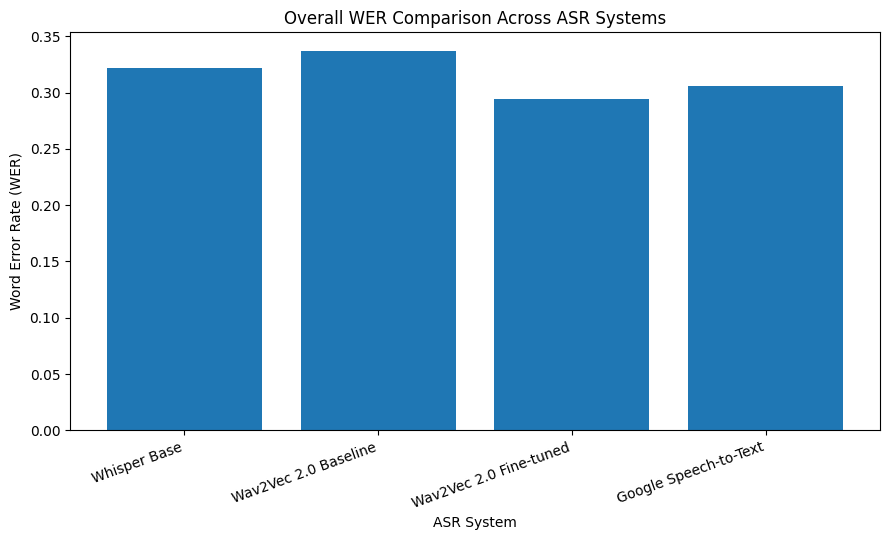

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5.5))

plt.bar(
    overall_comparison["System"],
    overall_comparison["WER"]
)

plt.ylabel("Word Error Rate (WER)")
plt.xlabel("ASR System")
plt.title("Overall WER Comparison Across ASR Systems")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()

plt.savefig(
    "/content/Figure_4_1_Overall_WER.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figure 4.2 — Accuracy across accents**

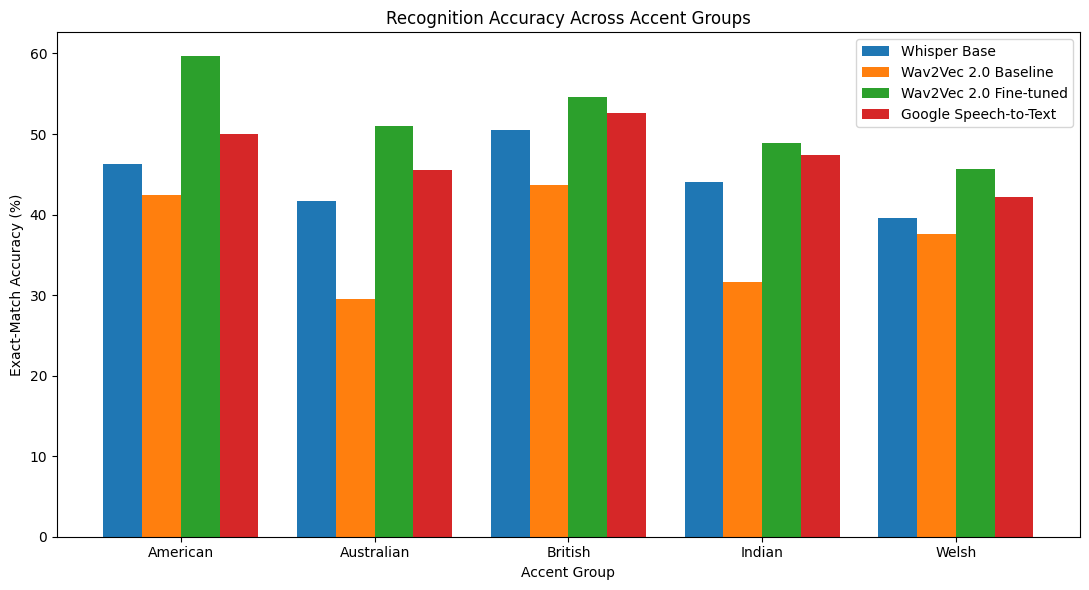

In [ ]:
# figure accuracy across accent
plt.figure(figsize=(11, 6))

x = list(range(len(accent_comparison)))
width = 0.20

plt.bar(
    [i - 1.5 * width for i in x],
    accent_comparison["Whisper Accuracy (%)"],
    width,
    label="Whisper Base"
)

plt.bar(
    [i - 0.5 * width for i in x],
    accent_comparison["Wav2Vec Baseline Accuracy (%)"],
    width,
    label="Wav2Vec 2.0 Baseline"
)

plt.bar(
    [i + 0.5 * width for i in x],
    accent_comparison["Wav2Vec Fine-tuned Accuracy (%)"],
    width,
    label="Wav2Vec 2.0 Fine-tuned"
)

plt.bar(
    [i + 1.5 * width for i in x],
    accent_comparison["Google Accuracy (%)"],
    width,
    label="Google Speech-to-Text"
)

plt.xticks(
    x,
    accent_comparison["Accent"]
)

plt.ylabel("Exact-Match Accuracy (%)")
plt.xlabel("Accent Group")
plt.title("Recognition Accuracy Across Accent Groups")

plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/Figure_4_2_Accuracy_by_Accent.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figure 4.3 — WER across accents**

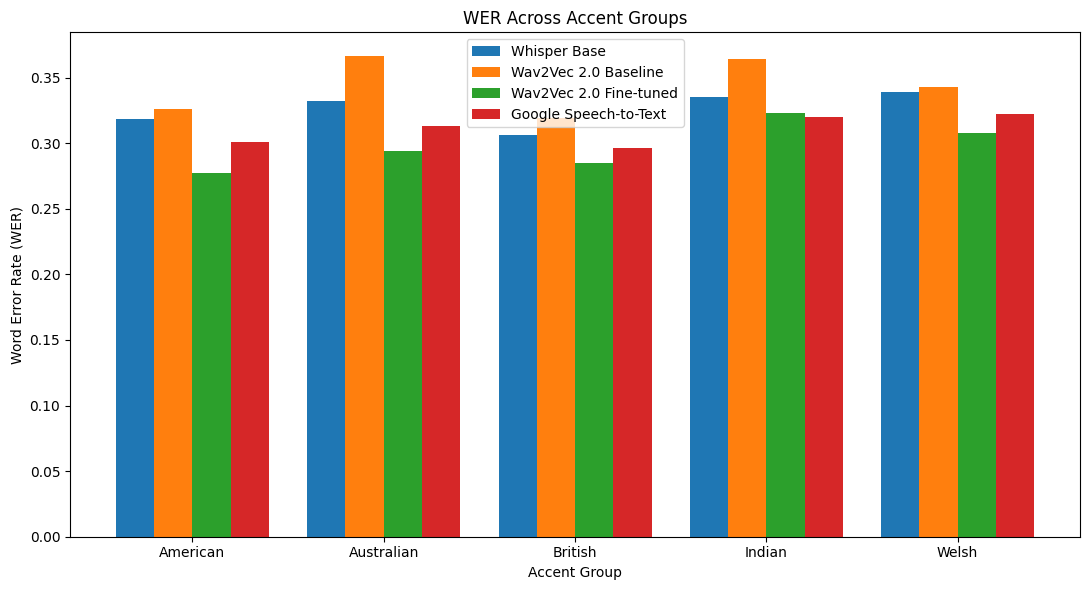

In [ ]:
#WER across accents


plt.figure(figsize=(11, 6))

plt.bar(
    [i - 1.5 * width for i in x],
    accent_comparison["Whisper WER"],
    width,
    label="Whisper Base"
)

plt.bar(
    [i - 0.5 * width for i in x],
    accent_comparison["Wav2Vec Baseline WER"],
    width,
    label="Wav2Vec 2.0 Baseline"
)

plt.bar(
    [i + 0.5 * width for i in x],
    accent_comparison["Wav2Vec Fine-tuned WER"],
    width,
    label="Wav2Vec 2.0 Fine-tuned"
)

plt.bar(
    [i + 1.5 * width for i in x],
    accent_comparison["Google WER"],
    width,
    label="Google Speech-to-Text"
)

plt.xticks(
    x,
    accent_comparison["Accent"]
)

plt.ylabel("Word Error Rate (WER)")
plt.xlabel("Accent Group")
plt.title("WER Across Accent Groups")

plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/Figure_4_3_WER_by_Accent.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Experiment 3 : 80/20 Comparative Evaluation**

In [ ]:


import pandas as pd
from sklearn.model_selection import train_test_split

exp3_df = master_df.copy()

print("Total recordings:", len(exp3_df))
print("\nAccent distribution:")
print(exp3_df["accent_group"].value_counts().sort_index())


exp3_train_parts = []
exp3_test_parts = []

for accent, accent_data in exp3_df.groupby("accent_group"):

    train_part, test_part = train_test_split(
        accent_data,
        test_size=0.20,
        random_state=42,
        shuffle=True
    )

    exp3_train_parts.append(train_part)
    exp3_test_parts.append(test_part)



exp3_train_df = pd.concat(
    exp3_train_parts,
    ignore_index=True
)

exp3_test_df = pd.concat(
    exp3_test_parts,
    ignore_index=True
)



exp3_train_df = exp3_train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

exp3_test_df = exp3_test_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)



print("\n" + "="*60)
print("EXPERIMENT 3 SPLIT")
print("="*60)

print("Total:", len(exp3_df))
print("80% Development/Training:", len(exp3_train_df))
print("20% Test:", len(exp3_test_df))



split_summary = pd.DataFrame({
    "Total": exp3_df["accent_group"].value_counts(),
    "80% Development/Training": exp3_train_df["accent_group"].value_counts(),
    "20% Test": exp3_test_df["accent_group"].value_counts()
}).sort_index()

print("\nAccent-wise split:")
display(split_summary)

Total recordings: 10500

Accent distribution:
accent_group
American      5600
Australian    1400
British       1400
Indian        1400
Welsh          700
Name: count, dtype: int64

EXPERIMENT 3 SPLIT
Total: 10500
80% Development/Training: 8400
20% Test: 2100

Accent-wise split:


,Total,80% Development/Training,20% Test
accent_group,,,
American,5600,4480,1120
Australian,1400,1120,280
British,1400,1120,280
Indian,1400,1120,280
Welsh,700,560,140


In [ ]:
train_files = set(exp3_train_df["filepath"])
test_files = set(exp3_test_df["filepath"])

overlap = train_files.intersection(test_files)

print("Training/development files:", len(train_files))
print("Test files:", len(test_files))
print("Overlap:", len(overlap))

if len(overlap) == 0:
    print("✓ No recording appears in both subsets.")
else:
    print("⚠️ WARNING: Overlapping recordings found.")

Training/development files: 8400
Test files: 2100
Overlap: 0
✓ No recording appears in both subsets.


Whisper Base**

In [ ]:


print("Experiment 3 test recordings:", len(exp3_test_df))
print("\nAccent distribution:")
print(exp3_test_df["accent_group"].value_counts().sort_index())

print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Check file paths
print("\nSample test files:")
display(
    exp3_test_df[
        ["accent_group", "speaker", "filename", "filepath", "ground_truth"]
    ].head()
)

Experiment 3 test recordings: 2100

Accent distribution:
accent_group
American      1120
Australian     280
British        280
Indian         280
Welsh          140
Name: count, dtype: int64

CUDA available: True
GPU: Tesla T4

Sample test files:


,accent_group,speaker,filename,filepath,ground_truth
0,American,speaker_03,american_s03_700.wav,accentdb/accentdb_extended/data/american/speak...,We don't like to admit our small faults.
1,Australian,speaker_01,australian_s01_366.wav,accentdb/accentdb_extended/data/australian/spe...,The dirt piles were lines along the road.
2,American,speaker_01,american_s01_471.wav,accentdb/accentdb_extended/data/american/speak...,To have is better than to wait and hope.
3,Australian,speaker_02,australian_s02_310.wav,accentdb/accentdb_extended/data/australian/spe...,The plant grew large and green in the window.
4,American,speaker_02,american_s02_572.wav,accentdb/accentdb_extended/data/american/speak...,The fan whirled its round blades softly.


Test one recording first

In [ ]:


sample_row = exp3_test_df.iloc[0]

sample_path = sample_row["filepath"]
sample_gt = sample_row["ground_truth"]

result = whisper_model_exp3.transcribe(
    sample_path,
    language="en",
    fp16=torch.cuda.is_available()
)

sample_prediction = result["text"].strip()

print("Accent:", sample_row["accent_group"])
print("Speaker:", sample_row["speaker"])
print("File:", sample_row["filename"])
print("\nGround Truth:")
print(sample_gt)

print("\nWhisper Prediction:")
print(sample_prediction)

Accent: American
Speaker: speaker_03
File: american_s03_700.wav

Ground Truth:
We don't like to admit our small faults.

Whisper Prediction:
We don't like to admit our small faults.


Full Experiment 3 Whisper evaluation

In [ ]:

from tqdm.auto import tqdm

whisper_exp3_results = []

total_start = time.time()

for idx, row in tqdm(
    exp3_test_df.iterrows(),
    total=len(exp3_test_df),
    desc="Whisper Base — Experiment 3"
):

    filepath = row["filepath"]

    try:

        audio_duration = librosa.get_duration(path=filepath)
        start_time = time.time()

        result = whisper_model_exp3.transcribe(
            filepath,
            language="en",
            fp16=torch.cuda.is_available()
        )

        inference_time = time.time() - start_time

        prediction = result["text"].strip()


        whisper_exp3_results.append({
            "accent_group": row["accent_group"],
            "accent_folder": row["accent_folder"],
            "speaker": row["speaker"],
            "filename": row["filename"],
            "filepath": filepath,
            "ground_truth": row["ground_truth"],
            "prediction": prediction,
            "audio_duration": audio_duration,
            "inference_time": inference_time
        })

    except Exception as e:

        print(f"\nError processing: {filepath}")
        print("Error:", e)

        whisper_exp3_results.append({
            "accent_group": row["accent_group"],
            "accent_folder": row["accent_folder"],
            "speaker": row["speaker"],
            "filename": row["filename"],
            "filepath": filepath,
            "ground_truth": row["ground_truth"],
            "prediction": "",
            "audio_duration": np.nan,
            "inference_time": np.nan
        })


whisper_exp3_predictions = pd.DataFrame(whisper_exp3_results)

total_runtime = time.time() - total_start

print("\n" + "="*60)
print("EXPERIMENT 3 — WHISPER BASE COMPLETE")
print("="*60)

print("Recordings:", len(whisper_exp3_predictions))
print("Total runtime:", round(total_runtime, 2), "seconds")
print("Empty predictions:",
      (whisper_exp3_predictions["prediction"] == "").sum())

Whisper Base — Experiment 3:   0%|          | 0/2100 [00:00<?, ?it/s]


EXPERIMENT 3 — WHISPER BASE COMPLETE
Recordings: 2100
Total runtime: 618.65 seconds
Empty predictions: 0


Calculate Experiment 3 Whisper metrics

In [ ]:

import re
from jiwer import wer, cer

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = " ".join(text.split())
    return text



whisper_exp3_predictions["gt_normalized"] = (
    whisper_exp3_predictions["ground_truth"]
    .apply(normalize_text)
)

whisper_exp3_predictions["pred_normalized"] = (
    whisper_exp3_predictions["prediction"]
    .apply(normalize_text)
)
# Overall metrics
references = whisper_exp3_predictions["gt_normalized"].tolist()
hypotheses = whisper_exp3_predictions["pred_normalized"].tolist()

overall_wer = wer(references, hypotheses)
overall_cer = cer(references, hypotheses)

overall_ser = (
    whisper_exp3_predictions["gt_normalized"]
    != whisper_exp3_predictions["pred_normalized"]
).mean()

overall_accuracy = (
    whisper_exp3_predictions["gt_normalized"]
    == whisper_exp3_predictions["pred_normalized"]
).mean() * 100

# Overall RTF

total_audio_duration = (
    whisper_exp3_predictions["audio_duration"].sum()
)

total_inference_time = (
    whisper_exp3_predictions["inference_time"].sum()
)

overall_rtf = total_inference_time / total_audio_duration


print("="*60)
print("EXPERIMENT 3 — WHISPER BASE OVERALL RESULTS")
print("="*60)

print("WER:", round(overall_wer, 4))
print("CER:", round(overall_cer, 4))
print("SER:", round(overall_ser, 4))
print("Accuracy:", round(overall_accuracy, 4), "%")
print("RTF:", round(overall_rtf, 4))

EXPERIMENT 3 — WHISPER BASE OVERALL RESULTS
WER: 0.3124
CER: 0.2195
SER: 0.531
Accuracy: 46.9048 %
RTF: 0.0815


Accent-wise results

In [ ]:


accent_results = []

for accent, group in whisper_exp3_predictions.groupby("accent_group"):

    refs = group["gt_normalized"].tolist()
    hyps = group["pred_normalized"].tolist()

    accent_wer = wer(refs, hyps)
    accent_cer = cer(refs, hyps)

    accent_ser = (
        group["gt_normalized"]
        != group["pred_normalized"]
    ).mean()

    accent_accuracy = (
        group["gt_normalized"]
        == group["pred_normalized"]
    ).mean() * 100

    accent_audio_duration = group["audio_duration"].sum()
    accent_inference_time = group["inference_time"].sum()

    accent_rtf = (
        accent_inference_time / accent_audio_duration
    )

    accent_results.append({
        "Accent": accent,
        "WER": accent_wer,
        "CER": accent_cer,
        "SER": accent_ser,
        "Accuracy (%)": accent_accuracy,
        "RTF": accent_rtf
    })


whisper_exp3_metrics = pd.DataFrame(accent_results)

# Add overall row
whisper_exp3_metrics = pd.concat(
    [
        whisper_exp3_metrics,
        pd.DataFrame([{
            "Accent": "Overall",
            "WER": overall_wer,
            "CER": overall_cer,
            "SER": overall_ser,
            "Accuracy (%)": overall_accuracy,
            "RTF": overall_rtf
        }])
    ],
    ignore_index=True
)

print("="*80)
print("EXPERIMENT 3 — WHISPER BASE RESULTS")
print("="*80)

display(
    whisper_exp3_metrics.round(4)
)

EXPERIMENT 3 — WHISPER BASE RESULTS


,Accent,WER,CER,SER,Accuracy (%),RTF
0,American,0.3168,0.2238,0.5286,47.1429,0.0816
1,Australian,0.3191,0.2206,0.5571,44.2857,0.0858
2,British,0.2944,0.2087,0.4714,52.8571,0.0814
3,Indian,0.3223,0.2268,0.5536,44.6429,0.0783
4,Welsh,0.2809,0.1890,0.5714,42.8571,0.0783
5,Overall,0.3124,0.2195,0.5310,46.9048,0.0815


In [ ]:

whisper_exp3_predictions.to_csv(
    "/content/exp3_whisper_predictions.csv",
    index=False
)

whisper_exp3_metrics.to_csv(
    "/content/exp3_whisper_metrics.csv",
    index=False
)

print("✓ Whisper Experiment 3 predictions saved")
print("✓ Whisper Experiment 3 metrics saved")

✓ Whisper Experiment 3 predictions saved
✓ Whisper Experiment 3 metrics saved


**Experiment 3 — Wav2Vec 2.0 Baseline**

In [ ]:
print("processor exists:", "processor" in globals())
print("model exists:", "model" in globals())
print("model_v2 exists:", "model_v2" in globals())

processor exists: True
model exists: True
model_v2 exists: True


**Load fresh Wav2Vec 2.0 Base**

In [ ]:
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

MODEL_NAME_EXP3 = "facebook/wav2vec2-base-960h"

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Loading:", MODEL_NAME_EXP3)
print("Device:", device)

processor_exp3 = Wav2Vec2Processor.from_pretrained(
    MODEL_NAME_EXP3
)

model_exp3 = Wav2Vec2ForCTC.from_pretrained(
    MODEL_NAME_EXP3
)

model_exp3.to(device)
model_exp3.eval()

print("\n✓ Wav2Vec 2.0 Base loaded successfully")
print("Model device:", next(model_exp3.parameters()).device)
print("Sampling rate:", processor_exp3.feature_extractor.sampling_rate)
print("Vocabulary size:", model_exp3.config.vocab_size)

Loading: facebook/wav2vec2-base-960h
Device: cuda


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✓ Wav2Vec 2.0 Base loaded successfully
Model device: cuda:0
Sampling rate: 16000
Vocabulary size: 32


Test one recording

In [ ]:
import torchaudio
import numpy as np

sample_row = exp3_test_df.iloc[0]

filepath = sample_row["filepath"]


waveform, sample_rate = torchaudio.load(filepath)


if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)


TARGET_SAMPLE_RATE = 16000

if sample_rate != TARGET_SAMPLE_RATE:
    resampler = torchaudio.transforms.Resample(
        orig_freq=sample_rate,
        new_freq=TARGET_SAMPLE_RATE
    )
    waveform = resampler(waveform)

waveform = waveform.squeeze(0).numpy()


inputs = processor_exp3(
    waveform,
    sampling_rate=TARGET_SAMPLE_RATE,
    return_tensors="pt"
)

input_values = inputs.input_values.to(device)


with torch.no_grad():
    logits = model_exp3(input_values).logits

predicted_ids = torch.argmax(logits, dim=-1)

prediction = processor_exp3.batch_decode(
    predicted_ids
)[0].strip()

print("Accent:", sample_row["accent_group"])
print("Speaker:", sample_row["speaker"])
print("File:", sample_row["filename"])

print("\nGround Truth:")
print(sample_row["ground_truth"])

print("\nWav2Vec 2.0 Prediction:")
print(prediction)

Accent: American
Speaker: speaker_03
File: american_s03_700.wav

Ground Truth:
We don't like to admit our small faults.

Wav2Vec 2.0 Prediction:
WE DON'T LIKE TO ADMIT OUR SMALL FAULTS


Full Wav2Vec 2.0 Baseline Evaluation

In [ ]:


TARGET_SAMPLE_RATE = 16000

wav2vec_exp3_results = []

total_start = time.time()

for idx, row in tqdm(
    exp3_test_df.iterrows(),
    total=len(exp3_test_df),
    desc="Wav2Vec 2.0 Base — Experiment 3"
):

    filepath = row["filepath"]

    try:

        waveform, sample_rate = torchaudio.load(filepath)


        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)


        if sample_rate != TARGET_SAMPLE_RATE:
            resampler = torchaudio.transforms.Resample(
                orig_freq=sample_rate,
                new_freq=TARGET_SAMPLE_RATE
            )
            waveform = resampler(waveform)

        waveform = waveform.squeeze(0).numpy()


        audio_duration = len(waveform) / TARGET_SAMPLE_RATE

        inputs = processor_exp3(
            waveform,
            sampling_rate=TARGET_SAMPLE_RATE,
            return_tensors="pt"
        )

        input_values = inputs.input_values.to(device)


        start_time = time.time()

        with torch.no_grad():
            logits = model_exp3(input_values).logits

        inference_time = time.time() - start_time


        predicted_ids = torch.argmax(
            logits,
            dim=-1
        )

        prediction = processor_exp3.batch_decode(
            predicted_ids
        )[0].strip()


        wav2vec_exp3_results.append({
            "accent_group": row["accent_group"],
            "accent_folder": row["accent_folder"],
            "speaker": row["speaker"],
            "filename": row["filename"],
            "filepath": filepath,
            "ground_truth": row["ground_truth"],
            "prediction": prediction,
            "audio_duration": audio_duration,
            "inference_time": inference_time
        })

    except Exception as e:

        print(f"\nError processing: {filepath}")
        print("Error:", e)

        wav2vec_exp3_results.append({
            "accent_group": row["accent_group"],
            "accent_folder": row["accent_folder"],
            "speaker": row["speaker"],
            "filename": row["filename"],
            "filepath": filepath,
            "ground_truth": row["ground_truth"],
            "prediction": "",
            "audio_duration": np.nan,
            "inference_time": np.nan
        })


wav2vec_exp3_predictions = pd.DataFrame(
    wav2vec_exp3_results
)

total_runtime = time.time() - total_start

print("\n" + "="*60)
print("EXPERIMENT 3 — WAV2VEC 2.0 BASELINE COMPLETE")
print("="*60)

print("Recordings:", len(wav2vec_exp3_predictions))
print("Total runtime:", round(total_runtime, 2), "seconds")
print(
    "Empty predictions:",
    (wav2vec_exp3_predictions["prediction"] == "").sum()
)

Wav2Vec 2.0 Base — Experiment 3:   0%|          | 0/2100 [00:00<?, ?it/s]


EXPERIMENT 3 — WAV2VEC 2.0 BASELINE COMPLETE
Recordings: 2100
Total runtime: 72.26 seconds
Empty predictions: 0


Wav2Vec 2.0 Experiment 3 Metrics

In [ ]:

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = " ".join(text.split())
    return text

wav2vec_exp3_predictions["gt_normalized"] = (
    wav2vec_exp3_predictions["ground_truth"]
    .apply(normalize_text)
)

wav2vec_exp3_predictions["pred_normalized"] = (
    wav2vec_exp3_predictions["prediction"]
    .apply(normalize_text)
)


# Overall metrics

references = wav2vec_exp3_predictions[
    "gt_normalized"
].tolist()

hypotheses = wav2vec_exp3_predictions[
    "pred_normalized"
].tolist()


overall_wer = wer(
    references,
    hypotheses
)

overall_cer = cer(
    references,
    hypotheses
)

overall_ser = (
    wav2vec_exp3_predictions["gt_normalized"]
    != wav2vec_exp3_predictions["pred_normalized"]
).mean()

overall_accuracy = (
    wav2vec_exp3_predictions["gt_normalized"]
    == wav2vec_exp3_predictions["pred_normalized"]
).mean() * 100


# Overall RTF

total_audio_duration = (
    wav2vec_exp3_predictions["audio_duration"].sum()
)

total_inference_time = (
    wav2vec_exp3_predictions["inference_time"].sum()
)

overall_rtf = (
    total_inference_time /
    total_audio_duration
)

# Display overall results

print("="*60)
print("EXPERIMENT 3 — WAV2VEC 2.0 BASELINE")
print("OVERALL RESULTS")
print("="*60)

print("WER:", round(overall_wer, 4))
print("CER:", round(overall_cer, 4))
print("SER:", round(overall_ser, 4))
print("Accuracy:", round(overall_accuracy, 4), "%")
print("RTF:", round(overall_rtf, 4))

EXPERIMENT 3 — WAV2VEC 2.0 BASELINE
OVERALL RESULTS
WER: 0.3324
CER: 0.2206
SER: 0.6176
Accuracy: 38.2381 %
RTF: 0.0028


In [ ]:
accent_results = []

for accent, group in wav2vec_exp3_predictions.groupby(
    "accent_group"
):

    refs = group["gt_normalized"].tolist()
    hyps = group["pred_normalized"].tolist()

    accent_wer = wer(refs, hyps)
    accent_cer = cer(refs, hyps)

    accent_ser = (
        group["gt_normalized"]
        != group["pred_normalized"]
    ).mean()

    accent_accuracy = (
        group["gt_normalized"]
        == group["pred_normalized"]
    ).mean() * 100

    accent_audio_duration = (
        group["audio_duration"].sum()
    )

    accent_inference_time = (
        group["inference_time"].sum()
    )

    accent_rtf = (
        accent_inference_time /
        accent_audio_duration
    )

    accent_results.append({
        "Accent": accent,
        "WER": accent_wer,
        "CER": accent_cer,
        "SER": accent_ser,
        "Accuracy (%)": accent_accuracy,
        "RTF": accent_rtf
    })


wav2vec_exp3_metrics = pd.DataFrame(
    accent_results
)

overall_row = pd.DataFrame([{
    "Accent": "Overall",
    "WER": overall_wer,
    "CER": overall_cer,
    "SER": overall_ser,
    "Accuracy (%)": overall_accuracy,
    "RTF": overall_rtf
}])


wav2vec_exp3_metrics = pd.concat(
    [
        wav2vec_exp3_metrics,
        overall_row
    ],
    ignore_index=True
)

print("="*80)
print("EXPERIMENT 3 — WAV2VEC 2.0 BASELINE RESULTS")
print("="*80)

display(
    wav2vec_exp3_metrics.round(4)
)

EXPERIMENT 3 — WAV2VEC 2.0 BASELINE RESULTS


,Accent,WER,CER,SER,Accuracy (%),RTF
0,American,0.3302,0.2214,0.5938,40.6250,0.0028
1,Australian,0.3636,0.2325,0.7107,28.9286,0.0029
2,British,0.3101,0.2094,0.5750,42.5000,0.0028
3,Indian,0.3613,0.2377,0.6964,30.3571,0.0026
4,Welsh,0.2747,0.1787,0.5500,45.0000,0.0027
5,Overall,0.3324,0.2206,0.6176,38.2381,0.0028


In [ ]:
wav2vec_exp3_predictions.to_csv(
    "/content/exp3_wav2vec_baseline_predictions.csv",
    index=False
)

wav2vec_exp3_metrics.to_csv(
    "/content/exp3_wav2vec_baseline_metrics.csv",
    index=False
)

print("✓ Wav2Vec Experiment 3 predictions saved")
print("✓ Wav2Vec Experiment 3 metrics saved")

✓ Wav2Vec Experiment 3 predictions saved
✓ Wav2Vec Experiment 3 metrics saved


**Wav2Vec 2.0 Fine-tuning on the 8,400-recording 80% split.**

In [ ]:
from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForCTC
)

EXP3_MODEL_NAME = "facebook/wav2vec2-base-960h"
EXP3_TARGET_SAMPLE_RATE = 16000

exp3_device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Model:", EXP3_MODEL_NAME)
print("Device:", exp3_device)


exp3_processor = Wav2Vec2Processor.from_pretrained(
    EXP3_MODEL_NAME
)


exp3_model = Wav2Vec2ForCTC.from_pretrained(
    EXP3_MODEL_NAME
)

exp3_model.to(exp3_device)


for param in exp3_model.wav2vec2.feature_extractor.parameters():
    param.requires_grad = False

print("\n✓ Fresh Wav2Vec 2.0 model loaded")
print("Sampling rate:",
      exp3_processor.feature_extractor.sampling_rate)
print("Vocabulary size:",
      exp3_model.config.vocab_size)

trainable = sum(
    p.numel()
    for p in exp3_model.parameters()
    if p.requires_grad
)

frozen = sum(
    p.numel()
    for p in exp3_model.parameters()
    if not p.requires_grad
)

print("Trainable parameters:", trainable)
print("Frozen parameters:", frozen)

Model: facebook/wav2vec2-base-960h
Device: cuda


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✓ Fresh Wav2Vec 2.0 model loaded
Sampling rate: 16000
Vocabulary size: 32
Trainable parameters: 90195872
Frozen parameters: 4200448


In [ ]:


def exp3_prepare_transcript(text):
    text = str(text).upper()
    text = re.sub(r"[^A-Z\s]", "", text)
    text = " ".join(text.split())
    return text


print("Original transcripts:")
display(
    exp3_train_df[
        ["accent_group", "speaker", "ground_truth"]
    ].head()
)

print("\nPrepared transcripts:")

for text in exp3_train_df["ground_truth"].head(5):
    print(
        "Original:",
        text,
        "\nPrepared:",
        exp3_prepare_transcript(text),
        "\n"
    )

Original transcripts:


,accent_group,speaker,ground_truth
0,American,speaker_04,They told wild tales to frighten him.
1,Australian,speaker_01,The vast space stretched into the far distance.
2,Australian,speaker_02,The petals fall with the next puff of wind.
3,American,speaker_03,The desk was firm on the shaky floor.
4,Australian,speaker_02,He takes the oath of office each March.



Prepared transcripts:
Original: They told wild tales to frighten him. 
Prepared: THEY TOLD WILD TALES TO FRIGHTEN HIM 

Original: The vast space stretched into the far distance. 
Prepared: THE VAST SPACE STRETCHED INTO THE FAR DISTANCE 

Original: The petals fall with the next puff of wind. 
Prepared: THE PETALS FALL WITH THE NEXT PUFF OF WIND 

Original: The desk was firm on the shaky floor. 
Prepared: THE DESK WAS FIRM ON THE SHAKY FLOOR 

Original: He takes the oath of office each March. 
Prepared: HE TAKES THE OATH OF OFFICE EACH MARCH 



In [ ]:

from datasets import Dataset

exp3_train_dataset = Dataset.from_pandas(
    exp3_train_df[
        ["filepath", "ground_truth"]
    ].reset_index(drop=True)
)

print("Training dataset size:",
      len(exp3_train_dataset))

print("\nFirst example:")
print(exp3_train_dataset[0])

Training dataset size: 8400

First example:
{'filepath': 'accentdb/accentdb_extended/data/american/speaker_04/american_s04_503.wav', 'ground_truth': 'They told wild tales to frighten him.'}


In [ ]:

def exp3_prepare_dataset_batch(batch):

    processed_audio = []
    processed_labels = []

    for filepath, ground_truth in zip(
        batch["filepath"],
        batch["ground_truth"]
    ):


        waveform, sample_rate = torchaudio.load(filepath)


        if waveform.shape[0] > 1:
            waveform = waveform.mean(
                dim=0,
                keepdim=True
            )


        if sample_rate != EXP3_TARGET_SAMPLE_RATE:

            resampler = torchaudio.transforms.Resample(
                orig_freq=sample_rate,
                new_freq=EXP3_TARGET_SAMPLE_RATE
            )

            waveform = resampler(waveform)

        waveform = waveform.squeeze(0).numpy()


        input_values = exp3_processor(
            waveform,
            sampling_rate=EXP3_TARGET_SAMPLE_RATE
        ).input_values[0]


        transcript = exp3_prepare_transcript(
            ground_truth
        )

        labels = exp3_processor.tokenizer(
            transcript
        ).input_ids

        processed_audio.append(input_values)
        processed_labels.append(labels)

    return {
        "input_values": processed_audio,
        "labels": processed_labels
    }


print("Processing 8,400 training recordings...")

exp3_train_dataset = exp3_train_dataset.map(
    exp3_prepare_dataset_batch,
    batched=True,
    batch_size=16,
    remove_columns=exp3_train_dataset.column_names,
    desc="Preparing Experiment 3 training data"
)

print("\n✓ Training dataset preprocessing complete")
print("Examples:", len(exp3_train_dataset))

Processing 8,400 training recordings...


Preparing Experiment 3 training data:   0%|          | 0/8400 [00:00<?, ? examples/s]


✓ Training dataset preprocessing complete
Examples: 8400


In [ ]:


label_lengths = [
    len(x)
    for x in exp3_train_dataset["labels"]
]

input_lengths = [
    len(x)
    for x in exp3_train_dataset["input_values"]
]

print("="*60)
print("EXPERIMENT 3 TRAINING DATA DIAGNOSTICS")
print("="*60)

print("Number of examples:",
      len(exp3_train_dataset))

print("\nLabel lengths:")
print("Minimum:", min(label_lengths))
print("Maximum:", max(label_lengths))
print("Mean:", sum(label_lengths) / len(label_lengths))

print("\nInput lengths:")
print("Minimum:", min(input_lengths))
print("Maximum:", max(input_lengths))
print("Mean:", sum(input_lengths) / len(input_lengths))

print("\nEmpty labels:",
      sum(length == 0 for length in label_lengths))

EXPERIMENT 3 TRAINING DATA DIAGNOSTICS
Number of examples: 8400

Label lengths:
Minimum: 25
Maximum: 56
Mean: 38.26107142857143

Input lengths:
Minimum: 30400
Maximum: 80000
Mean: 56641.282857142854

Empty labels: 0


In [ ]:
from dataclasses import dataclass
from typing import Dict, List, Union
import torch


@dataclass
class Exp3DataCollatorCTCWithPadding:

    processor: object
    padding: Union[bool, str] = True

    def __call__(self, features):


        input_features = [
            {"input_values": f["input_values"]}
            for f in features
        ]


        label_features = [
            {"input_ids": f["labels"]}
            for f in features
        ]


        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt"
        )


        labels_batch = self.processor.pad(
            labels=label_features,
            padding=self.padding,
            return_tensors="pt"
        )


        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch


exp3_data_collator = Exp3DataCollatorCTCWithPadding(
    processor=exp3_processor,
    padding=True
)

print("✓ Experiment 3 CTC data collator created")

✓ Experiment 3 CTC data collator created


In [ ]:


test_features = [
    exp3_train_dataset[i]
    for i in range(4)
]

test_batch = exp3_data_collator(test_features)

print("Input values shape:",
      test_batch["input_values"].shape)

print("Labels shape:",
      test_batch["labels"].shape)

print("Labels contain -100:",
      (test_batch["labels"] == -100).any().item())

print("✓ Collator test completed")

Input values shape: torch.Size([4, 56000])
Labels shape: torch.Size([4, 46])
Labels contain -100: True
✓ Collator test completed


In [ ]:


from transformers import TrainingArguments

exp3_training_args = TrainingArguments(
    output_dir="./wav2vec2_accentdb_exp3_80_20",


    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,

    num_train_epochs=3,
    learning_rate=3e-5,
    lr_scheduler_type="linear",
    warmup_steps=100,
    weight_decay=0.005,
    optim="adamw_torch",
    max_grad_norm=1.0,

    fp16=False,

    gradient_checkpointing=True,
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",

    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    eval_strategy="no",


    seed=42,
    data_seed=42,


    dataloader_num_workers=2,
    dataloader_pin_memory=True,


    remove_unused_columns=False,

    do_train=True
)

print("✓ Experiment 3 training configuration created")

print("\nEffective batch size:",
      4 * 4)

print("Epochs:",
      exp3_training_args.num_train_epochs)

print("Learning rate:",
      exp3_training_args.learning_rate)

print("FP16:",
      exp3_training_args.fp16)

✓ Experiment 3 training configuration created

Effective batch size: 16
Epochs: 3
Learning rate: 3e-05
FP16: False


In [ ]:

from transformers import Trainer

exp3_trainer = Trainer(
    model=exp3_model,
    args=exp3_training_args,
    train_dataset=exp3_train_dataset,
    data_collator=exp3_data_collator
)

print("✓ Experiment 3 Trainer created")
print("Training examples:",
      len(exp3_train_dataset))

✓ Experiment 3 Trainer created
Training examples: 8400


In [ ]:
example = exp3_train_dataset[0]

input_values = torch.tensor(
    example["input_values"],
    dtype=torch.float32
).unsqueeze(0).to(exp3_device)

labels = torch.tensor(
    example["labels"],
    dtype=torch.long
).unsqueeze(0).to(exp3_device)

exp3_model_retry.eval()

with torch.no_grad():

    output = exp3_model_retry(
        input_values=input_values,
        labels=labels
    )

print("=" * 60)
print("INITIAL FORWARD PASS")
print("=" * 60)

print("Logits shape:", output.logits.shape)
print("Initial loss:", output.loss.item())
print("Loss finite:",
      torch.isfinite(output.loss).item())

print(
    "Logits contain NaN:",
    torch.isnan(output.logits).any().item()
)

print(
    "Logits contain Inf:",
    torch.isinf(output.logits).any().item()
)

INITIAL FORWARD PASS
Logits shape: torch.Size([1, 174, 32])
Initial loss: 364.559814453125
Loss finite: True
Logits contain NaN: False
Logits contain Inf: False


In [ ]:

from transformers import TrainingArguments, Trainer

exp3_retry_output_dir = "./wav2vec2_accentdb_exp3_80_20_retry"

exp3_retry_training_args = TrainingArguments(
    output_dir=exp3_retry_output_dir,


    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,


    num_train_epochs=3,


    learning_rate=1e-5,
    lr_scheduler_type="linear",
    warmup_steps=200,
    weight_decay=0.005,
    optim="adamw_torch",
    max_grad_norm=0.5,


    fp16=False,


    gradient_checkpointing=True,


    logging_strategy="steps",
    logging_steps=25,
    report_to="none",


    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,


    eval_strategy="no",

    seed=42,
    data_seed=42,


    dataloader_num_workers=2,
    dataloader_pin_memory=True,


    remove_unused_columns=False,

    do_train=True
)

print("=" * 60)
print("EXPERIMENT 3 — RETRY CONFIGURATION")
print("=" * 60)

print("Training recordings:", len(exp3_train_dataset))
print("Epochs:", exp3_retry_training_args.num_train_epochs)
print("Learning rate:", exp3_retry_training_args.learning_rate)
print("Warmup steps:", exp3_retry_training_args.warmup_steps)
print("Max gradient norm:", exp3_retry_training_args.max_grad_norm)
print("FP16:", exp3_retry_training_args.fp16)
print("Effective batch size:", 4 * 4)

EXPERIMENT 3 — RETRY CONFIGURATION
Training recordings: 8400
Epochs: 3
Learning rate: 1e-05
Warmup steps: 200
Max gradient norm: 0.5
FP16: False
Effective batch size: 16


In [ ]:
from dataclasses import dataclass
from typing import Union

@dataclass
class Exp3RetryDataCollatorCTC:

    processor: object
    padding: Union[bool, str] = True

    def __call__(self, features):

        input_features = [
            {"input_values": f["input_values"]}
            for f in features
        ]

        label_features = [
            {"input_ids": f["labels"]}
            for f in features
        ]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt"
        )

        labels_batch = self.processor.pad(
            labels=label_features,
            padding=self.padding,
            return_tensors="pt"
        )

        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1),
            -100
        )

        batch["labels"] = labels

        return batch


exp3_retry_collator = Exp3RetryDataCollatorCTC(
    processor=exp3_processor_retry,
    padding=True
)

print("✓ Retry CTC collator created")

✓ Retry CTC collator created


In [ ]:


exp3_retry_trainer = Trainer(
    model=exp3_model_retry,
    args=exp3_retry_training_args,
    train_dataset=exp3_train_dataset,
    data_collator=exp3_retry_collator
)

print("✓ Retry Trainer created")
print("Training examples:",
      len(exp3_train_dataset))

✓ Retry Trainer created
Training examples: 8400


In [ ]:
import time

print("=" * 60)
print("STARTING EXPERIMENT 3 — FINE-TUNING RETRY")
print("=" * 60)

print("Training recordings:", len(exp3_train_dataset))
print("Epochs:", exp3_retry_training_args.num_train_epochs)
print("Learning rate:", exp3_retry_training_args.learning_rate)
print("Warmup steps:", exp3_retry_training_args.warmup_steps)
print("Max gradient norm:", exp3_retry_training_args.max_grad_norm)
print("FP16:", exp3_retry_training_args.fp16)
print("Effective batch size:", 16)

exp3_retry_start_time = time.time()

exp3_retry_training_output = exp3_retry_trainer.train()

exp3_retry_training_runtime = (
    time.time() - exp3_retry_start_time
)

print("\n" + "=" * 60)
print("EXPERIMENT 3 — FINE-TUNING RETRY COMPLETE")
print("=" * 60)

print(
    "Training runtime:",
    round(exp3_retry_training_runtime, 2),
    "seconds"
)

print(
    "Training runtime:",
    round(exp3_retry_training_runtime / 60, 2),
    "minutes"
)

print(
    "Final training loss:",
    exp3_retry_training_output.training_loss
)

print(
    "Global steps:",
    exp3_retry_trainer.state.global_step
)

STARTING EXPERIMENT 3 — FINE-TUNING RETRY
Training recordings: 8400
Epochs: 3
Learning rate: 1e-05
Warmup steps: 200
Max gradient norm: 0.5
FP16: False
Effective batch size: 16


Step,Training Loss
25,1999.637656
50,1991.986875
75,1986.185937
100,2023.592813
125,2052.028281
150,1979.097031
175,2009.575000
200,2006.766094
225,2005.018125
250,2022.792031


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


EXPERIMENT 3 — FINE-TUNING RETRY COMPLETE
Training runtime: 2414.12 seconds
Training runtime: 40.24 minutes
Final training loss: 1978.639365079365
Global steps: 1575


In [ ]:
import torch

print("=" * 60)
print("EXPERIMENT 3 — POST-TRAINING HEALTH CHECK")
print("=" * 60)

nan_params = 0
inf_params = 0
total_params = 0

for name, param in exp3_model_retry.named_parameters():
    data = param.detach()

    total_params += data.numel()
    nan_params += torch.isnan(data).sum().item()
    inf_params += torch.isinf(data).sum().item()

print("Total parameters:", total_params)
print("NaN parameter values:", nan_params)
print("Inf parameter values:", inf_params)


sample = exp3_train_dataset[0]

input_values = torch.tensor(
    sample["input_values"],
    dtype=torch.float32
).unsqueeze(0).to(exp3_model_retry.device)

labels = torch.tensor(
    sample["labels"],
    dtype=torch.long
).unsqueeze(0).to(exp3_model_retry.device)


attention_mask = None

if "attention_mask" in sample:
    attention_mask = torch.tensor(
        sample["attention_mask"],
        dtype=torch.long
    ).unsqueeze(0).to(exp3_model_retry.device)

exp3_model_retry.eval()

with torch.no_grad():
    outputs = exp3_model_retry(
        input_values=input_values,
        attention_mask=attention_mask,
        labels=labels
    )

logits = outputs.logits
loss = outputs.loss

print("\nForward-pass diagnostics:")
print("Logits shape:", tuple(logits.shape))
print("Loss:", loss.item())
print("Loss finite:", torch.isfinite(loss).item())
print("NaN logits:", torch.isnan(logits).any().item())
print("Inf logits:", torch.isinf(logits).any().item())

healthy = (
    nan_params == 0
    and inf_params == 0
    and torch.isfinite(loss).item()
    and not torch.isnan(logits).any().item()
    and not torch.isinf(logits).any().item()
)

print("\n" + "=" * 60)

if healthy:
    print("STATUS: MODEL IS NUMERICALLY HEALTHY")
    print("Proceed to Experiment 3 test-set evaluation.")
else:
    print("STATUS: MODEL HAS NUMERICAL INSTABILITY")
    print("DO NOT evaluate this model as a final result.")

print("=" * 60)

EXPERIMENT 3 — POST-TRAINING HEALTH CHECK
Total parameters: 94396320
NaN parameter values: 0
Inf parameter values: 0

Forward-pass diagnostics:
Logits shape: (1, 174, 32)
Loss: 362.7008056640625
Loss finite: True
NaN logits: False
Inf logits: False

STATUS: MODEL IS NUMERICALLY HEALTHY
Proceed to Experiment 3 test-set evaluation.


In [ ]:
print("exp3_test_df exists:", "exp3_test_df" in globals())

if "exp3_test_df" in globals():
    print("Test recordings:", len(exp3_test_df))
    print("\nAccent distribution:")
    print(exp3_test_df["accent_group"].value_counts())

exp3_test_df exists: True
Test recordings: 2100

Accent distribution:
accent_group
American      1120
Australian     280
Indian         280
British        280
Welsh          140
Name: count, dtype: int64


In [ ]:
from datasets import Dataset, Audio

print("=" * 60)
print("RECREATING EXPERIMENT 3 TEST DATASET")
print("=" * 60)


exp3_test_dataset = Dataset.from_pandas(
    exp3_test_df.reset_index(drop=True)
)


exp3_test_dataset = exp3_test_dataset.cast_column(
    "audio",
    Audio(sampling_rate=16000)
)

print("Test dataset created successfully.")
print("Number of recordings:", len(exp3_test_dataset))

print("\nAccent distribution:")
print(
    exp3_test_df["accent_group"].value_counts()
)

RECREATING EXPERIMENT 3 TEST DATASET
Test dataset created successfully.
Number of recordings: 2100

Accent distribution:
accent_group
American      1120
Australian     280
Indian         280
British        280
Welsh          140
Name: count, dtype: int64


In [ ]:
print(exp3_test_df.columns.tolist())

['accent_group', 'accent_folder', 'speaker', 'filename', 'filepath', 'file_number', 'sentence_id', 'ground_truth']


In [ ]:
print(exp3_test_df[[
    "filename",
    "filepath",
    "accent_group",
    "ground_truth"
]].head())

                 filename                                           filepath  \
0    american_s03_700.wav  accentdb/accentdb_extended/data/american/speak...   
1  australian_s01_366.wav  accentdb/accentdb_extended/data/australian/spe...   
2    american_s01_471.wav  accentdb/accentdb_extended/data/american/speak...   
3  australian_s02_310.wav  accentdb/accentdb_extended/data/australian/spe...   
4    american_s02_572.wav  accentdb/accentdb_extended/data/american/speak...   

  accent_group                                   ground_truth  
0     American       We don't like to admit our small faults.  
1   Australian      The dirt piles were lines along the road.  
2     American       To have is better than to wait and hope.  
3   Australian  The plant grew large and green in the window.  
4     American       The fan whirled its round blades softly.  


In [ ]:
import librosa
import numpy as np
import pandas as pd
import torch
import time
import re
from jiwer import wer, cer

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
print("=" * 60)
print("EXPERIMENT 3 — FINE-TUNED WAV2VEC 2.0 EVALUATION")
print("=" * 60)

exp3_model_retry.eval()
device = exp3_model_retry.device

print("Test recordings:", len(exp3_test_df))
print("Device:", device)



def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = " ".join(text.split())
    return text



exp3_finetuned_predictions = []

total_inference_time = 0.0
total_audio_duration = 0.0

evaluation_start_time = time.time()


for i, row in exp3_test_df.reset_index(drop=True).iterrows():

    filepath = row["filepath"]



    audio_array, _ = librosa.load(
        filepath,
        sr=16000,
        mono=True
    )

    audio_duration = len(audio_array) / 16000.0

    total_audio_duration += audio_duration



    inputs = exp3_processor_retry(
        audio_array,
        sampling_rate=16000,
        return_attention_mask=True
    )

    input_values = torch.tensor(
        inputs.input_values[0],
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    attention_mask = torch.tensor(
        inputs.attention_mask[0],
        dtype=torch.long
    ).unsqueeze(0).to(device)



    inference_start = time.time()

    with torch.no_grad():
        outputs = exp3_model_retry(
            input_values=input_values,
            attention_mask=attention_mask
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time = time.time() - inference_start

    total_inference_time += inference_time



    predicted_ids = torch.argmax(
        outputs.logits,
        dim=-1
    )

    prediction = exp3_processor_retry.batch_decode(
        predicted_ids
    )[0]



    ground_truth = row["ground_truth"]



    exp3_finetuned_predictions.append({
        "filename": row["filename"],
        "accent_group": row["accent_group"],
        "speaker": row["speaker"],
        "ground_truth": ground_truth,
        "prediction": prediction,
        "normalized_ground_truth": normalize_text(
            ground_truth
        ),
        "normalized_prediction": normalize_text(
            prediction
        ),
        "inference_time": inference_time,
        "audio_duration": audio_duration
    })



    if (i + 1) % 100 == 0:
        print(
            f"Processed {i + 1}/{len(exp3_test_df)}"
        )



evaluation_runtime = (
    time.time() - evaluation_start_time
)

print("\n" + "=" * 60)
print("EVALUATION COMPLETE")
print("=" * 60)

print(
    "Total evaluation runtime:",
    round(evaluation_runtime, 2),
    "seconds"
)

print(
    "Total model inference time:",
    round(total_inference_time, 2),
    "seconds"
)

print(
    "Total audio duration:",
    round(total_audio_duration, 2),
    "seconds"
)

EXPERIMENT 3 — FINE-TUNED WAV2VEC 2.0 EVALUATION
Test recordings: 2100
Device: cuda:0
Processed 100/2100
Processed 200/2100
Processed 300/2100
Processed 400/2100
Processed 500/2100
Processed 600/2100
Processed 700/2100
Processed 800/2100
Processed 900/2100
Processed 1000/2100
Processed 1100/2100
Processed 1200/2100
Processed 1300/2100
Processed 1400/2100
Processed 1500/2100
Processed 1600/2100
Processed 1700/2100
Processed 1800/2100
Processed 1900/2100
Processed 2000/2100
Processed 2100/2100

EVALUATION COMPLETE
Total evaluation runtime: 68.25 seconds
Total model inference time: 43.59 seconds
Total audio duration: 7434.6 seconds


In [ ]:
# Convert predictions to DataFrame

exp3_finetuned_predictions_df = pd.DataFrame(
    exp3_finetuned_predictions
)

def calculate_metrics(df):

    references = df[
        "normalized_ground_truth"
    ].tolist()

    hypotheses = df[
        "normalized_prediction"
    ].tolist()

    return {
        "WER": wer(
            references,
            hypotheses
        ),

        "CER": cer(
            references,
            hypotheses
        ),

        "SER": (
            df["normalized_ground_truth"]
            != df["normalized_prediction"]
        ).mean(),

        "Accuracy": (
            df["normalized_ground_truth"]
            == df["normalized_prediction"]
        ).mean() * 100
    }

accent_results = []

for accent in [
    "American",
    "Australian",
    "British",
    "Indian",
    "Welsh"
]:

    accent_df = (
        exp3_finetuned_predictions_df[
            exp3_finetuned_predictions_df[
                "accent_group"
            ] == accent
        ]
    )

    metrics = calculate_metrics(accent_df)

    metrics["RTF"] = (
        accent_df["inference_time"].sum()
        / accent_df["audio_duration"].sum()
    )

    metrics["Accent"] = accent

    accent_results.append(metrics)


overall_metrics = calculate_metrics(
    exp3_finetuned_predictions_df
)

overall_metrics["RTF"] = (
    total_inference_time
    / total_audio_duration
)

overall_metrics["Accent"] = "Overall"


exp3_finetuned_metrics_df = pd.DataFrame(
    accent_results + [overall_metrics]
)

exp3_finetuned_metrics_df = (
    exp3_finetuned_metrics_df[
        [
            "Accent",
            "WER",
            "CER",
            "SER",
            "Accuracy",
            "RTF"
        ]
    ]
)

print("=" * 60)
print("EXPERIMENT 3 — FINE-TUNED WAV2VEC 2.0 RESULTS")
print("=" * 60)

display(
    exp3_finetuned_metrics_df.round(4)
)

EXPERIMENT 3 — FINE-TUNED WAV2VEC 2.0 RESULTS


,Accent,WER,CER,SER,Accuracy,RTF
0,American,0.3311,0.2215,0.5964,40.3571,0.0059
1,Australian,0.3609,0.2322,0.7107,28.9286,0.0060
2,British,0.3092,0.2095,0.5679,43.2143,0.0058
3,Indian,0.3613,0.2377,0.7000,30.0000,0.0057
4,Welsh,0.2756,0.1793,0.5357,46.4286,0.0058
5,Overall,0.3324,0.2206,0.6176,38.2381,0.0059


In [ ]:
display(
    exp3_finetuned_predictions_df[
        [
            "filename",
            "accent_group",
            "ground_truth",
            "prediction"
        ]
    ].head(10)
)

,filename,accent_group,ground_truth,prediction
0,american_s03_700.wav,American,We don't like to admit our small faults.,WE DON'T LIKE TO ADMIT OUR SMALL FAULTS
1,australian_s01_366.wav,Australian,The dirt piles were lines along the road.,THE LOGS FELL AND TUMBLED INTO THE CLEAR STREAM
2,american_s01_471.wav,American,To have is better than to wait and hope.,TO HIV IS BETTER THAN TO WAIT IN HOPE
3,australian_s02_310.wav,Australian,The plant grew large and green in the window.,THE PLANTGERRY LODGE AND GRAIN IN THE WINDOW
4,american_s02_572.wav,American,The fan whirled its round blades softly.,THE FAN WORLED ITS ROUND BLADE SOFTLY
5,indian_s02_652.wav,Indian,Post no bills on this office wall.,BOAST NOBILLS ON THIS OFFICE WALL
6,american_s06_399.wav,American,Serve the hot rum to the tired heroes.,SERVE THE HOT RUM TO THE TIRED HEROES
7,american_s02_504.wav,American,The three story house was built of stone.,IN THE REAR OF THE GROUND FLOOR WAS A LARGE PA...
8,british_s02_363.wav,British,Pour the stew from the pot into the plate.,EACH PENNY SHONE LIKE NEW
9,british_s01_035.wav,British,Note closely the size of the gas tank.,NOTE CLOSELY THE SIZE OF THE GAS TANK


In [ ]:
exp3_finetuned_predictions_df.to_csv(
    "/content/exp3_wav2vec_finetuned_predictions.csv",
    index=False
)

exp3_finetuned_metrics_df.to_csv(
    "/content/exp3_wav2vec_finetuned_metrics.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


In [ ]:
display(
    exp3_finetuned_predictions_df[
        [
            "filename",
            "accent_group",
            "ground_truth",
            "prediction"
        ]
    ].head(15)
)

,filename,accent_group,ground_truth,prediction
0,american_s03_700.wav,American,We don't like to admit our small faults.,WE DON'T LIKE TO ADMIT OUR SMALL FAULTS
1,australian_s01_366.wav,Australian,The dirt piles were lines along the road.,THE LOGS FELL AND TUMBLED INTO THE CLEAR STREAM
2,american_s01_471.wav,American,To have is better than to wait and hope.,TO HIV IS BETTER THAN TO WAIT IN HOPE
3,australian_s02_310.wav,Australian,The plant grew large and green in the window.,THE PLANT GRERRY LODGE AND GRAIN IN THE WINDOW
4,american_s02_572.wav,American,The fan whirled its round blades softly.,THE FAN WHORLED ITS ROUND BLADE SOFTLY
5,indian_s02_652.wav,Indian,Post no bills on this office wall.,BOAST NO BILLS ON THIS OFFICE WALL
6,american_s06_399.wav,American,Serve the hot rum to the tired heroes.,SERVE THE HOT RUM TO THE TIRED HEROES
7,american_s02_504.wav,American,The three story house was built of stone.,IN THE REAR OF THE GROUND FLOOR WAS A LARGE PA...
8,british_s02_363.wav,British,Pour the stew from the pot into the plate.,EACH PENNY SHONE LIKE NEW
9,british_s01_035.wav,British,Note closely the size of the gas tank.,NOTE CLOSELY THE SIZE OF THE GAS TANK


In [ ]:
exp3_finetuned_predictions_df.to_csv(
    "/content/exp3_wav2vec_finetuned_predictions.csv",
    index=False
)

exp3_finetuned_metrics_df.to_csv(
    "/content/exp3_wav2vec_finetuned_metrics.csv",
    index=False
)

print("Experiment 3 fine-tuned Wav2Vec results saved.")

Experiment 3 fine-tuned Wav2Vec results saved.


**Experiment 3 — Google Speech-to-Text**

In [ ]:
print("=" * 60)
print("CHECKING GOOGLE SPEECH-TO-TEXT SETUP")
print("=" * 60)

print("exp3_test_df:", len(exp3_test_df))

print("\nAccent distribution:")
print(exp3_test_df["accent_group"].value_counts())

print("\nGoogle client exists:",
      "client" in globals())

print("Google Speech module exists:",
      "speech" in globals())

CHECKING GOOGLE SPEECH-TO-TEXT SETUP
exp3_test_df: 2100

Accent distribution:
accent_group
American      1120
Australian     280
Indian         280
British        280
Welsh          140
Name: count, dtype: int64

Google client exists: False
Google Speech module exists: False


In [ ]:
!pip -q install google-cloud-speech

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.4/345.4 kB 24.3 MB/s eta 0:00:00


In [ ]:
from google.cloud import speech

client = speech.SpeechClient()

print("Google Speech-to-Text client created successfully.")

Google Speech-to-Text client created successfully.


In [ ]:
google_config_exp3 = speech.RecognitionConfig(
    encoding=speech.RecognitionConfig.AudioEncoding.LINEAR16,
    sample_rate_hertz=22050,
    language_code="en-US",
    audio_channel_count=1
)

print("Google configuration created successfully.")
print(google_config_exp3)

Google configuration created successfully.
encoding: LINEAR16
sample_rate_hertz: 22050
language_code: "en-US"
audio_channel_count: 1



In [ ]:
print("Client:", type(client))
print("Config created:", google_config_exp3 is not None)

Client: <class 'google.cloud.speech_v1.SpeechClient'>
Config created: True


In [ ]:
from google.cloud import speech
import google.auth
import time

print("Google Speech client:", type(client))
print("Credentials available:", google.auth.default()[0] is not None)

print("\nTesting Google API connection...")
start = time.time()

try:

    transport = client.transport
    print("Transport:", type(transport))
    print("Transport created successfully.")
    print("Elapsed:", round(time.time() - start, 2), "seconds")

except Exception as e:
    print("Connection/client error:", type(e).__name__)
    print(e)

Google Speech client: <class 'google.cloud.speech_v1.SpeechClient'>
Credentials available: True

Testing Google API connection...
Transport: <class 'google.cloud.speech_v1.services.speech.transports.grpc.SpeechGrpcTransport'>
Transport created successfully.
Elapsed: 0.0 seconds


In [ ]:
print("Project/credentials check:")

try:
    credentials, project = google.auth.default()
    print("Project:", project)
    print("Credentials:", type(credentials).__name__)
    print("Credentials valid:", credentials.valid)

except Exception as e:
    print("Authentication error:", type(e).__name__)
    print(e)

Project/credentials check:
Project: 
Credentials: Credentials
Credentials valid: False


In [ ]:
from google.colab import files
import os

print("Upload the Google Cloud service-account JSON file used previously.")

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded:
    print(filename)

Upload the Google Cloud service-account JSON file used previously.


Saving first-project-504210-a08c298fa4c1.json to first-project-504210-a08c298fa4c1.json

Uploaded files:
first-project-504210-a08c298fa4c1.json


In [ ]:
import os
from google.cloud import speech
from google.oauth2 import service_account

json_files = [
    f for f in os.listdir("/content")
    if f.endswith(".json")
]

print("JSON files found:", json_files)

JSON files found: ['kaggle.json', 'first-project-504210-a08c298fa4c1.json']


In [ ]:
from google.cloud import speech
from google.oauth2 import service_account

SERVICE_ACCOUNT_FILE = "/content/first-project-504210-a08c298fa4c1.json"

credentials = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE
)

client = speech.SpeechClient(
    credentials=credentials
)

print("Google Speech client recreated successfully.")
print("Credentials valid:", credentials.valid)
print("Project ID:", credentials.project_id)

Google Speech client recreated successfully.
Credentials valid: False
Project ID: first-project-504210


In [ ]:
from google.oauth2 import service_account
from google.cloud import speech

SERVICE_ACCOUNT_FILE = "/content/first-project-504210-a08c298fa4c1.json"

SCOPES = [
    "https://www.googleapis.com/auth/cloud-platform"
]

credentials = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE,
    scopes=SCOPES
)

print("Credential class:", type(credentials))
print("Project ID:", credentials.project_id)
print("Scopes:", credentials.scopes)

Credential class: <class 'google.oauth2.service_account.Credentials'>
Project ID: first-project-504210
Scopes: ['https://www.googleapis.com/auth/cloud-platform']


In [ ]:
import google.auth.transport.requests

request = google.auth.transport.requests.Request()

try:
    credentials.refresh(request)

    print("=" * 60)
    print("GOOGLE CREDENTIAL REFRESH TEST")
    print("=" * 60)
    print("Credentials valid:", credentials.valid)
    print("Project ID:", credentials.project_id)
    print("Expiry:", credentials.expiry)
    print("Access token obtained:", credentials.token is not None)

except Exception as e:
    print("=" * 60)
    print("GOOGLE CREDENTIAL REFRESH FAILED")
    print("=" * 60)
    print("Error type:", type(e).__name__)
    print("Error:", e)

GOOGLE CREDENTIAL REFRESH TEST
Credentials valid: True
Project ID: first-project-504210
Expiry: 2026-09-05 23:00:20.865018
Access token obtained: True


In [ ]:
client = speech.SpeechClient(
    credentials=credentials
)

print("=" * 60)
print("GOOGLE SPEECH CLIENT READY")
print("=" * 60)
print("Client:", type(client))
print("Credentials valid:", credentials.valid)
print("Project ID:", credentials.project_id)

GOOGLE SPEECH CLIENT READY
Client: <class 'google.cloud.speech_v1.SpeechClient'>
Credentials valid: True
Project ID: first-project-504210


In [ ]:
import time

test_row = exp3_test_df.iloc[0]
test_path = test_row["filepath"]

print("Filename:", test_row["filename"])
print("Accent:", test_row["accent_group"])
print("Ground truth:", test_row["ground_truth"])
print("File exists:", os.path.exists(test_path))

with open(test_path, "rb") as audio_file:
    audio_content = audio_file.read()

google_audio_exp3 = speech.RecognitionAudio(
    content=audio_content
)

start = time.time()

try:
    response = client.recognize(
        config=google_config_exp3,
        audio=google_audio_exp3,
        timeout=30
    )

    elapsed = time.time() - start

    transcript = ""

    for result in response.results:
        if result.alternatives:
            transcript += (
                result.alternatives[0].transcript + " "
            )

    transcript = transcript.strip()

    print("\n" + "=" * 60)
    print("GOOGLE SINGLE-FILE TEST SUCCESSFUL")
    print("=" * 60)
    print("Response time:", round(elapsed, 2), "seconds")
    print("Google transcript:", transcript)

except Exception as e:

    elapsed = time.time() - start

    print("\n" + "=" * 60)
    print("GOOGLE SINGLE-FILE TEST FAILED")
    print("=" * 60)
    print("Elapsed:", round(elapsed, 2), "seconds")
    print("Error type:", type(e).__name__)
    print("Error:", e)

Filename: american_s03_700.wav
Accent: American
Ground truth: We don't like to admit our small faults.
File exists: True

GOOGLE SINGLE-FILE TEST SUCCESSFUL
Response time: 1.1 seconds
Google transcript: we don't like to admit our small faults


In [ ]:
import os
import time
import pandas as pd
from google.cloud import speech


# EXPERIMENT 3 — GOOGLE SPEECH-TO-TEXT EVALUATION


print("=" * 60)
print("EXPERIMENT 3 — GOOGLE SPEECH-TO-TEXT EVALUATION")
print("=" * 60)

CHECKPOINT_FILE = "/content/exp3_google_checkpoint.csv"

BATCH_SIZE = 100

if os.path.exists(CHECKPOINT_FILE):

    google_exp3_results = pd.read_csv(
        CHECKPOINT_FILE
    )

    completed_files = set(
        google_exp3_results["filename"].astype(str)
    )

    print(
        "Existing checkpoint found:",
        len(google_exp3_results),
        "recordings completed."
    )

else:

    google_exp3_results = pd.DataFrame(
        columns=[
            "filename",
            "accent_group",
            "speaker",
            "ground_truth",
            "prediction",
            "api_time",
            "audio_duration",
            "error"
        ]
    )

    completed_files = set()

    print("No previous checkpoint found.")
    print("Starting from recording 1.")


test_df = exp3_test_df.reset_index(drop=True)

remaining_df = test_df[
    ~test_df["filename"].astype(str).isin(
        completed_files
    )
].copy()

print(
    "Remaining recordings:",
    len(remaining_df)
)

print(
    "Already completed:",
    len(completed_files)
)

print(
    "Total test recordings:",
    len(test_df)
)


google_start_time = time.time()

for counter, (_, row) in enumerate(
    remaining_df.iterrows(),
    start=1
):

    filename = row["filename"]
    filepath = row["filepath"]

    api_start = time.time()

    prediction = ""
    error_message = ""

    try:


        with open(filepath, "rb") as audio_file:
            audio_content = audio_file.read()


        google_audio = speech.RecognitionAudio(
            content=audio_content
        )

        response = client.recognize(
            config=google_config_exp3,
            audio=google_audio,
            timeout=30
        )

        transcript_parts = []

        for result in response.results:

            if result.alternatives:

                transcript_parts.append(
                    result.alternatives[0].transcript
                )

        prediction = " ".join(
            transcript_parts
        ).strip()

    except Exception as e:

        error_message = (
            f"{type(e).__name__}: {str(e)}"
        )

    api_time = time.time() - api_start


    try:

        import wave

        with wave.open(filepath, "rb") as wav_file:

            frames = wav_file.getnframes()
            sample_rate = wav_file.getframerate()

            audio_duration = (
                frames / sample_rate
            )

    except Exception:

        audio_duration = None


    new_result = {
        "filename": filename,
        "accent_group": row["accent_group"],
        "speaker": row["speaker"],
        "ground_truth": row["ground_truth"],
        "prediction": prediction,
        "api_time": api_time,
        "audio_duration": audio_duration,
        "error": error_message
    }

    google_exp3_results = pd.concat(
        [
            google_exp3_results,
            pd.DataFrame([new_result])
        ],
        ignore_index=True
    )


    if (
        counter % BATCH_SIZE == 0
        or counter == len(remaining_df)
    ):

        google_exp3_results.to_csv(
            CHECKPOINT_FILE,
            index=False
        )

        elapsed = (
            time.time() - google_start_time
        )

        successful = (
            google_exp3_results["prediction"]
            .fillna("")
            .astype(str)
            .str.strip()
            .ne("")
            .sum()
        )

        errors = (
            google_exp3_results["error"]
            .fillna("")
            .astype(str)
            .str.strip()
            .ne("")
            .sum()
        )

        print(
            f"\nProgress: "
            f"{len(google_exp3_results)}/{len(test_df)}"
        )

        print(
            "Successful:",
            successful
        )

        print(
            "Errors:",
            errors
        )

        print(
            "Elapsed:",
            round(elapsed / 60, 2),
            "minutes"
        )

        print(
            "Checkpoint saved:",
            CHECKPOINT_FILE
        )


print("\n" + "=" * 60)
print("EXPERIMENT 3 — GOOGLE EVALUATION COMPLETE")
print("=" * 60)

print(
    "Total recordings:",
    len(google_exp3_results)
)

print(
    "Successful transcriptions:",
    google_exp3_results["prediction"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .sum()
)

print(
    "Errors:",
    google_exp3_results["error"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .sum()
)

print(
    "Total runtime:",
    round(
        (time.time() - google_start_time) / 60,
        2
    ),
    "minutes"
)

# Final checkpoint
google_exp3_results.to_csv(
    CHECKPOINT_FILE,
    index=False
)

print(
    "Final checkpoint saved:",
    CHECKPOINT_FILE
)

EXPERIMENT 3 — GOOGLE SPEECH-TO-TEXT EVALUATION
No previous checkpoint found.
Starting from recording 1.
Remaining recordings: 2100
Already completed: 0
Total test recordings: 2100


/tmp/ipykernel_1869/465451795.py:197: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  google_exp3_results = pd.concat(



Progress: 100/2100
Successful: 100
Errors: 0
Elapsed: 1.73 minutes
Checkpoint saved: /content/exp3_google_checkpoint.csv

Progress: 200/2100
Successful: 200
Errors: 0
Elapsed: 3.29 minutes
Checkpoint saved: /content/exp3_google_checkpoint.csv

Progress: 300/2100
Successful: 300
Errors: 0
Elapsed: 4.87 minutes
Checkpoint saved: /content/exp3_google_checkpoint.csv

Progress: 400/2100
Successful: 400
Errors: 0
Elapsed: 6.44 minutes
Checkpoint saved: /content/exp3_google_checkpoint.csv

Progress: 500/2100
Successful: 500
Errors: 0
Elapsed: 8.02 minutes
Checkpoint saved: /content/exp3_google_checkpoint.csv

Progress: 600/2100
Successful: 600
Errors: 0
Elapsed: 9.62 minutes
Checkpoint saved: /content/exp3_google_checkpoint.csv

Progress: 700/2100
Successful: 700
Errors: 0
Elapsed: 11.22 minutes
Checkpoint saved: /content/exp3_google_checkpoint.csv

Progress: 800/2100
Successful: 800
Errors: 0
Elapsed: 12.84 minutes
Checkpoint saved: /content/exp3_google_checkpoint.csv

Progress: 900/2100
Su

In [ ]:
import pandas as pd
import re
from jiwer import wer, cer

#google metrics

print("=" * 60)
print("EXPERIMENT 3 — GOOGLE SPEECH-TO-TEXT METRICS")
print("=" * 60)


google_exp3_results = pd.read_csv(
    "/content/exp3_google_checkpoint.csv"
)

print("Total recordings:", len(google_exp3_results))


empty_predictions = (
    google_exp3_results["prediction"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

errors = (
    google_exp3_results["error"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .sum()
)

print("Empty predictions:", empty_predictions)
print("Errors:", errors)


def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = " ".join(text.split())
    return text


google_exp3_results["normalized_ground_truth"] = (
    google_exp3_results["ground_truth"]
    .apply(normalize_text)
)

google_exp3_results["normalized_prediction"] = (
    google_exp3_results["prediction"]
    .apply(normalize_text)
)


def calculate_google_metrics(df):

    references = (
        df["normalized_ground_truth"].tolist()
    )

    hypotheses = (
        df["normalized_prediction"].tolist()
    )

    return {
        "WER": wer(
            references,
            hypotheses
        ),

        "CER": cer(
            references,
            hypotheses
        ),

        "SER": (
            df["normalized_ground_truth"]
            != df["normalized_prediction"]
        ).mean(),

        "Accuracy": (
            df["normalized_ground_truth"]
            == df["normalized_prediction"]
        ).mean() * 100
    }

accent_results = []

for accent in [
    "American",
    "Australian",
    "British",
    "Indian",
    "Welsh"
]:

    accent_df = google_exp3_results[
        google_exp3_results["accent_group"]
        == accent
    ]

    metrics = calculate_google_metrics(
        accent_df
    )


    metrics["RTF"] = (
        accent_df["api_time"].sum()
        / accent_df["audio_duration"].sum()
    )

    metrics["Accent"] = accent

    accent_results.append(metrics)

overall_metrics = calculate_google_metrics(
    google_exp3_results
)

overall_metrics["RTF"] = (
    google_exp3_results["api_time"].sum()
    / google_exp3_results["audio_duration"].sum()
)

overall_metrics["Accent"] = "Overall"
exp3_google_metrics_df = pd.DataFrame(
    accent_results + [overall_metrics]
)

exp3_google_metrics_df = (
    exp3_google_metrics_df[
        [
            "Accent",
            "WER",
            "CER",
            "SER",
            "Accuracy",
            "RTF"
        ]
    ]
)

print("\n" + "=" * 60)
print("EXPERIMENT 3 — GOOGLE RESULTS")
print("=" * 60)

display(
    exp3_google_metrics_df.round(4)
)

EXPERIMENT 3 — GOOGLE SPEECH-TO-TEXT METRICS
Total recordings: 2100
Empty predictions: 0
Errors: 0

EXPERIMENT 3 — GOOGLE RESULTS


,Accent,WER,CER,SER,Accuracy,RTF
0,American,0.3026,0.2165,0.4982,50.1786,0.2761
1,Australian,0.3034,0.2147,0.5357,46.4286,0.2846
2,British,0.2850,0.2084,0.4679,53.2143,0.2747
3,Indian,0.3110,0.2266,0.5000,50.0000,0.2739
4,Welsh,0.2747,0.1929,0.5643,43.5714,0.2756
5,Overall,0.2996,0.2150,0.5038,49.6190,0.2767


In [ ]:
exp3_google_metrics_df.to_csv(
    "/content/exp3_google_metrics.csv",
    index=False
)

google_exp3_results.to_csv(
    "/content/exp3_google_predictions.csv",
    index=False
)

print("Saved:")
print("/content/exp3_google_metrics.csv")
print("/content/exp3_google_predictions.csv")

Saved:
/content/exp3_google_metrics.csv
/content/exp3_google_predictions.csv


In [ ]:
display(
    google_exp3_results[
        [
            "filename",
            "accent_group",
            "ground_truth",
            "prediction"
        ]
    ].head(15)
)

,filename,accent_group,ground_truth,prediction
0,american_s03_700.wav,American,We don't like to admit our small faults.,we don't like to admit our small faults
1,australian_s01_366.wav,Australian,The dirt piles were lines along the road.,the logs fill and tumbled into the clear stream
2,american_s01_471.wav,American,To have is better than to wait and hope.,to have is better than to wait and Hope
3,australian_s02_310.wav,Australian,The plant grew large and green in the window.,the plant grew large and Grain in the window
4,american_s02_572.wav,American,The fan whirled its round blades softly.,the fan world its round blade Softly
5,indian_s02_652.wav,Indian,Post no bills on this office wall.,post no bills on this office wall
6,american_s06_399.wav,American,Serve the hot rum to the tired heroes.,serve the hot rum to the tired Heroes
7,american_s02_504.wav,American,The three story house was built of stone.,in the rear of the ground floor was a large Pa...
8,british_s02_363.wav,British,Pour the stew from the pot into the plate.,each penny Shone like new
9,british_s01_035.wav,British,Note closely the size of the gas tank.,note closely the size of the gas tank
